In [5]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
scope_1_both_sector_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_1_sector_heatmap_both_data.csv"
scope_3_both_sector_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_3_sector_heatmap_both_data.csv"

scope_1_dep_sector_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_1_sector_heatmap_dep_data.csv"
scope_3_dep_sector_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_3_sector_heatmap_dep_data.csv"

scope_1_imp_sector_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_1_sector_heatmap_imp_data.csv"
scope_3_imp_sector_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_3_sector_heatmap_imp_data.csv"

scope_1_both_sector_system_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_1_sector_heatmap_both_data_system.csv"
scope_3_both_sector_system_path = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/GSIB/scope_3_sector_heatmap_both_data_system.csv"

In [3]:
# both
scope_1_both_sector_df = pd.read_csv(scope_1_both_sector_path, header=[0], index_col=[0, 1])
scope_3_both_sector_df = pd.read_csv(scope_3_both_sector_path, header=[0], index_col=[0, 1])
# dep
scope_1_dep_sector_df = pd.read_csv(scope_1_dep_sector_path, header=[0], index_col=[0, 1])
scope_3_dep_sector_df = pd.read_csv(scope_3_dep_sector_path, header=[0], index_col=[0, 1])
# imp
scope_1_imp_sector_df = pd.read_csv(scope_1_imp_sector_path, header=[0], index_col=[0, 1])
scope_3_imp_sector_df = pd.read_csv(scope_3_imp_sector_path, header=[0], index_col=[0, 1])

In [4]:
scope_1_both_sector_df

,,Agriculture,Mining and Industrial Activities,Manufacuring,Construction,"Trade, Transportation and Hospitality",Information and communication,Finance and insurance,Real Estate,Professional and Support Services,"Public Services (Admin, Education & Health)",Other Services
Ecosystem Services,Ecosystem Services Type,,,,,,,,,,,
Water supply,Provisioning,0.003312,0.002675,0.041267,0.009950,0.006370,0.004180,0.007178,0.000430,0.001197,0.003077,0.000484
Animal-based energy,Provisioning,0.002736,0.000012,0.000000,0.000600,0.000153,0.000000,0.000000,0.000000,0.000127,0.000372,0.000387
Genetic material,Provisioning,0.004598,0.000251,0.008479,0.000000,0.000000,0.000000,0.000000,0.000000,0.001432,0.000035,0.000000
Biomass provisioning,Provisioning,0.004237,0.000187,0.000000,0.000000,0.000030,0.000000,0.000000,0.000000,0.000740,0.000000,0.000219
Soil and sediment quality regulation,Regulating and maintenance,0.003252,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000008,0.000000,0.000080
Rainfall pattern regulation,Regulating and maintenance,0.005153,0.003693,0.019926,0.021995,0.008813,0.005048,0.000000,0.000000,0.000272,0.000897,0.000871
Soil and sediment retention,Regulating and maintenance,0.002901,0.002075,0.021683,0.009066,0.005628,0.002892,0.006155,0.001208,0.000619,0.001883,0.000472
Pollination,Regulating and maintenance,0.002433,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000862,0.000000,0.000036
Solid waste remediation,Regulating and maintenance,0.002273,0.002560,0.032617,0.000866,0.000383,0.000480,0.000000,0.000000,0.000743,0.003344,0.000445


In [7]:
def clean_up_dataframe(score_df):
    df = score_df.copy()
    ecosystem_service_mapping = {
    "Water supply ": "Water supply",
    "Animal-based energy": "Animal-based energy",
    "Genetic material": "Genetic material",
    "Biomass provisioning": "Biomass provisioning",
    "Soil and sediment quality regulation": "Soil quality",
    "Rainfall pattern regulation": "Rainfall regulation",
    "Soil and sediment retention": "Soil Retention",
    "Pollination": "Pollination",
    "Solid waste remediation": "Waste remediation",
    "Water flow regulation": "Water flow regulation",
    "Storm mitigation": "Storm mitigation",
    "Water purification": "Water purification",
    "Air filtration": "Air filtration",
    "Mediation of sensory impacts (other than noise)": "Mediation of sensory impacts",
    "Global climate regulation": "Global climate regulation",
    "Flood control": "Flood control",
    "Local (micro and meso) climate regulation": "Local climate regulation",
    "Biological control": "Biological control",
    "Dilution by atmosphere and ecosystems": "Dilution by ecosystem",
    "Nursery population and habitat maintenance": "Nursery habitat maintenance",
    "Noise attenuation ": "Noise attenuation"
    }

    # normalized lookup
    mapping_norm = {k.strip().lower(): v for k, v in ecosystem_service_mapping.items()}
    
    # explicit canonical service order you want preserved (customise this if desired)
    original_services = ['Water supply ',
                         'Biomass provisioning',
                         'Animal-based energy',
                         'Genetic material',
                         'Soil and sediment quality regulation',
                         'Rainfall pattern regulation',
                         'Soil and sediment retention',
                         'Pollination',
                         'Solid waste remediation',
                         'Water flow regulation',
                         'Water purification',
                         'Storm mitigation',
                         'Air filtration',
                         'Mediation of sensory impacts (other than noise)',
                         'Flood control',
                         'Global climate regulation',
                         'Local (micro and meso) climate regulation',
                         'Biological control',
                         'Nursery population and habitat maintenance',
                         'Dilution by atmosphere and ecosystems',
                         'Noise attenuation ']
    
    service_order_map = {s.strip().lower(): i for i, s in enumerate(original_services)}
    
    # suggested service -> subgroup mapping (edit if you prefer different groupings)
    # explicit canonical service order you want preserved (customise this if desired)
    service_to_group = {
        # Provisioning
        "Water supply ": "Water",
        "Biomass provisioning": "Species",
        "Animal-based energy": "Species",
        "Genetic material": "Species",
    
        # Soil
        "Soil and sediment quality regulation": "Soil",
        "Soil and sediment retention": "Soil",
    
        # Water regulation
        "Water flow regulation": "Water",
        "Water purification": "Water",
        "Storm mitigation": "Storm",
        "Flood control": "Storm",
    
        # Climate / Air
        "Rainfall pattern regulation": "Water",
        "Global climate regulation": "Air/Climate",
        "Local (micro and meso) climate regulation": "Air/Climate",
        "Air filtration": "Air/Climate",
        "Dilution by atmosphere and ecosystems": "Air/Climate",
    
        # Biological
        "Pollination": "Species",
        "Biological control": "Biological",
        "Nursery population and habitat maintenance": "Biological",
    
        # Waste / remediation
        "Solid waste remediation": "Waste",
    
        # Sensory / noise
        "Mediation of sensory impacts (other than noise)": "Sensory",
        "Noise attenuation ": "Sensory",
    }
    service_to_group = {k.strip().lower(): v for k, v in service_to_group.items()}
    
    # global subgroup ordering (controls intra-type order of subgroups)
    group_order = ["Water", "Storm", "Soil", "Air/Climate", "Biological", "Species", "Waste", "Sensory", "Other"]
    group_order_map = {g: i for i, g in enumerate(group_order)}
    
    # ---------- Sorting pipeline ----------
    # 1) capture original columns & index names
    orig_cols = df.columns.tolist()
    index_level_names = df.index.names
    
    # 2) determine the column name that holds ecosystem type after reset
    #    assume the MultiIndex is (service, ecosystem_type) in that order; robust if names exist or not.
    # if any level name is None, assign synthetic names temporarily
    safe_index_names = []
    for i, nm in enumerate(index_level_names):
        if nm is None:
            safe_index_names.append(f"level_{i}")
        else:
            safe_index_names.append(nm)
    # ensure we have at least two levels
    if len(safe_index_names) < 2:
        raise ValueError("Expected a MultiIndex with at least two levels: (service, ecosystem_type).")
    
    service_col = safe_index_names[0]
    type_col = safe_index_names[1]
    
    # 3) reset index to columns for sorting
    reset = df.reset_index()
    
    # if the index had unnamed levels, pandas will have created column names like 'level_0', so rename them to safe names
    for i, nm in enumerate(index_level_names):
        if nm is None:
            # rename DataFrame column created by reset_index (pandas uses 'level_i' for unnamed idx)
            reset.rename(columns={f"level_{i}": f"level_{i}"}, inplace=True)  # noop but keeps consistent naming
    # ensure we reference the actual reset column names: find the first two columns that contain the service & type values
    # prefer using existing names if present
    if index_level_names[0] is not None and index_level_names[0] in reset.columns:
        service_col = index_level_names[0]
    else:
        # fallback: find the first column that matches a known service mapping key (best-effort)
        # otherwise assume the first column is the service
        service_col = reset.columns[0]
    
    if index_level_names[1] is not None and index_level_names[1] in reset.columns:
        type_col = index_level_names[1]
    else:
        # assume second column
        type_col = reset.columns[1]
    
    # 4) normalize service strings, map to short name and subgroup
    reset["_service_norm"] = reset[service_col].astype(str).str.strip().str.lower()
    reset["_service_short"] = reset["_service_norm"].map(mapping_norm).fillna(reset[service_col].astype(str).str.strip())
    # map subgroup using short name (lowered)
    reset["_group"] = reset["_service_short"].astype(str).str.strip().str.lower().map(service_to_group)
    # fallback: try mapping via the normalized original label
    reset["_group"] = reset["_group"].fillna(reset["_service_norm"].map(service_to_group))
    reset["_group"] = reset["_group"].fillna("Other")
    
    # 5) prepare type column as categorical preserving existing categories/order if present
    if pd.api.types.is_categorical_dtype(reset[type_col]):
        # already categorical: keep the existing categories & order
        reset[type_col] = reset[type_col].astype(pd.CategoricalDtype(categories=reset[type_col].cat.categories, ordered=True))
    else:
        # if it's a string/object, but you already have a desired order, you can set it here.
        # Otherwise we'll sort by its unique appearance order (to avoid alphabetical reordering).
        existing = list(pd.Categorical(reset[type_col]).categories)
        reset[type_col] = pd.Categorical(reset[type_col], categories=existing, ordered=True)
    
    # 6) numeric ordering keys
    reset["_type_order"] = reset[type_col].cat.codes  # respects categorical order
    reset["_group_order"] = reset["_group"].map(lambda g: group_order_map.get(g, len(group_order)))
    # service order: prefer your explicit service_order_map (based on canonical short names)
    reset["_service_order"] = reset["_service_short"].astype(str).str.strip().str.lower().map(lambda s: service_order_map.get(s, 999))
    
    # 7) final sort: by type (categorical order), then by group_order, then by service_order,
    #    then by any other index levels after level 1 (if present) to preserve those sorts
    other_index_cols = []
    if len(safe_index_names) > 2:
        # use the remaining index level column names as they appear after reset
        for i in range(2, len(safe_index_names)):
            colname = index_level_names[i] if index_level_names[i] is not None else f"level_{i}"
            if colname in reset.columns:
                other_index_cols.append(colname)
    
    sort_cols = ["_type_order", "_group_order", "_service_order"] + other_index_cols
    
    reset_sorted = reset.sort_values(by=sort_cols, kind="stable", ignore_index=True)
    
    # 8) set index back to original MultiIndex (use the original index level names)
    #    If original index levels had None names, pandas will create 'level_i' columns after reset_index;
    #    we use the first N columns that match the original index structure.
    index_cols_to_set = []
    for i, nm in enumerate(index_level_names):
        if nm is None:
            # find the reset column that corresponds to the original level position (pandas used name 'level_i')
            col = f"level_{i}"
            if col in reset_sorted.columns:
                index_cols_to_set.append(col)
            else:
                # fallback to nth column
                index_cols_to_set.append(reset_sorted.columns[i])
        else:
            index_cols_to_set.append(nm)
    
    df_sorted = reset_sorted.set_index(index_cols_to_set)[orig_cols]
    
    # 9) clean up ESS names
    # df = df_sorted
    mapping_norm = {k.strip().lower(): v for k, v in ecosystem_service_mapping.items()}
    df = df_sorted.rename(index=lambda s: mapping_norm.get(s.strip().lower(), s), level='Ecosystem Services')
    
    # 10) clean up sector names
    sector_mapping = {
    "Agriculture": "Agriculture",
    "Mining and Industrial Activities": "Mining",
    "Manufacuring": "Manufacturing",
    "Construction": "Construction",
    "Trade, Transportation and Hospitality": "Trade & Transport",
    "Information and communication": "Information",
    "Finance and insurance": "Financial Services",
    "Real Estate": "Real Estate",
    "Professional and Support Services": "Professional Services",
    "Public Services (Admin, Education & Health)": "Public Services",
    "Other Services": "Other Services",
    }

    df = df.rename(columns=sector_mapping).T
    
    return df



In [112]:
scope_1_mean_prop_both_df = clean_up_dataframe(scope_1_both_sector_df)
scope_3_source_prop_both_df = clean_up_dataframe(scope_3_both_sector_df)
scope_1_mean_prop_dep_df = clean_up_dataframe(scope_1_dep_sector_df)
scope_3_source_prop_dep_df = clean_up_dataframe(scope_3_dep_sector_df)
scope_1_mean_prop_imp_df = clean_up_dataframe(scope_1_imp_sector_df)
scope_3_source_prop_imp_df = clean_up_dataframe(scope_3_imp_sector_df)

value_at_risk_figure_saving_path='C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results'


C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\2933329204.py:153: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\2933329204.py:153: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\2933329204.py:153: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\2933329204.py:153: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(d

In [9]:
scope_1_mean_prop_both_culture_df = clean_up_dataframe_w_culture(scope_1_both_sector_df)
scope_3_source_prop_both_culture_df = clean_up_dataframe_w_culture(scope_3_both_sector_df)
scope_1_mean_prop_dep_culture_df = clean_up_dataframe_w_culture(scope_1_dep_sector_df)
scope_3_source_prop_dep_culture_df = clean_up_dataframe_w_culture(scope_3_dep_sector_df)
scope_1_mean_prop_imp_culture_df = clean_up_dataframe_w_culture(scope_1_imp_sector_df)
scope_3_source_prop_imp_culture_df = clean_up_dataframe_w_culture(scope_3_imp_sector_df)

value_at_risk_figure_saving_path='C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results'

C:\Users\emmao\AppData\Local\Temp\ipykernel_69208\3166253044.py:167: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_69208\3166253044.py:167: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_69208\3166253044.py:167: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_69208\3166253044.py:167: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(d

In [10]:
scope_1_mean_prop_both_culture_df

Ecosystem Services,Water supply,Biomass provisioning,Animal-based energy,Genetic material,Water flow regulation,Water purification,Rainfall regulation,Storm mitigation,Flood control,Soil quality,...,Air filtration,Global climate regulation,Local climate regulation,Dilution by ecosystem,Biological control,Nursery habitat maintenance,Pollination,Waste remediation,Noise attenuation,Mediation of sensory impacts
Ecosystem Services Type,Provisioning,Provisioning,Provisioning,Provisioning,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,...,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance
Agriculture,0.003312,0.004237,0.002736,0.004598,0.003167,0.003691,0.005153,0.003093,0.003174,0.003252,...,0.002649,0.003983,0.003904,0.002289,0.003222,0.001017,0.002433,0.002273,0.000184,0.000184
Mining,0.002675,0.000187,0.000012,0.000251,0.003089,0.001934,0.003693,0.002984,0.003644,0.000000,...,0.001286,0.002859,0.002343,0.001547,0.000279,0.000000,0.000000,0.002560,0.001240,0.001124
Manufacturing,0.041267,0.000000,0.000000,0.008479,0.043325,0.036673,0.019926,0.042652,0.042463,0.000000,...,0.017814,0.016757,0.033458,0.027166,0.002249,0.000000,0.000000,0.032617,0.012141,0.010756
Construction,0.009950,0.000000,0.000600,0.000000,0.010787,0.011296,0.021995,0.012308,0.012308,0.000000,...,0.004291,0.009237,0.007830,0.005682,0.000000,0.000000,0.000000,0.000866,0.004673,0.003611
Trade & Transport,0.006370,0.000030,0.000153,0.000000,0.007620,0.002074,0.008813,0.009481,0.008728,0.000000,...,0.002743,0.007358,0.008574,0.001051,0.002849,0.000000,0.000000,0.000383,0.001040,0.000458
Information,0.004180,0.000000,0.000000,0.000000,0.004106,0.000000,0.005048,0.005502,0.005502,0.000000,...,0.002336,0.004319,0.008812,0.000000,0.003362,0.000000,0.000000,0.000480,0.000000,0.000000
Financial Services,0.007178,0.000000,0.000000,0.000000,0.007958,0.000000,0.000000,0.009367,0.009367,0.000000,...,0.000000,0.009271,0.018921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Real Estate,0.000430,0.000000,0.000000,0.000000,0.000475,0.000000,0.000000,0.001215,0.000607,0.000000,...,0.000659,0.000578,0.001175,0.000000,0.000000,0.000000,0.000000,0.000000,0.000541,0.000541
Professional Services,0.001197,0.000740,0.000127,0.001432,0.001282,0.000910,0.000272,0.001694,0.001151,0.000008,...,0.000446,0.001258,0.001768,0.000400,0.000380,0.000000,0.000862,0.000743,0.000589,0.000583


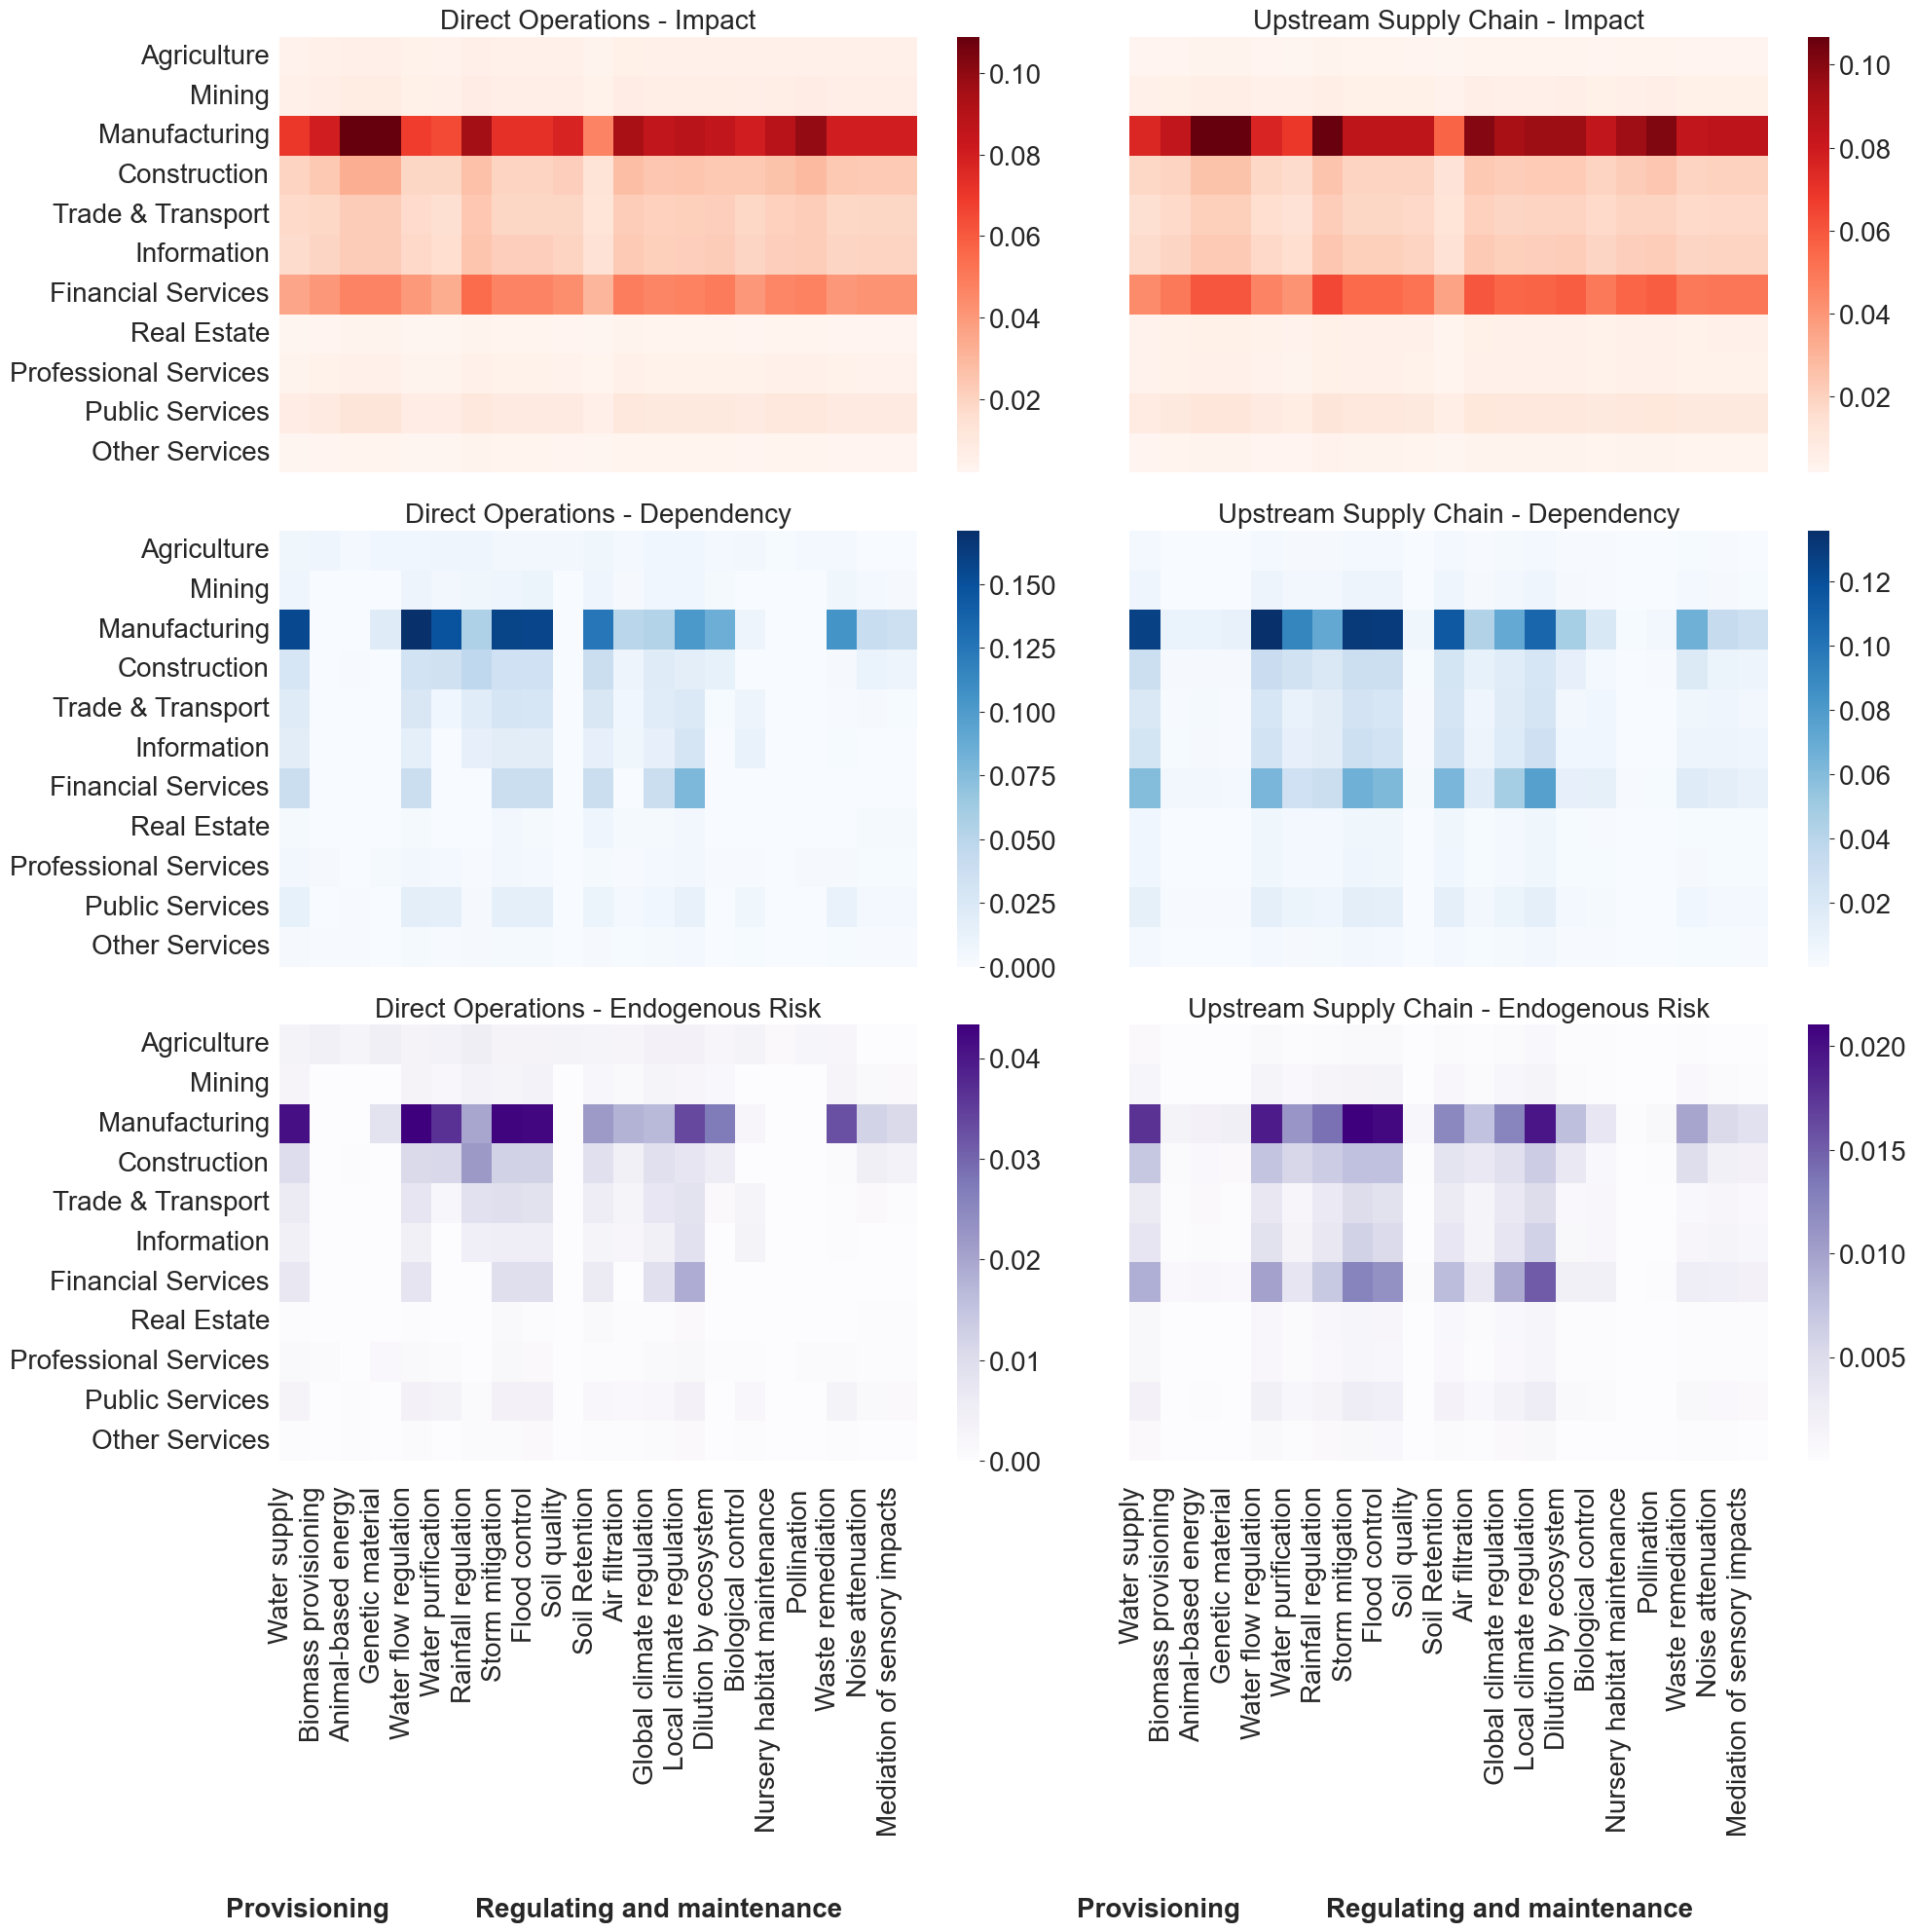

In [68]:
# plot a heatmap for each score
# create plot
plt.figure(figsize=(20, 20))
# create color scheme
# create the color palette for plots
imp_colors = sns.color_palette("Reds", as_cmap=True)
dep_colors = sns.color_palette("Blues", as_cmap=True)
both_colors = sns.color_palette("Purples", as_cmap=True)

# scope 1
# create subplot - imp scope 1
ax = plt.subplot(3, 2, 1)
# plot the heatmap
numeric_df = scope_1_mean_prop_imp_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=imp_colors, xticklabels=False, yticklabels=True)
scope_1_mean_prop_imp_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_1_sector_heatmap_imp_data.csv')
# set title and the label size
ax.set_title(f'Direct Operations - Impact')
ax.set_ylabel('')
ax.set_xlabel('')
plt.setp(ax.get_yticklabels(),
         rotation=0,  # horizontal
         ha='right',  # align labels to the right of the tick
         rotation_mode='anchor')    # set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)
# create subplot - both scope 1
ax = plt.subplot(3, 2, 3)
# plot the heatmap
numeric_df = scope_1_mean_prop_dep_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=dep_colors, xticklabels=False, yticklabels=True)
scope_1_mean_prop_dep_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_1_sector_heatmap_dep_data.csv')
# set title and the label size
ax.set_title(f'Direct Operations - Dependency')
ax.set_ylabel('')
ax.set_xlabel('')
# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# create subplot - both scope 1
ax = plt.subplot(3, 2, 5)
# plot the heatmap
numeric_df = scope_1_mean_prop_both_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=both_colors, xticklabels=False, yticklabels=True)
scope_1_mean_prop_both_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_1_sector_heatmap_both_data.csv')
# set title and the label size
ax.set_title(f'Direct Operations - Endogenous Risk')
ax.set_ylabel('')
ax.set_xlabel('')
# --- Subgroup labels (bottom row labels) ---
ax.set_xticks(np.arange(len(numeric_df.columns)) + 0.5)
ax.set_xticklabels(
    numeric_df.columns.get_level_values(0),
    rotation=90,
    ha="right"
)

# Move subgroup labels slightly down
ax.tick_params(axis='x', pad=15)

# --- Category labels (second row further down) ---
groups = numeric_df.columns.get_level_values(1)
n_cols = len(numeric_df.columns)

for cat in groups.unique():
    idx = np.where(groups == cat)[0]
    center = idx.mean()
    x_axes = (center + 0.5) / n_cols  # normalized axes position

    # Nudge "Provisioning" label to the left
    if cat == "Provisioning":
        x_axes -= 0.05  # increase this value to move further left

    ax.text(
        x_axes,
        -1,
        cat,
        ha='center',
        va='top',
        fontsize=20,
        fontweight='bold',
        transform=ax.transAxes
    )


# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# create subplot - imp scope 3
ax = plt.subplot(3, 2, 2)
# plot the heatmap
numeric_df = scope_3_source_prop_imp_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=imp_colors, xticklabels=False, yticklabels=False)
scope_3_source_prop_imp_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_3_sector_heatmap_imp_data.csv')
# set title and the label size
ax.set_title(f'Upstream Supply Chain - Impact')
ax.set_ylabel('')
ax.set_xlabel('')
plt.setp(ax.get_yticklabels(),
         rotation=0,  # horizontal
         ha='right',  # align labels to the right of the tick
         rotation_mode='anchor')    # set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# create subplot - dep scope 3
ax = plt.subplot(3, 2, 4)
# plot the heatmap
numeric_df = scope_3_source_prop_dep_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=dep_colors, xticklabels=False, yticklabels=False)
scope_3_source_prop_dep_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_3_sector_heatmap_dep_data.csv')
# set title and the label size
ax.set_title(f'Upstream Supply Chain - Dependency')
ax.set_ylabel('')
ax.set_xlabel('')
# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)


# create subplot - both scope 3
ax = plt.subplot(3, 2, 6)
# plot the heatmap
numeric_df = scope_3_source_prop_both_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=both_colors, xticklabels=False, yticklabels=False)
scope_3_source_prop_both_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_3_sector_heatmap_both_data.csv')
# set title and the label size
ax.set_title(f'Upstream Supply Chain - Endogenous Risk')
ax.set_ylabel('')
ax.set_xlabel('')
# --- Subgroup labels (bottom row labels) ---
ax.set_xticks(np.arange(len(numeric_df.columns)) + 0.5)
ax.set_xticklabels(
    numeric_df.columns.get_level_values(0),
    rotation=90,
    ha="right"
)

# Move subgroup labels slightly down
ax.tick_params(axis='x', pad=15)

# --- Category labels (second row further down) ---
groups = numeric_df.columns.get_level_values(1)
n_cols = len(numeric_df.columns)

for cat in groups.unique():
    idx = np.where(groups == cat)[0]
    center = idx.mean()
    x_axes = (center + 0.5) / n_cols  # normalized axes position
    # Nudge "Provisioning" label to the left
    if cat == "Provisioning":
        x_axes -= 0.05  # increase this value to move further left

    ax.text(
        x_axes,
        -1,
        cat,
        ha='center',
        va='top',
        fontsize=20,
        fontweight='bold',
        transform=ax.transAxes
    )

# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)



# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# adjust the layout to fit figures
plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)
# save figure
plt.savefig(f'{value_at_risk_figure_saving_path}/Impact Dependency Endogenous Risk Sector Heatmap Flipped')
plt.show()
plt.close()

In [25]:
# system level
# both
scope_1_both_sector_system_df = pd.read_csv(scope_1_both_sector_system_path, header=[0], index_col=[0, 1])
scope_3_both_sector_system_df = pd.read_csv(scope_3_both_sector_system_path, header=[0], index_col=[0, 1])

scope_1_mean_prop_both_system_df = clean_up_dataframe(scope_1_both_sector_system_df)
scope_3_source_prop_both_system_df = clean_up_dataframe(scope_3_both_sector_system_df)


,,Agriculture,Mining and Industrial Activities,Manufacuring,Construction,"Trade, Transportation and Hospitality",Information and communication,Finance and insurance,Real Estate,Professional and Support Services,"Public Services (Admin, Education & Health)",Other Services
Ecosystem Services,Ecosystem Services Type,,,,,,,,,,,
Water supply,Provisioning,0.001601,0.002334,0.036250,0.015429,0.004795,0.004460,0.010225,0.000867,0.001090,0.002564,0.000566
Biomass provisioning,Provisioning,0.001994,0.000168,0.000000,0.000000,0.000018,0.000000,0.000000,0.000000,0.000569,0.000000,0.000240
Animal-based energy,Provisioning,0.001408,0.000006,0.000000,0.000881,0.000064,0.000000,0.000000,0.000000,0.000111,0.000271,0.000456
Genetic material,Provisioning,0.002275,0.000218,0.007974,0.000000,0.000000,0.000000,0.000000,0.000000,0.001068,0.000025,0.000000
Soil and sediment quality regulation,Regulating and maintenance,0.001552,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000016,0.000000,0.000081
Rainfall pattern regulation,Regulating and maintenance,0.002420,0.003323,0.017578,0.035269,0.005804,0.005026,0.000000,0.000000,0.000306,0.000595,0.000929
Soil and sediment retention,Regulating and maintenance,0.001273,0.001822,0.021707,0.015285,0.004352,0.002655,0.007952,0.001982,0.000537,0.001490,0.000442
Pollination,Regulating and maintenance,0.001301,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000663,0.000000,0.000046
Solid waste remediation,Regulating and maintenance,0.001067,0.002299,0.028384,0.001327,0.000290,0.000508,0.000000,0.000000,0.000575,0.002611,0.000495


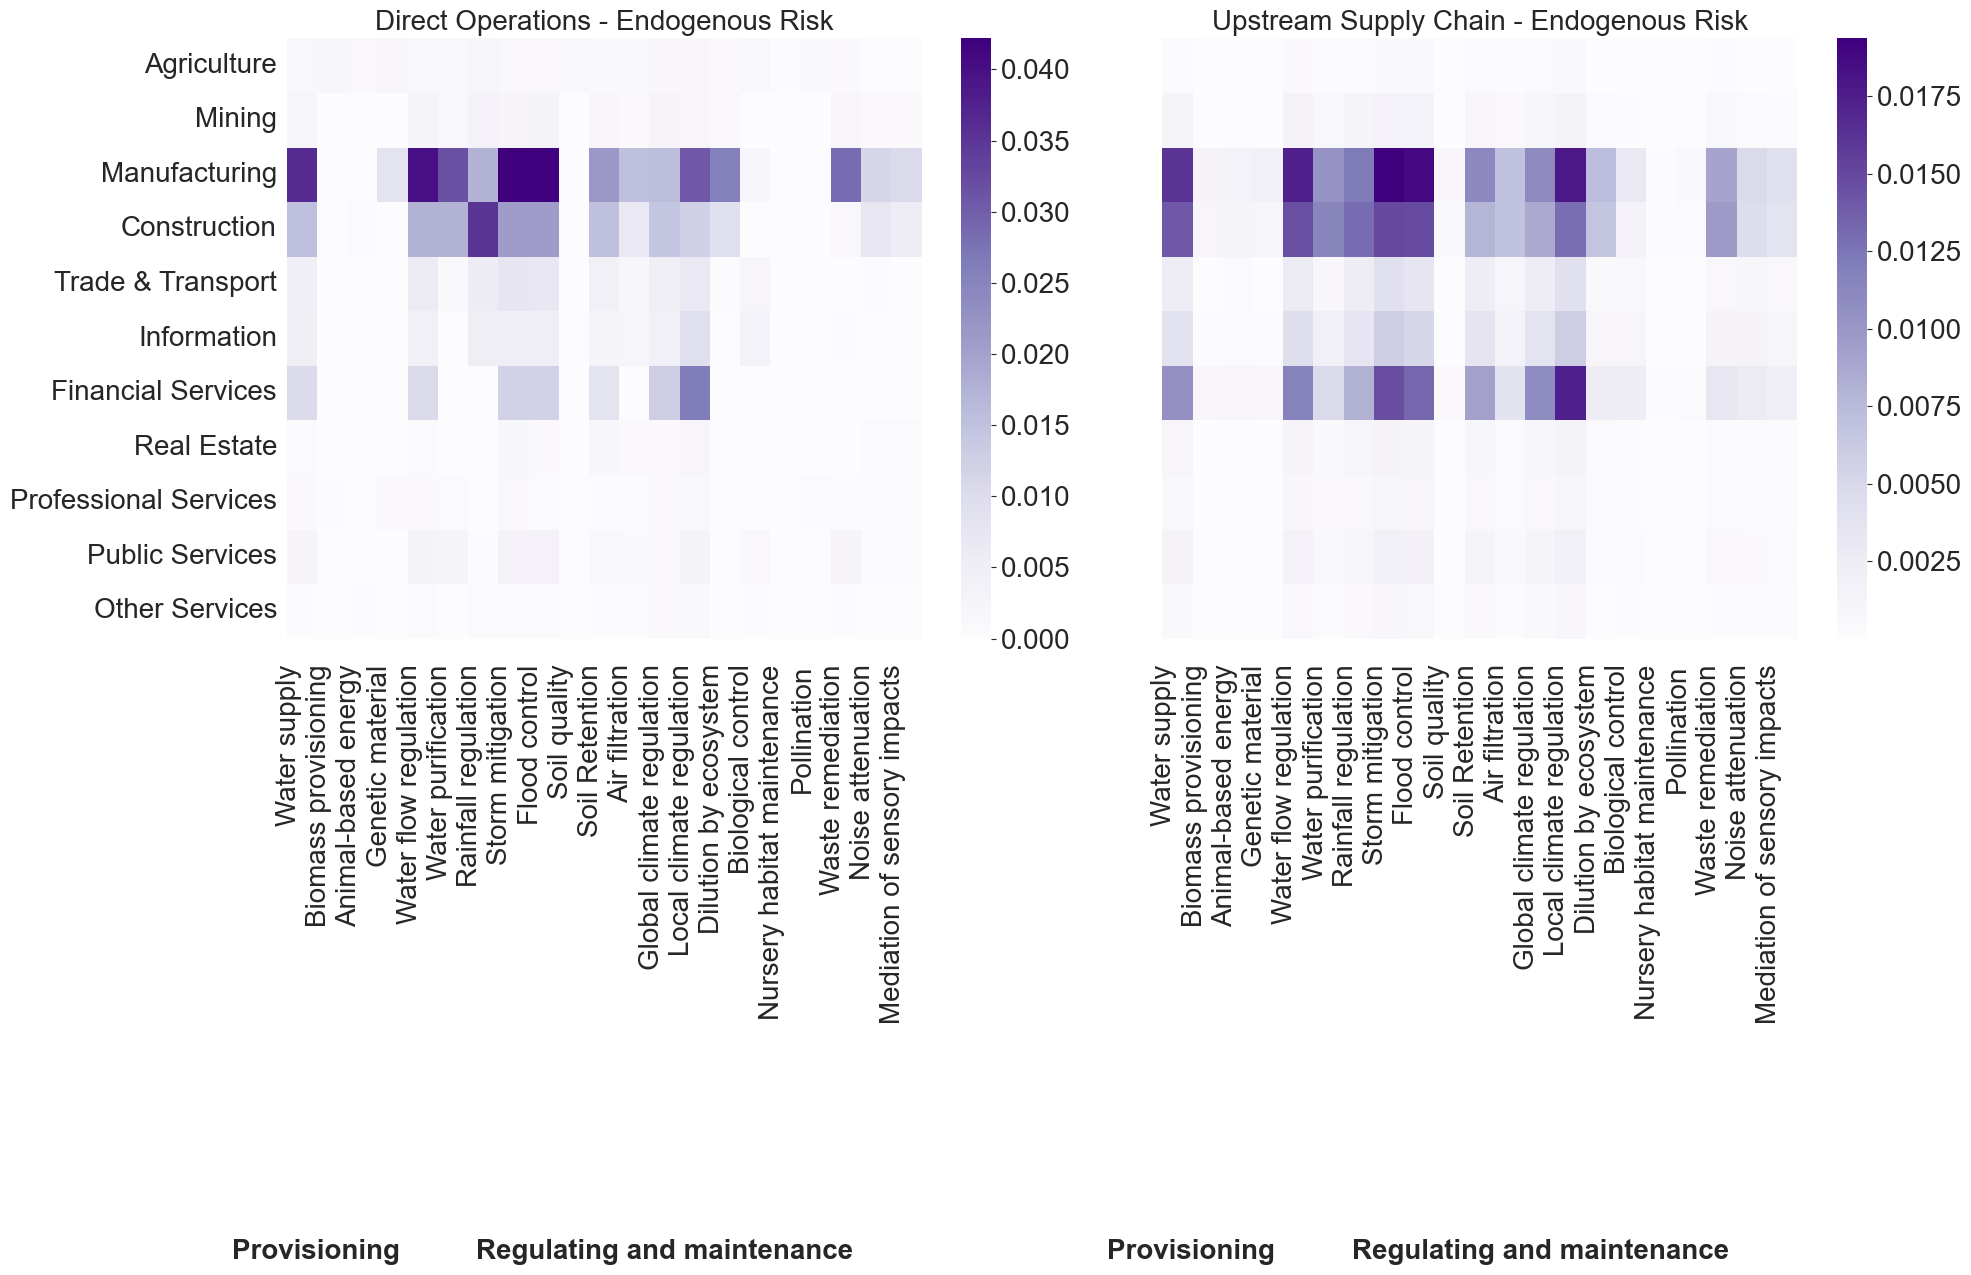

In [86]:
# plot a heatmap for each score
# create plot
plt.figure(figsize=(20, 20))
# create color scheme
# create the color palette for plots
both_colors = sns.color_palette("Purples", as_cmap=True)

# scope 1
# create subplot - imp scope 1
ax = plt.subplot(2, 2, 3)
# plot the heatmap
numeric_df = scope_1_mean_prop_both_system_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=both_colors, xticklabels=False, yticklabels=True)
scope_1_mean_prop_both_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_1_sector_heatmap_both_data_system.csv')
# set title and the label size
ax.set_title(f'Direct Operations - Endogenous Risk')
ax.set_ylabel('')
ax.set_xlabel('')
# --- Subgroup labels (bottom row labels) ---
ax.set_xticks(np.arange(len(numeric_df.columns)) + 0.5)
ax.set_xticklabels(
    numeric_df.columns.get_level_values(0),
    rotation=90,
    ha="right"
)

# Move subgroup labels slightly down
ax.tick_params(axis='x', pad=15)

# --- Category labels (second row further down) ---
groups = numeric_df.columns.get_level_values(1)
n_cols = len(numeric_df.columns)

for cat in groups.unique():
    idx = np.where(groups == cat)[0]
    center = idx.mean()
    x_axes = (center + 0.5) / n_cols  # normalized axes position

    # Nudge "Provisioning" label to the left
    if cat == "Provisioning":
        x_axes -= 0.05  # increase this value to move further left

    ax.text(
        x_axes,
        -1,
        cat,
        ha='center',
        va='top',
        fontsize=20,
        fontweight='bold',
        transform=ax.transAxes
    )


# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# create subplot - both scope 3
ax = plt.subplot(2, 2, 4)
# plot the heatmap
numeric_df = scope_3_source_prop_both_system_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=both_colors, xticklabels=False, yticklabels=False)
scope_3_source_prop_both_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_3_sector_heatmap_both_data_system.csv')
# set title and the label size
ax.set_title(f'Upstream Supply Chain - Endogenous Risk')
ax.set_ylabel('')
ax.set_xlabel('')
# --- Subgroup labels (bottom row labels) ---
ax.set_xticks(np.arange(len(numeric_df.columns)) + 0.5)
ax.set_xticklabels(
    numeric_df.columns.get_level_values(0),
    rotation=90,
    ha="right"
)

# Move subgroup labels slightly down
ax.tick_params(axis='x', pad=15)

# --- Category labels (second row further down) ---
groups = numeric_df.columns.get_level_values(1)
n_cols = len(numeric_df.columns)

for cat in groups.unique():
    idx = np.where(groups == cat)[0]
    center = idx.mean()
    x_axes = (center + 0.5) / n_cols  # normalized axes position
    # Nudge "Provisioning" label to the left
    if cat == "Provisioning":
        x_axes -= 0.05  # increase this value to move further left

    ax.text(
        x_axes,
        -1,
        cat,
        ha='center',
        va='top',
        fontsize=20,
        fontweight='bold',
        transform=ax.transAxes
    )

# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)



# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# adjust the layout to fit figures
plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)
# save figure
plt.savefig(f'{value_at_risk_figure_saving_path}/System Endogenous Risk Sector Heatmap Flipped')
plt.show()
plt.close()



In [357]:
# create a figure of sector x sector impact and dependency for GB Flood and US Rainfall pattern regulation 
def generate_sector_matrix_imp_dep(region, ESS):
    dep_mean_df = pd.read_csv('C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/Dependencies/EXIOBASE_sectors_scope_1_dependency_scores_mean.csv', index_col=[0], header=[0, 1]).T
    imp_mean_df = pd.read_csv('C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/Impacts/EXIOBASE_sectors_scope_1_impact_scores_mean.csv', index_col=[0], header=[0, 1]).T
    
    dep_mean_df = dep_mean_df.rename_axis(index={"sector": "dep_sector"})
    imp_mean_df = imp_mean_df.rename_axis(index={"sector": "imp_sector"})
    
    dep_mean_region_series = dep_mean_df.loc[region][ESS]
    imp_mean_region_series = imp_mean_df.loc[region][ESS]
    
    
    imp_dep_matrix = pd.DataFrame(
        np.outer(imp_mean_region_series, dep_mean_region_series),
        index=imp_mean_region_series.index,
        columns=dep_mean_region_series.index
    )
    
    return imp_dep_matrix

In [38]:
from banks_at_risk.Setup.NACE_conversion_paths import NACE_converter_path, NACE_letters_path
from banks_at_risk.Setup.ENCORE_paths import ESS_types_path



def aggregate_to_SNA(score_df):
    # get the NACE sector aggregation
    NACE_sector_agg_df = pd.read_csv(NACE_letters_path, header=[0], index_col=[0]).drop(columns=['Description'])
    order = NACE_sector_agg_df.reset_index()['Aggregation'].drop_duplicates()
    NACE_sector_agg_df['Aggregation'] = pd.Categorical(NACE_sector_agg_df['Aggregation'], categories=order,
                                                       ordered=True)

    df = score_df.copy()

    # aggregate sectors
    if 'region' not in df.T.reset_index().columns:
        score_agg_df = pd.merge(df.reset_index(), NACE_sector_agg_df.reset_index(), left_on=['Code'],
                             right_on=['Code'], how='left').drop(columns=['Code']).groupby(['Aggregation']).mean()

    elif 'region' in df.T.reset_index().columns:
        df = df.T
        score_agg_df = pd.merge(df.reset_index(), NACE_sector_agg_df.reset_index(), left_on=['Code'],
                             right_on=['Code'], how='left').drop(columns=['Code']).groupby(['Aggregation', 'region']).mean()

        # score_agg_df.name = score_df.name

    return score_agg_df

def aggregate_ESS_types(score_df):
    # get the ESS type
    ESS_types_df = pd.read_csv(ESS_types_path, header=[0], index_col=[0])

    df = score_df.copy()
    if 'region' not in df.T.reset_index().columns:
        merged_long_df = pd.melt(df.reset_index(), id_vars='Aggregation', value_vars=df.columns.tolist(),
                                 var_name='Ecosystem Services', value_name='score')
        # aggregate ecosystem services
        merged_ess_df = pd.merge(merged_long_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                 right_on=['Ecosystem Services'], how='left').drop(
            columns='Ecosystem Services').groupby(['Ecosystem Services Type', 'Aggregation']).mean()
        score_agg_df = merged_ess_df.reset_index().pivot(index='Aggregation', columns='Ecosystem Services Type',
                                                         values='score')
    elif 'region' in df.T.reset_index().columns:
        merged_long_df = pd.melt(df.reset_index(), id_vars=['Aggregation', 'region'],
                                 value_vars=df.columns.tolist(),
                                 var_name='Ecosystem Services', value_name='score')
        # aggregate ecosystem services
        merged_ess_df = pd.merge(merged_long_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                 right_on=['Ecosystem Services'], how='left').drop(
            columns='Ecosystem Services').groupby(['Ecosystem Services Type', 'Aggregation', 'region']).mean()
        score_agg_df = merged_ess_df.reset_index().pivot(index=['Aggregation', 'region'],
                                                     columns='Ecosystem Services Type',
                                                     values='score')

    return score_agg_df

def order_ESS_types(score_df):
    # get the ESS type
    ESS_types_df = pd.read_csv(ESS_types_path, header=[0], index_col=[0])
    ESS_order = ['Provisioning', 'Regulating and maintenance']
    df = score_df.copy()
    if 'Bank' not in df.columns:
        if 'region' not in df.T.reset_index().columns:
            merged_long_df = pd.melt(df.reset_index(), id_vars='Aggregation', value_vars=df.columns.tolist(),
                                     var_name='Ecosystem Services', value_name='score')
            # order ecosystem services
            merged_ess_df = pd.merge(merged_long_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                     right_on=['Ecosystem Services'], how='left')
            merged_ess_no_culture_df = merged_ess_df[merged_ess_df['Ecosystem Services Type'] != 'Cultural']
            merged_ess_no_culture_df['Ecosystem Services Type'] = pd.Categorical(
                merged_ess_no_culture_df['Ecosystem Services Type'],
                categories=ESS_order,
                ordered=True
            )
            merged_ess_no_culture_df = merged_ess_no_culture_df.sort_values('Ecosystem Services Type')
            # merged_ess_no_culture_df = merged_ess_no_culture_df.drop(columns='Ecosystem Services Type')
            score_agg_df = merged_ess_no_culture_df.pivot(index=['Aggregation'], columns=['Ecosystem Services', 'Ecosystem Services Type'], values='score')
        elif 'region' in df.T.reset_index().columns:
            merged_long_df = pd.melt(df.reset_index(), id_vars=['Aggregation', 'region'],
                                     value_vars=df.columns.tolist(),
                                     var_name='Ecosystem Services', value_name='score')
            # aggregate ecosystem services
            merged_ess_df = pd.merge(merged_long_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                     right_on=['Ecosystem Services'], how='left')

            # order ecosystem services
            merged_ess_df = pd.merge(merged_ess_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                     right_on=['Ecosystem Services'], how='left')
            merged_ess_no_culture_df = merged_ess_df[merged_ess_df['Ecosystem Services Type'] != 'Cultural']
            merged_ess_no_culture_df['Ecosystem Services Type'] = pd.Categorical(
                merged_ess_no_culture_df['Ecosystem Services Type'],
                categories=ESS_order,
                ordered=True
            )
            merged_ess_no_culture_df = merged_ess_no_culture_df.sort_values('Ecosystem Services Type')
            # merged_ess_no_culture_df = merged_ess_no_culture_df.drop(columns='Ecosystem Services Type')
            score_agg_df = merged_ess_no_culture_df.pivot(index=['Aggregation', 'region'],
                                                                        columns=['Ecosystem Services', 'Ecosystem Services Type'],
                                                                        values='score')
    elif 'Bank' in df.columns:
        if 'region' not in df.T.reset_index().columns:
            merged_long_df = pd.melt(df.reset_index(), id_vars=['Aggregation', 'Bank'], value_vars=df.columns.tolist(),
                                     var_name='Ecosystem Services', value_name='score')
            # order ecosystem services
            merged_ess_df = pd.merge(merged_long_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                     right_on=['Ecosystem Services'], how='left')
            merged_ess_no_culture_df = merged_ess_df[merged_ess_df['Ecosystem Services Type'] != 'Cultural']
            merged_ess_no_culture_df['Ecosystem Services Type'] = pd.Categorical(
                merged_ess_no_culture_df['Ecosystem Services Type'],
                categories=ESS_order,
                ordered=True
            )
            merged_ess_no_culture_df = merged_ess_no_culture_df.sort_values('Ecosystem Services Type')
            # merged_ess_no_culture_df = merged_ess_no_culture_df.drop(columns='Ecosystem Services Type')
            score_agg_df = merged_ess_no_culture_df.pivot(index=['Aggregation', 'Bank'],
                                                          columns=['Ecosystem Services', 'Ecosystem Services Type'],
                                                          values='score')
            score_agg_df = score_agg_df.reset_index().drop(columns='Bank').groupby(['Aggregation']).mean()
        elif 'region' in df.T.reset_index().columns:
            merged_long_df = pd.melt(df.reset_index(), id_vars=['Aggregation', 'region', 'Bank'],
                                     value_vars=df.columns.tolist(),
                                     var_name='Ecosystem Services', value_name='score')
            # aggregate ecosystem services
            merged_ess_df = pd.merge(merged_long_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                     right_on=['Ecosystem Services'], how='left')

            # order ecosystem services
            merged_ess_df = pd.merge(merged_ess_df, ESS_types_df.reset_index(), left_on=['Ecosystem Services'],
                                     right_on=['Ecosystem Services'], how='left')
            merged_ess_no_culture_df = merged_ess_df[merged_ess_df['Ecosystem Services Type'] != 'Cultural']
            merged_ess_no_culture_df['Ecosystem Services Type'] = pd.Categorical(
                merged_ess_no_culture_df['Ecosystem Services Type'],
                categories=ESS_order,
                ordered=True
            )
            merged_ess_no_culture_df = merged_ess_no_culture_df.sort_values('Ecosystem Services Type')
            # merged_ess_no_culture_df = merged_ess_no_culture_df.drop(columns='Ecosystem Services Type')
            score_agg_df = merged_ess_no_culture_df.pivot(index=['Aggregation', 'region', 'Bank'],
                                                          columns=['Ecosystem Services', 'Ecosystem Services Type'],
                                                          values='score')
            score_agg_df = score_agg_df.reset_index().drop(columns='Bank').groupby(['Aggregation', 'region']).mean()

    score_agg_df.columns = score_agg_df.columns.map(lambda col: tuple((c.split(" - ")[-1] if isinstance(c, str) else c) for c in col))

    return score_agg_df

In [104]:
# get the ESS
# both
scope_1_mean_prop_sector_df = pd.read_csv("C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/Sectoral Overlap/scope1_overlap_mean.csv", header=[0,1], index_col=[0]).reset_index().rename(columns={'index':'Ecosystem Services'}).set_index(['Ecosystem Services']).T

scope_3_mean_prop_sector_df = pd.read_csv("C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Data/Value at Risk Figures/Sectoral Overlap/scope3_overlap_mean.csv", header=[0], index_col=[0, 1]).T.reset_index().rename(columns={'index':'Ecosystem Services'}).set_index(['Ecosystem Services']).T

services = np.unique(scope_1_mean_prop_sector_df.columns).tolist()

# sector
# NACE_converter = generate_converter_sector()
NACE_converter = pd.read_csv(NACE_converter_path, header=[0], index_col=[0])

# merge the NACE converter and the score and group the sectors by their higher-level classification for
# display purposes
# scope 1 both
scope_1_NACE_mean_both_df = pd.merge(scope_1_mean_prop_sector_df.reset_index().drop(columns=['region']).set_index(['sector']), NACE_converter, right_index=True, left_index=True).groupby(['Code']).mean()


# scope 3 - source
# both
scope_3_NACE_mean_both_df = pd.merge(scope_3_mean_prop_sector_df.reset_index().drop(columns=['region']).set_index(['sector']), NACE_converter, right_index=True, left_index=True).groupby(
    ['Code']).mean()
# scope_3_NACE_mean_both_df = scope_3_NACE_mean_both_df.rename(columns={'Code': 'Sector'})

    #both
scope_1_NACE_mean_both_df = aggregate_to_SNA(scope_1_NACE_mean_both_df)
scope_3_NACE_mean_both_df = aggregate_to_SNA(scope_3_NACE_mean_both_df)



C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\3082502470.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_agg_df = pd.merge(df.reset_index(), NACE_sector_agg_df.reset_index(), left_on=['Code'],
C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\3082502470.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_agg_df = pd.merge(df.reset_index(), NACE_sector_agg_df.reset_index(), left_on=['Code'],


In [85]:
scope_3_NACE_mean_both_df

Aggregation,Agriculture,Mining and Industrial Activities,Manufacuring,Construction,"Trade, Transportation and Hospitality",Information and communication,Finance and insurance,Real Estate,Professional and Support Services,"Public Services (Admin, Education & Health)",Other Services
Air filtration,0.076566,0.051787,0.089345,0.071140,0.070937,0.044814,0.032112,0.048407,0.051134,0.062871,0.057670
Biological control,0.060352,0.021639,0.049482,0.020631,0.045403,0.029492,0.020802,0.019443,0.028555,0.034328,0.032567
Biomass provisioning,0.057887,0.011499,0.042882,0.010584,0.025234,0.009490,0.008052,0.008754,0.013165,0.017162,0.016927
"Education, scientific and research services",0.040236,0.012272,0.035516,0.013288,0.028944,0.022419,0.016166,0.013175,0.027025,0.027862,0.025012
Flood control,0.152693,0.114245,0.175495,0.164539,0.151641,0.115838,0.094499,0.123477,0.128316,0.142363,0.130525
Genetic material,0.063676,0.011414,0.045890,0.009966,0.030554,0.010645,0.008849,0.008576,0.016043,0.020718,0.017781
Global climate regulation,0.124242,0.083195,0.131658,0.107272,0.117017,0.086525,0.077320,0.090853,0.094588,0.104665,0.099449
Local (micro and meso) climate regulation,0.146077,0.097287,0.158942,0.140115,0.144490,0.123744,0.114269,0.123819,0.129063,0.135645,0.130087
Noise attenuation,0.030479,0.032277,0.042928,0.050035,0.036780,0.029323,0.021875,0.035383,0.035217,0.040800,0.036813
Nursery population and habitat maintenance,0.012803,0.001878,0.009345,0.002099,0.005850,0.001741,0.001561,0.001659,0.002335,0.003434,0.003595


In [105]:
scope_1_NACE_mean_both_df.columns = [col.split(" - ")[-1] for col in scope_1_NACE_mean_both_df.columns]
scope_3_NACE_mean_both_df.columns = [col.split(" - ")[-1] for col in scope_3_NACE_mean_both_df.columns]



In [106]:
scope_1_NACE_mean_both_df = scope_1_NACE_mean_both_df.T
scope_3_NACE_mean_both_df = scope_3_NACE_mean_both_df.T
service_to_type = dict(zip(
    scope_1_both_sector_df.index.get_level_values("Ecosystem Services"),
    scope_1_both_sector_df.index.get_level_values("Ecosystem Services Type"),
))
scope_1_NACE_mean_both_df.index = pd.MultiIndex.from_arrays(
    [scope_1_NACE_mean_both_df.index, scope_1_NACE_mean_both_df.index.map(service_to_type)],
    names=["Ecosystem Services", "Ecosystem Services Type"],
)
scope_3_NACE_mean_both_df.index = pd.MultiIndex.from_arrays(
    [scope_3_NACE_mean_both_df.index, scope_3_NACE_mean_both_df.index.map(service_to_type)],
    names=["Ecosystem Services", "Ecosystem Services Type"],
)

In [107]:
scope_1_NACE_mean_both_df=scope_1_NACE_mean_both_df.reset_index().dropna().set_index(['Ecosystem Services', 'Ecosystem Services Type'])
scope_3_NACE_mean_both_df=scope_3_NACE_mean_both_df.reset_index().dropna().set_index(['Ecosystem Services', 'Ecosystem Services Type'])


In [108]:
# sector level - no finance

scope_1_mean_prop_sector_df = clean_up_dataframe(scope_1_NACE_mean_both_df)
scope_3_mean_prop_sector_df = clean_up_dataframe(scope_3_NACE_mean_both_df)

C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\2933329204.py:153: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):
C:\Users\emmao\AppData\Local\Temp\ipykernel_29808\2933329204.py:153: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):


In [109]:
scope_1_mean_prop_sector_df

Ecosystem Services,Water supply,Biomass provisioning,Animal-based energy,Genetic material,Water flow regulation,Water purification,Rainfall regulation,Storm mitigation,Flood control,Soil quality,...,Air filtration,Global climate regulation,Local climate regulation,Dilution by ecosystem,Biological control,Nursery habitat maintenance,Pollination,Waste remediation,Noise attenuation,Mediation of sensory impacts
Ecosystem Services Type,Provisioning,Provisioning,Provisioning,Provisioning,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,...,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance,Regulating and maintenance
Aggregation,,,,,,,,,,,,,,,,,,,,,
Agriculture,0.387376,0.473820,0.264732,0.493474,0.359069,0.415714,0.591334,0.330644,0.335851,0.346907,...,0.288224,0.425771,0.422796,0.247843,0.355162,0.124211,0.190737,0.250540,0.034400,0.034400
Mining,0.235929,0.029291,0.005502,0.003675,0.252964,0.190053,0.309536,0.224484,0.253395,0.000000,...,0.126612,0.192705,0.142660,0.135735,0.021289,0.000000,0.000000,0.183336,0.075172,0.078494
Manufacturing,0.193631,0.000000,0.000000,0.008395,0.190830,0.161609,0.124519,0.176920,0.176776,0.000000,...,0.107907,0.070476,0.130705,0.104567,0.021194,0.000000,0.000000,0.158834,0.038908,0.033427
Construction,0.174242,0.000000,0.010502,0.000000,0.188894,0.197818,0.385183,0.215537,0.215537,0.000000,...,0.075139,0.161752,0.137115,0.099508,0.000000,0.000000,0.000000,0.015158,0.081833,0.063235
Trade & Transport,0.120903,0.002706,0.012420,0.000000,0.141063,0.107081,0.171431,0.166007,0.152704,0.000000,...,0.087137,0.153763,0.154724,0.021548,0.064271,0.000000,0.000000,0.024937,0.048714,0.038985
Information,0.057813,0.000000,0.000000,0.000000,0.056794,0.000000,0.069821,0.076103,0.076103,0.000000,...,0.032315,0.059729,0.121870,0.000000,0.046505,0.000000,0.000000,0.006644,0.000000,0.000000
Financial Services,0.035238,0.000000,0.000000,0.000000,0.039304,0.000000,0.000000,0.046611,0.046611,0.000000,...,0.000000,0.045995,0.093813,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Real Estate,0.030000,0.000000,0.000000,0.000000,0.033118,0.000000,0.000000,0.084706,0.042353,0.000000,...,0.045926,0.040310,0.081951,0.000000,0.000000,0.000000,0.000000,0.000000,0.037724,0.037724


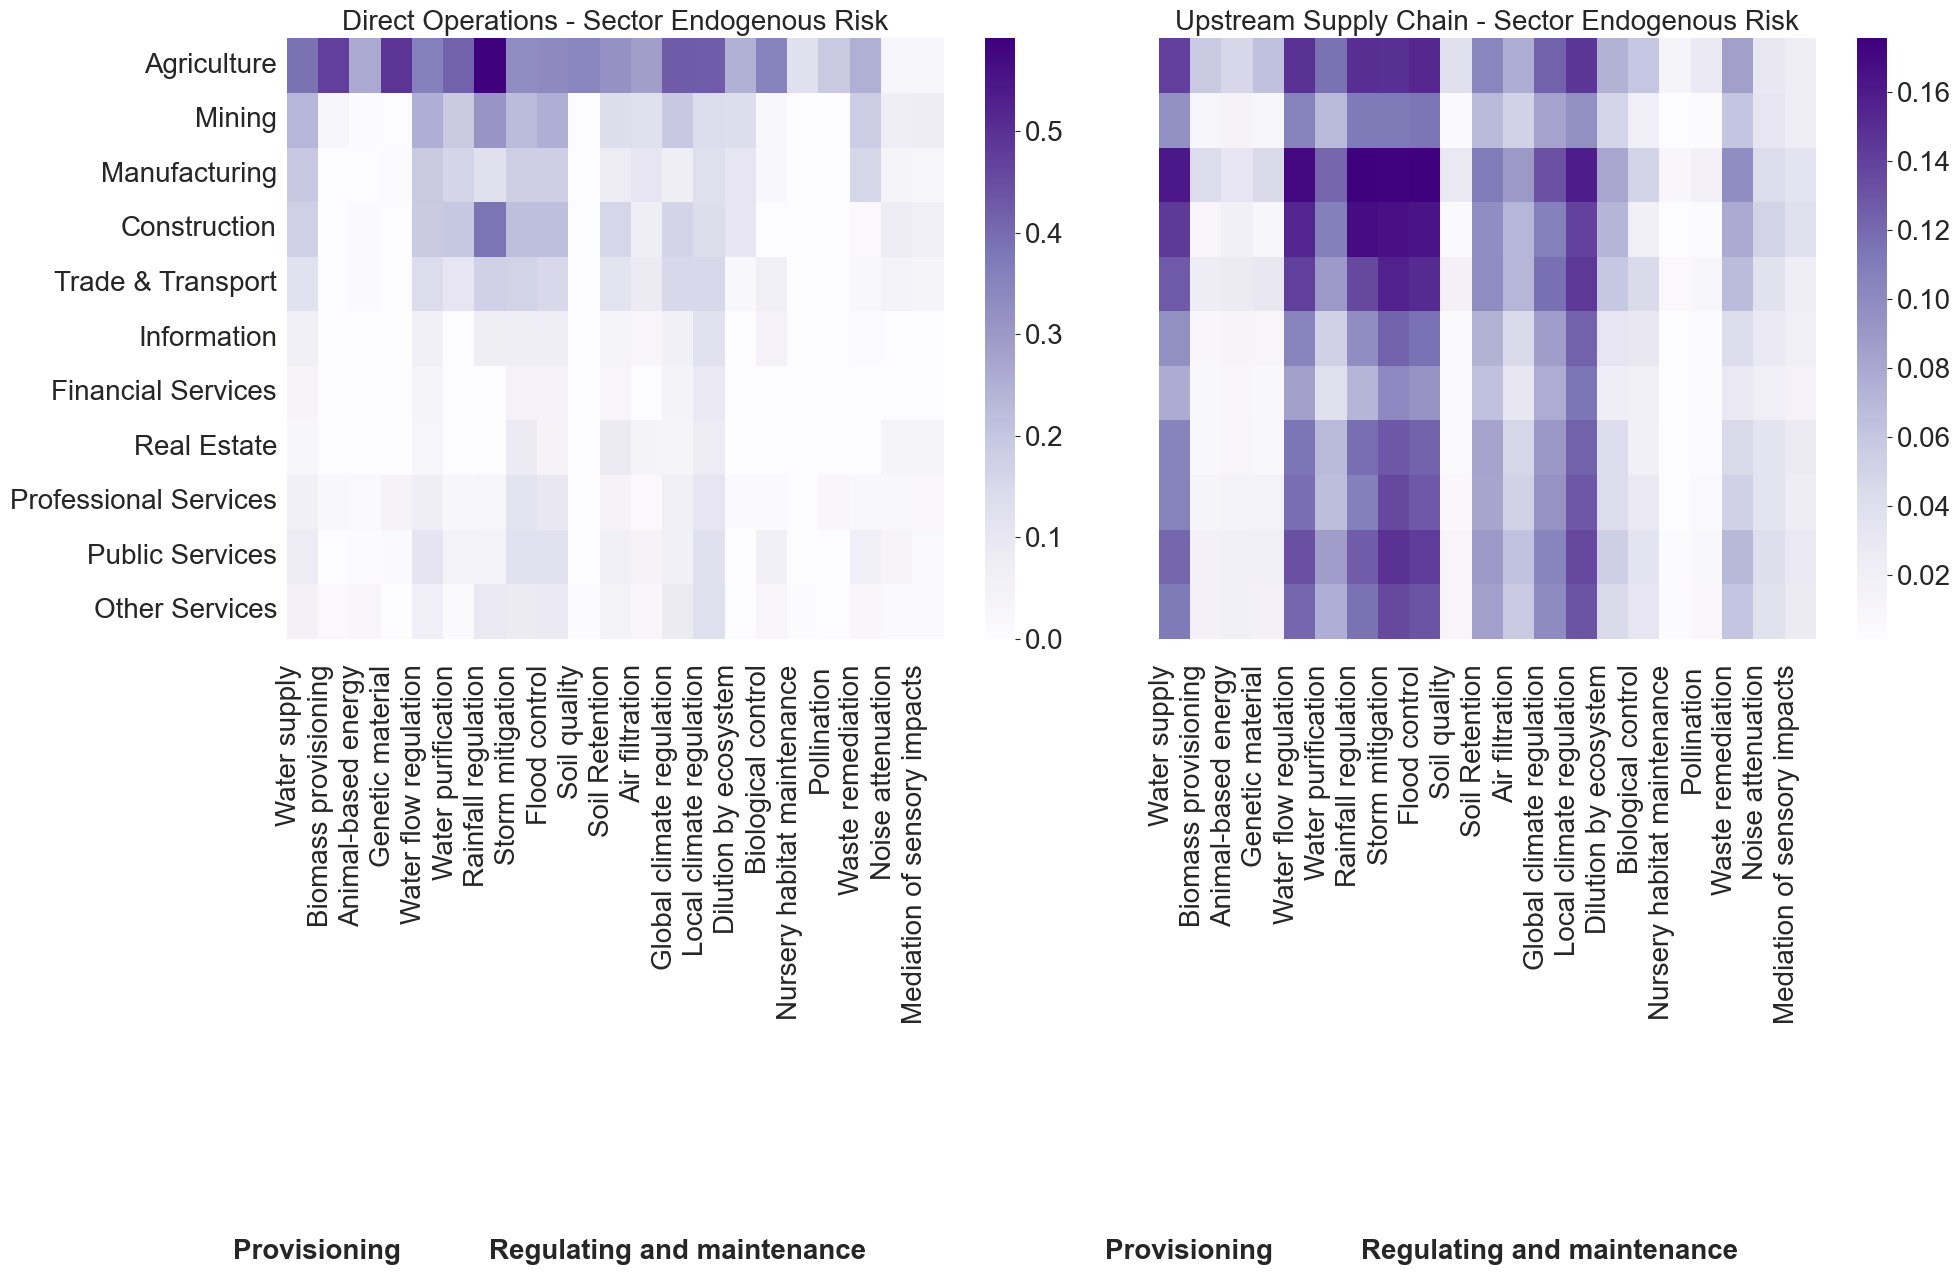

In [113]:
# plot a heatmap for each score
# create plot
plt.figure(figsize=(20, 20))
# create color scheme
# create the color palette for plots
both_colors = sns.color_palette("Purples", as_cmap=True)

# scope 1
# create subplot - imp scope 1
ax = plt.subplot(2, 2, 3)
# plot the heatmap
numeric_df = scope_1_mean_prop_sector_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=both_colors, xticklabels=False, yticklabels=True)
# scope_1_NACE_mean_both_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_1_sector_heatmap_both_data_no_finance.csv')
# set title and the label size
ax.set_title(f'Direct Operations - Sector Endogenous Risk')
ax.set_ylabel('')
ax.set_xlabel('')
# --- Subgroup labels (bottom row labels) ---
ax.set_xticks(np.arange(len(numeric_df.columns)) + 0.5)
ax.set_xticklabels(
    numeric_df.columns.get_level_values(0),
    rotation=90,
    ha="right"
)

# Move subgroup labels slightly down
ax.tick_params(axis='x', pad=15)

# --- Category labels (second row further down) ---
groups = numeric_df.columns.get_level_values(1)
n_cols = len(numeric_df.columns)

for cat in groups.unique():
    idx = np.where(groups == cat)[0]
    center = idx.mean()
    x_axes = (center + 0.5) / n_cols  # normalized axes position

    # Nudge "Provisioning" label to the left
    if cat == "Provisioning":
        x_axes -= 0.05  # increase this value to move further left

    ax.text(
        x_axes,
        -1,
        cat,
        ha='center',
        va='top',
        fontsize=20,
        fontweight='bold',
        transform=ax.transAxes
    )


# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)

# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# create subplot - both scope 3
ax = plt.subplot(2, 2, 4)
# plot the heatmap
numeric_df = scope_3_mean_prop_sector_df.apply(pd.to_numeric, errors='coerce')
sns.heatmap(numeric_df, ax=ax, cmap=both_colors, xticklabels=False, yticklabels=False)
# scope_3_NACE_mean_both_df.T.to_csv(f'{value_at_risk_figure_saving_path}/scope_3_sector_heatmap_both_data_no_finance.csv')
# set title and the label size
ax.set_title(f'Upstream Supply Chain - Sector Endogenous Risk')
ax.set_ylabel('')
ax.set_xlabel('')
# --- Subgroup labels (bottom row labels) ---
ax.set_xticks(np.arange(len(numeric_df.columns)) + 0.5)
ax.set_xticklabels(
    numeric_df.columns.get_level_values(0),
    rotation=90,
    ha="right"
)

# Move subgroup labels slightly down
ax.tick_params(axis='x', pad=15)

# --- Category labels (second row further down) ---
groups = numeric_df.columns.get_level_values(1)
n_cols = len(numeric_df.columns)

for cat in groups.unique():
    idx = np.where(groups == cat)[0]
    center = idx.mean()
    x_axes = (center + 0.5) / n_cols  # normalized axes position
    # Nudge "Provisioning" label to the left
    if cat == "Provisioning":
        x_axes -= 0.05  # increase this value to move further left

    ax.text(
        x_axes,
        -1,
        cat,
        ha='center',
        va='top',
        fontsize=20,
        fontweight='bold',
        transform=ax.transAxes
    )

# set label size
items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()  # Get legend text elements
for item in items:
    item.set_fontsize(20)



# Get the colorbar
cbar = ax.collections[0].colorbar
# Increase tick size
cbar.ax.tick_params(labelsize=20)

# adjust the layout to fit figures
plt.tight_layout()
# plt.subplots_adjust(bottom=0.25)
# save figure
plt.savefig(f'{value_at_risk_figure_saving_path}/Sector Endogenous Risk Sector Heatmap Flipped no Finance')
plt.show()
plt.close()

In [446]:
UK_flood_df = generate_sector_matrix_imp_dep('GB', 'Flood control')
US_rain_df = generate_sector_matrix_imp_dep('US', 'Rainfall pattern regulation')
EE_water_df = generate_sector_matrix_imp_dep('EE', 'Water supply ')




In [447]:
def aggregate_to_SNA(matrix_df, region):
    NACE_letters_path = 'C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/finance_exiobase_conversion/NACE_letter_sector.csv'
    NACE_sector_agg_df = pd.read_csv(NACE_letters_path, header=[0], index_col=[0]).drop(columns=['Description'])
    order = NACE_sector_agg_df.reset_index()['Aggregation'].drop_duplicates()
    NACE_sector_agg_df['Aggregation'] = pd.Categorical(NACE_sector_agg_df['Aggregation'], categories=order,
                                                       ordered=True)
    
    # sector
    NACE_converter_path = 'C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/finance_exiobase_conversion/NACE_converter.csv'
    NACE_converter = pd.read_csv(NACE_converter_path, header=[0], index_col=[0])
    
    SNA_converter = pd.merge(NACE_sector_agg_df.reset_index(), NACE_converter.reset_index(), left_on=['Code'], right_on=['Code'], how='right').drop(columns='Code').set_index(['sector'])
    
    df = matrix_df.copy()
    
    # merge the NACE converter and the score and group the sectors by their higher-level classification for
    SNA_score = pd.merge(df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean()
    SNA_score_final = pd.merge(SNA_score.T, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean().T
    print(np.max(SNA_score_final))

    financial_data_df = pd.read_csv('C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/financial_data/GSIB_financial_data.csv', header=[0])
            
    financial_data_average_bank_df = financial_data_df.drop(columns='Bank').groupby(['region', 'sector']).mean()
 
    financial_region_average_region_df = financial_data_average_bank_df.xs(region, level='region')
    
    finance_SNA_df = pd.merge(financial_region_average_region_df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).sum()
    
    merged_matrix_df = pd.merge(SNA_score_final, finance_SNA_df, left_index=True, right_index=True, how='left').fillna(0.0)
    merged_matrix_df.loc[:, merged_matrix_df.columns != "production"] = (
        merged_matrix_df.loc[:, merged_matrix_df.columns != "production"]
            .mul(merged_matrix_df["production"], axis=0)
    )
    
    merged_matrix_df = merged_matrix_df.drop(columns='production')

    total_region = sum(finance_SNA_df['production'])
    print(total_region)

    prop_SNA_score_df = merged_matrix_df/total_region
    
    # calculate endogenous risk 
    prop_by_region_df = finance_SNA_df['production'] / total_region
    endogenous_risk_score_df = pd.merge(merged_matrix_df, prop_by_region_df, left_index=True, right_index=True, how='left').fillna(0.0)
    endogenous_risk_score_df.loc[:, endogenous_risk_score_df.columns != "production"] = (
        endogenous_risk_score_df.loc[:, endogenous_risk_score_df.columns != "production"]
            .mul(endogenous_risk_score_df["production"], axis=1)
    )
    endogenous_risk_score_prop_df = endogenous_risk_score_df.drop(columns='production') / total_region
    
    return SNA_score_final, prop_SNA_score_df, endogenous_risk_score_prop_df

In [509]:
def generate_sector_sector_heatmap(region, ESS):

    matrix_df = generate_sector_matrix_imp_dep(region, ESS)
    score_matrix, SNA_matrix_df, SNA_endogenous_df = aggregate_to_SNA(matrix_df, region)
    
        # 10) clean up sector names
    sector_mapping = {
    "Agriculture": "Agriculture",
    "Mining and Industrial Activities": "Mining",
    "Manufacturing": "Manufacturing",
    "Construction": "Construction",
    "Trade, Transportation and Hospitality": "Trade & Transport",
    "Information and communication": "Information",
    "Finance and insurance": "Financial Services",
    "Real Estate": "Real Estate",
    "Professional and Support Services": "Professional Services",
    "Public Services (Admin, Education & Health)": "Public Services",
    "Other Services": "Other Services",
    }

    SNA_matrix_clean_df = SNA_matrix_df.rename(index=sector_mapping)
    SNA_endogenous_clean_df = SNA_endogenous_df.rename(index=sector_mapping)
    SNA_matrix_clean_df.columns = [sector_mapping.get(str(c).strip(), c) for c in SNA_matrix_clean_df.columns]
    SNA_endogenous_clean_df.columns = [sector_mapping.get(str(c).strip(), c) for c in SNA_endogenous_clean_df.columns]
    
    fig, axs = plt.subplots(nrows = 1, ncols=2, figsize = (14, 6))
    hm0 = sns.heatmap(SNA_matrix_clean_df, ax=axs[0], cmap ='Reds', linewidths=0.5, linecolor='white')
    cbar0 = hm0.collections[0].colorbar
    cbar0.ax.tick_params(labelsize=20)
    # axs[0].xaxis.tick_top()  # move x tick labels to top
    axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90, ha='left')
    axs[0].set_title(f"Bank Portfolio Risk to Economy \n {region} {ESS}")
    
    # set label size
    items = [axs[0].title, axs[0].yaxis.label, axs[0].xaxis.label] + axs[0].get_xticklabels() + axs[0].get_yticklabels()
    if axs[0].legend_:
        items += axs[0].legend_.get_texts()  # Get legend text elements
    for item in items:
        item.set_fontsize(20)
    
    hm1 = sns.heatmap(SNA_endogenous_clean_df, ax=axs[1], cmap="Purples", linewidths=0.5, linecolor='white')
    cbar1 = hm1.collections[0].colorbar
    cbar1.ax.tick_params(labelsize=20)
    # axs[1].xaxis.tick_top()  # move x tick labels to top
    axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90, ha='left')
    axs[1].set_title(f"Bank Portfolio Risk to Bank Portfolio (Endogenous) \n {region} {ESS}")
    
    
    # set label size
    items = [axs[1].title, axs[1].yaxis.label, axs[1].xaxis.label] + axs[1].get_xticklabels() + axs[1].get_yticklabels()
    if axs[1].legend_:
        items += axs[1].legend_.get_texts()  # Get legend text elements
    for item in items:
        item.set_fontsize(20)
    
    for ax in axs:
        ax.tick_params(
            axis='both',        # apply to x and y
            which='both',       # major + minor
            length=6,           # length of tick marks
            width=1.5,          # thickness
            direction='out'     # 'in', 'out', or 'inout'
        )
    
    plt.tight_layout()
    plt.savefig(f"{value_at_risk_figure_saving_path}/Bank contribution to society risk and own risk {region} {ESS}")
    plt.show()
    return None


C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score = pd.merge(df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean()
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score_final = pd.merge(SNA_score.T, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean().T


0.5908604723646265


C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  finance_SNA_df = pd.merge(financial_region_average_region_df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).sum()


665687.723609526


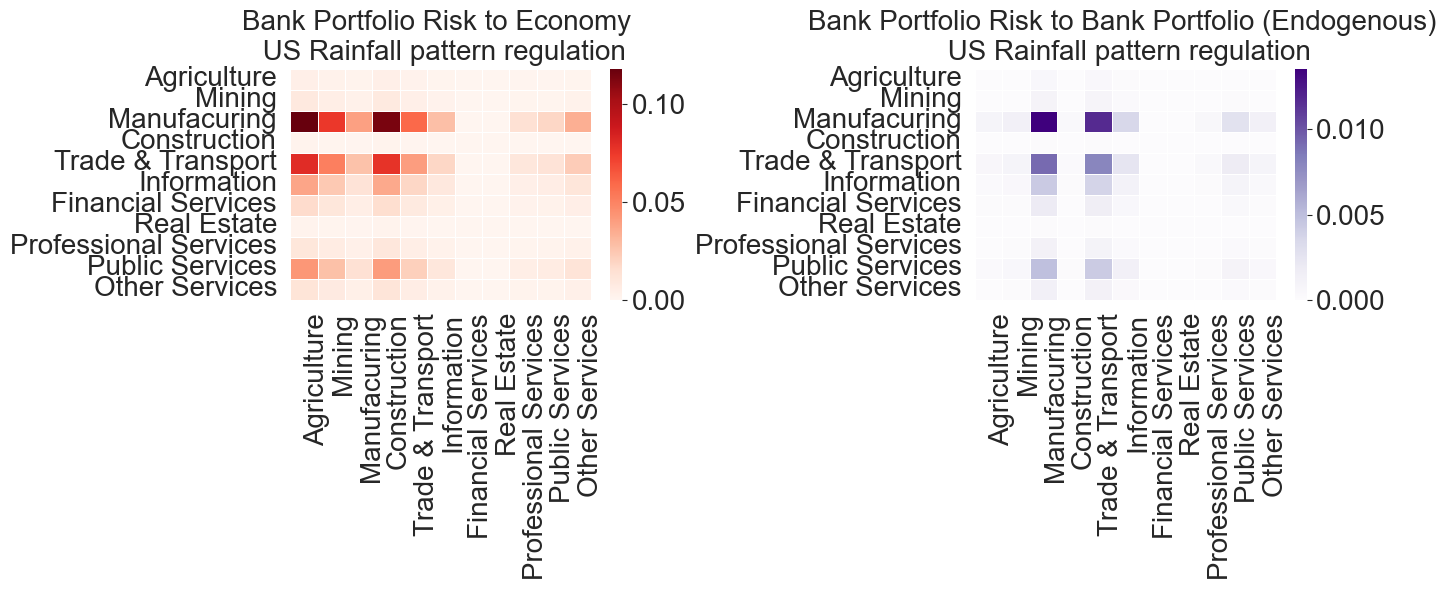

C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score = pd.merge(df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean()
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score_final = pd.merge(SNA_score.T, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean().T


0.3629406574286957


C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  finance_SNA_df = pd.merge(financial_region_average_region_df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).sum()


77013.69222431116


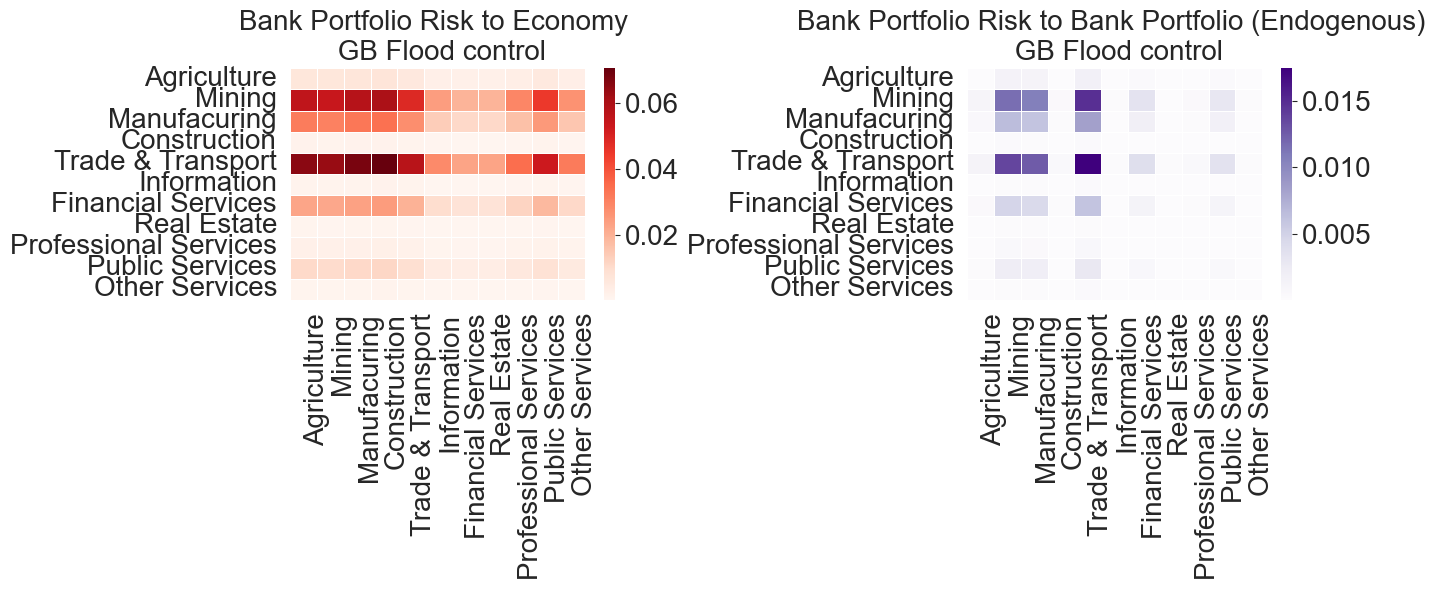

In [510]:
generate_sector_sector_heatmap('US', 'Rainfall pattern regulation')
generate_sector_sector_heatmap('GB', 'Flood control')


C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score = pd.merge(df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean()
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score_final = pd.merge(SNA_score.T, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean().T
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in

0.5908604723646265
665687.723609526


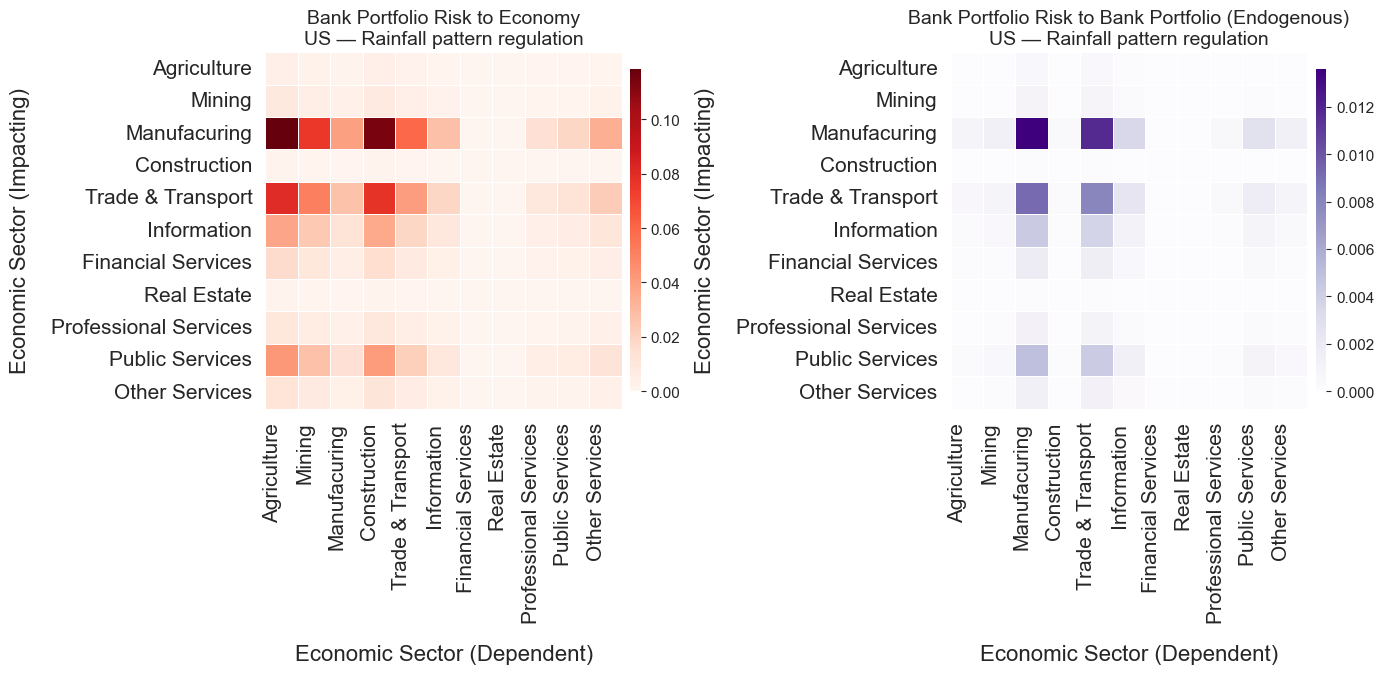

C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score = pd.merge(df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean()
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score_final = pd.merge(SNA_score.T, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean().T
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in

0.3629406574286957
77013.69222431116


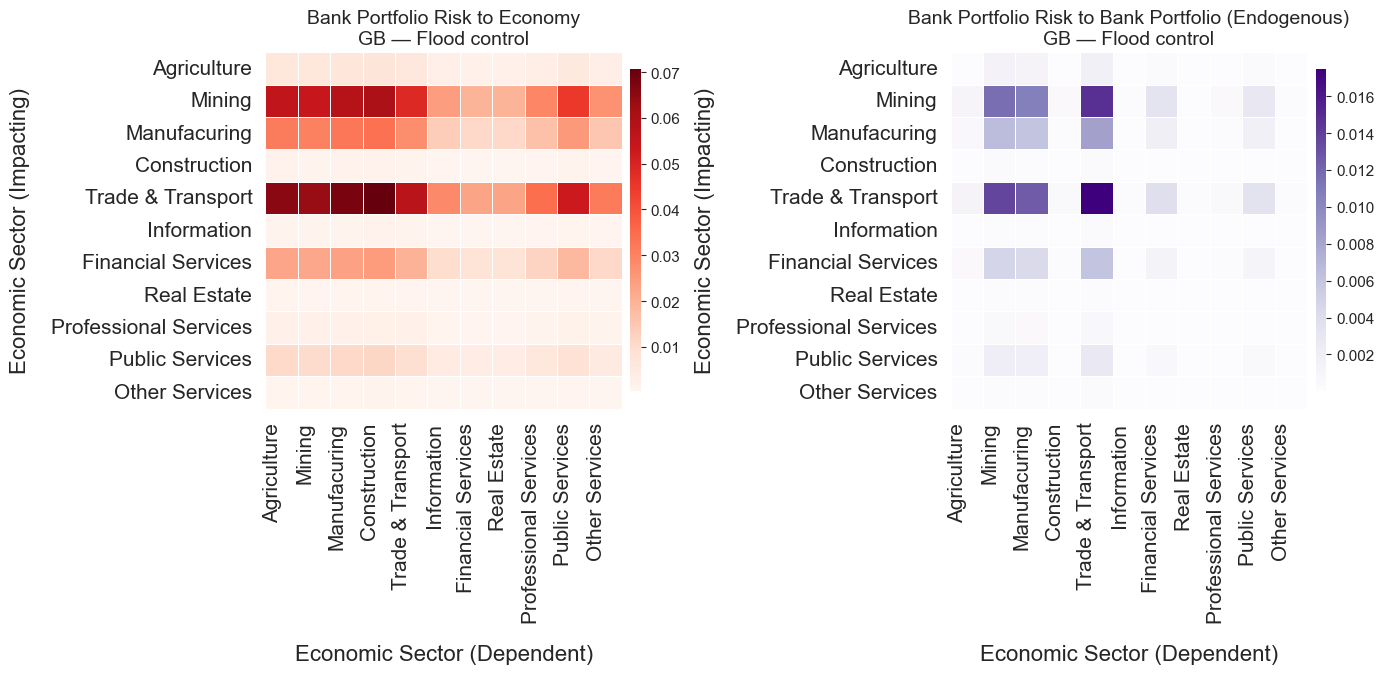

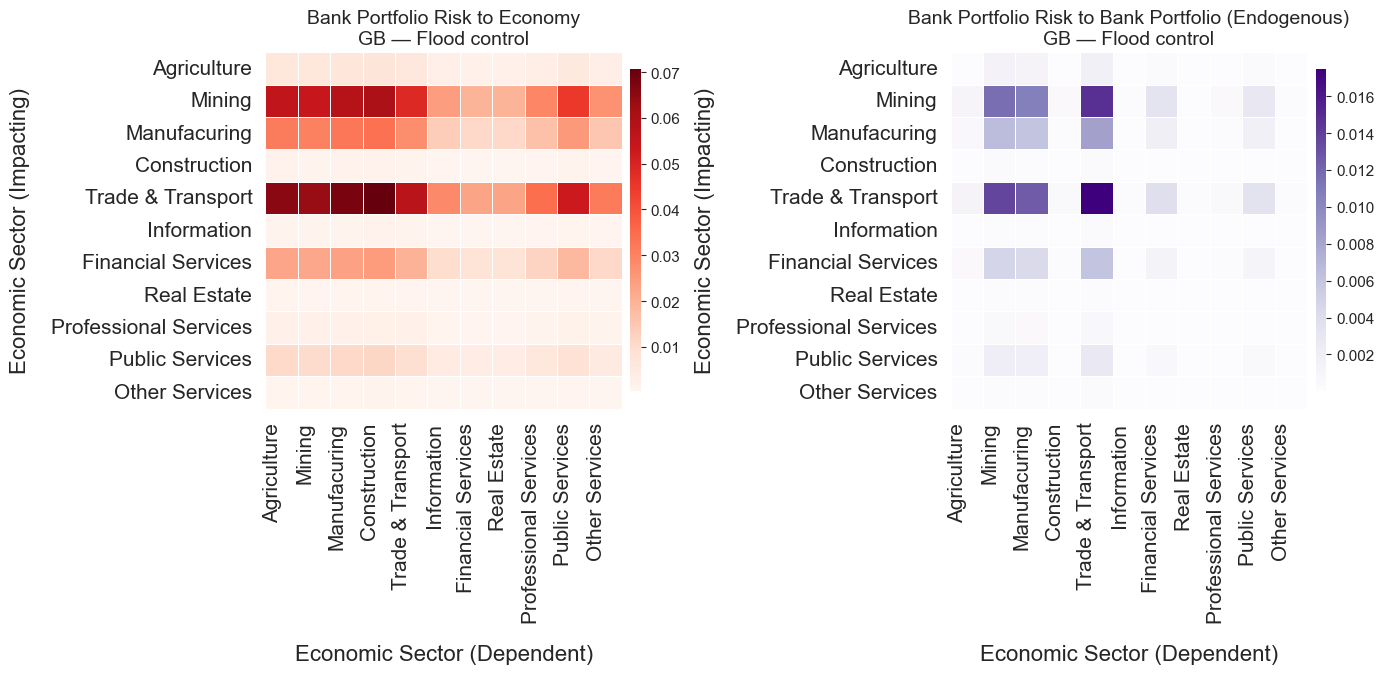

In [537]:
def generate_sector_sector_heatmap_updated(region, ESS):
    matrix_df = generate_sector_matrix_imp_dep(region, ESS)
    score_matrix, SNA_matrix_df, SNA_endogenous_df = aggregate_to_SNA(matrix_df, region)

    # -------------------------
    # 10) clean up sector names
    # (your mapping; keep as-is)
    sector_mapping = {
        "Agriculture": "Agriculture",
        "Mining and Industrial Activities": "Mining",
        "Manufacturing": "Manufacturing",
        "Construction": "Construction",
        "Trade, Transportation and Hospitality": "Trade & Transport",
        "Information and communication": "Information",
        "Finance and insurance": "Financial Services",
        "Real Estate": "Real Estate",
        "Professional and Support Services": "Professional Services",
        "Public Services (Admin, Education & Health)": "Public Services",
        "Other Services": "Other Services",
    }

    # rename index (works)
    SNA_matrix_clean_df = SNA_matrix_df.rename(index=sector_mapping)
    SNA_endogenous_clean_df = SNA_endogenous_df.rename(index=sector_mapping)

    # rename columns robustly (coerce to str and strip then map)
    SNA_matrix_clean_df.columns = [sector_mapping.get(str(c).strip(), c) for c in SNA_matrix_clean_df.columns]
    SNA_endogenous_clean_df.columns = [sector_mapping.get(str(c).strip(), c) for c in SNA_endogenous_clean_df.columns]

    # -------------------------
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 8.5))
    plt.subplots_adjust(wspace=0.5)
    # Common visual kwargs for both heatmaps
    heatmap_kwargs = dict(
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={
        "shrink": 0.5,   # shrink colorbar height (0–1)
        "aspect": 30,    # controls thickness
        "pad": 0.02      # spacing from heatmap
        }
    )

    # Left heatmap (Economy)
    hm0 = sns.heatmap(
        SNA_matrix_clean_df,
        ax=axs[0],
        cmap='Reds',
        **heatmap_kwargs
    )

    # Right heatmap (Endogenous)
    hm1 = sns.heatmap(
        SNA_endogenous_clean_df,
        ax=axs[1],
        cmap='Purples',
        **heatmap_kwargs
    )

    # Move x tick labels to top for both axes
    for ax, df in zip(axs, [SNA_matrix_clean_df, SNA_endogenous_clean_df]):
        # ax.xaxis.tick_top()

        # # Force one tick per label (guarantees alignment)
        # ax.set_xticks(np.arange(len(df.columns)) + 0.5)  # +0.5 aligns ticks with cell centers
        # ax.set_yticks(np.arange(len(df.index)) + 0.5)

        # Use the dataframe's labels explicitly (avoids any mismatch)
        ax.set_xticklabels(list(df.columns), rotation=90, ha='right', fontsize=15)
        ax.set_yticklabels(list(df.index), rotation=0, fontsize=15)
        
        # ---- ADD AXIS LABELS ----
        ax.set_xlabel("Economic Sector (Dependent)", fontsize=16, labelpad=15)
        ax.set_ylabel("Economic Sector (Impacting)", fontsize=16, labelpad=15)
    
        ax.tick_params(axis='both', which='both', length=6, width=1.0, direction='out')
        ax.set_xlim(0, len(df.columns))
        ax.set_ylim(len(df.index), 0)

        # Tick marks visible & reasonably sized
        ax.tick_params(axis='both', which='both', length=6, width=1.0, direction='out')

        # Optional: tighten axis limits so ticks align with cells
        ax.set_xlim(0, len(df.columns))
        ax.set_ylim(len(df.index), 0)

    # Increase colorbar tick label size
    for hm in (hm0, hm1):
        cbar = hm.collections[0].colorbar
        cbar.ax.tick_params(labelsize=11)
        # optionally give the colorbar a label
        # cbar.set_label('Value', fontsize=12)

    # Titles (multi-line) and fonts
    axs[0].set_title(f"Bank Portfolio Risk to Economy\n{region} — {ESS}", fontsize=14)
    axs[1].set_title(f"Bank Portfolio Risk to Bank Portfolio (Endogenous)\n{region} — {ESS}", fontsize=14)


    # Leave space for the top title region and bottom caption
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"{value_at_risk_figure_saving_path}/Bank contribution to society risk and own risk {region} {ESS}")

    plt.show()
    return fig

generate_sector_sector_heatmap_updated('US', 'Rainfall pattern regulation')
generate_sector_sector_heatmap_updated('GB', 'Flood control')

In [412]:
financial_data_df = pd.read_csv('C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/financial_data/GSIB_financial_data.csv', header=[0])
financial_data_average_bank_df = financial_data_df.drop(columns='Bank').groupby(['region', 'sector']).mean()
# # calculate the proportion of sectors for each region
region_totals = financial_data_average_bank_df.reset_index().drop(columns='sector').groupby(['region']).sum()
bank_data_w_region_df = pd.merge(financial_data_df.drop(columns=['sector', 'Bank']).groupby(['region']).sum(), financial_data_average_bank_df, right_on=['region'], left_on=['region'])
bank_data_w_region_df['region proportion'] = np.where(bank_data_w_region_df['production_x'] == 0, 0, bank_data_w_region_df['production_y'] / bank_data_w_region_df['production_x'])
bank_data_w_region_df

,production_x,production_y,region proportion
region,,,
AT,2.327704e+04,13.499112,5.799326e-04
AT,2.327704e+04,0.000000,0.000000e+00
AT,2.327704e+04,0.051297,2.203758e-06
AT,2.327704e+04,0.176562,7.585251e-06
AT,2.327704e+04,0.000426,1.828971e-08
...,...,...,...
ZA,1.972846e+06,3.655798,1.853058e-06
ZA,1.972846e+06,1.173396,5.947733e-07
ZA,1.972846e+06,1.700871,8.621407e-07


C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score = pd.merge(df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean()
C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  SNA_score_final = pd.merge(SNA_score.T, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).mean().T


0.3629406574286957


C:\Users\emmao\AppData\Local\Temp\ipykernel_41780\1993920618.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  finance_SNA_df = pd.merge(financial_region_average_region_df, SNA_converter, right_index=True, left_index=True).groupby(['Aggregation']).sum()


77013.69222431116


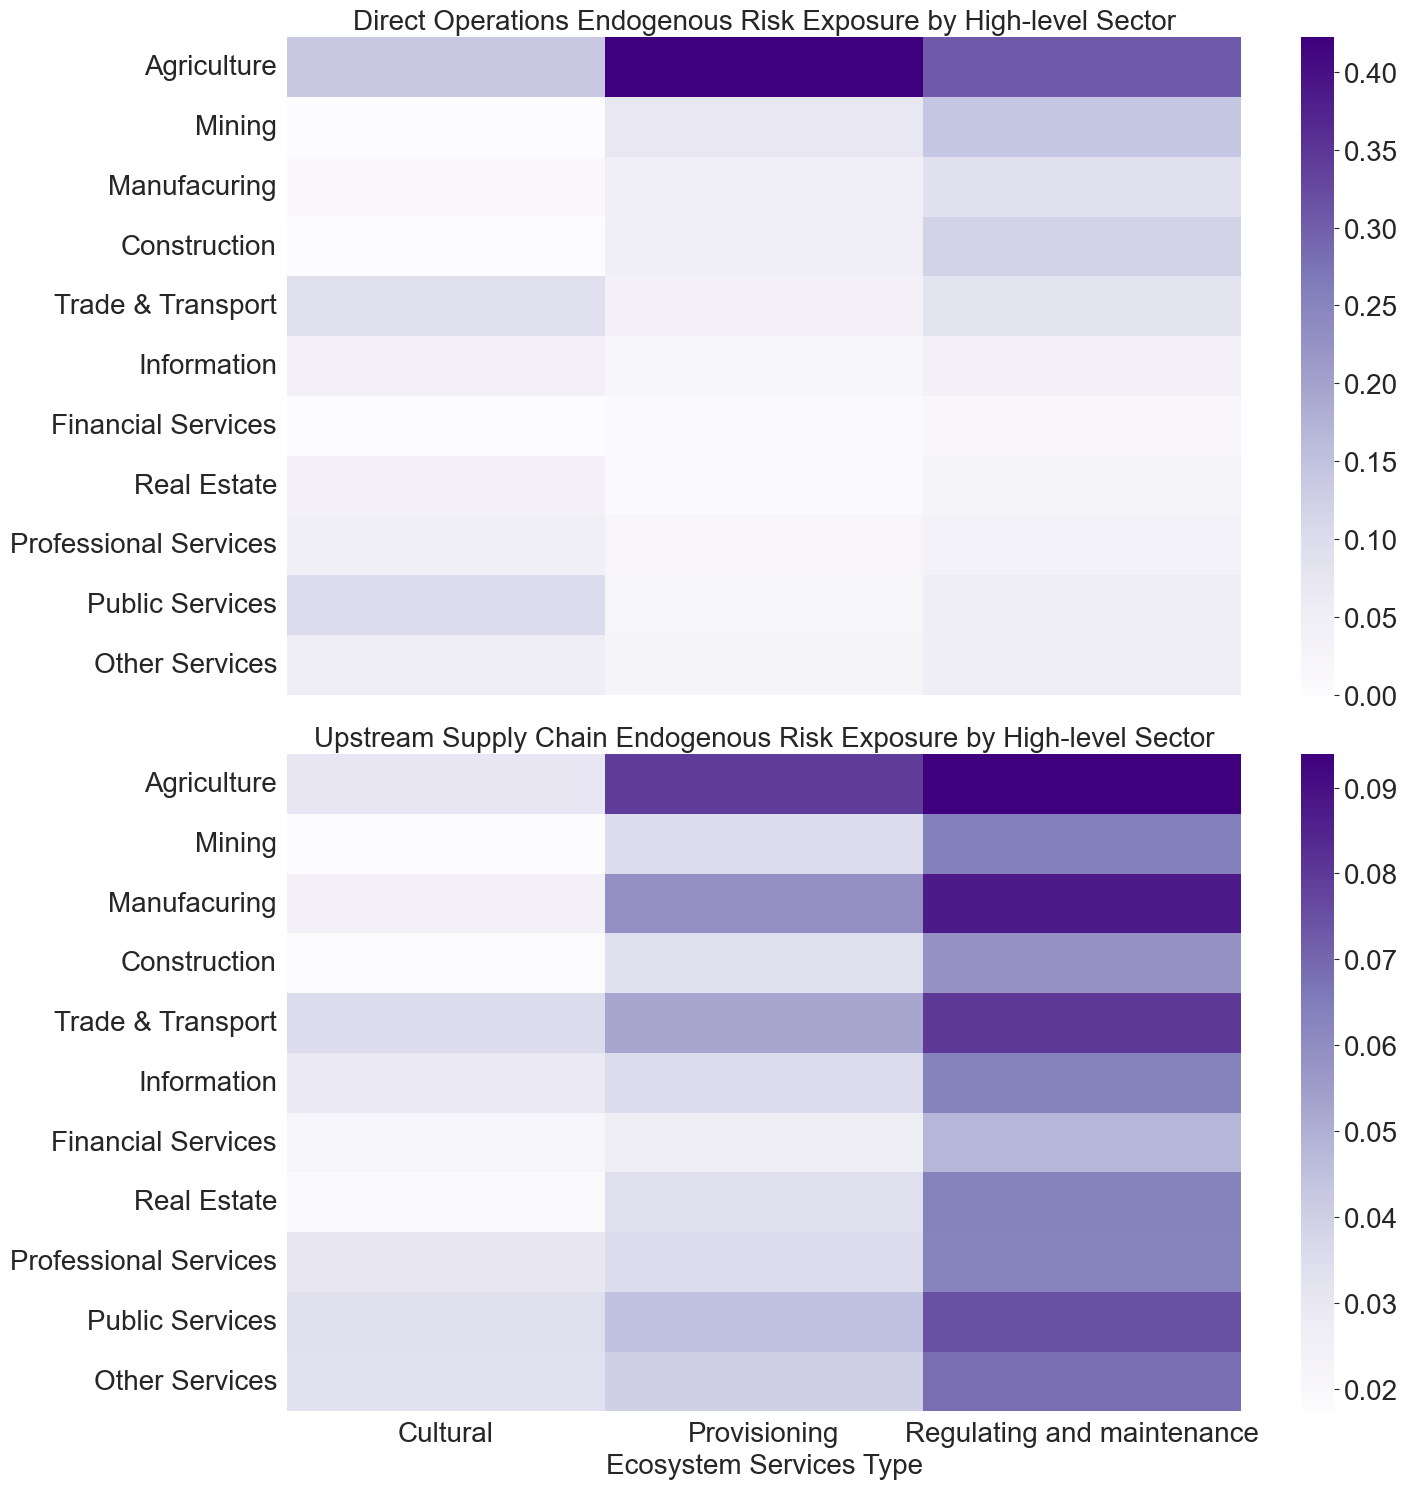

In [549]:
region = 'GB'
ESS = 'Flood control'
matrix_df = generate_sector_matrix_imp_dep(region, ESS)
score_matrix, SNA_matrix_df, SNA_endogenous_df = aggregate_to_SNA(matrix_df, region)

    # 10) clean up sector names
sector_mapping = {
"Agriculture": "Agriculture",
"Mining and Industrial Activities": "Mining",
"Manufacturing": "Manufacturing",
"Construction": "Construction",
"Trade, Transportation and Hospitality": "Trade & Transport",
"Information and communication": "Information",
"Finance and insurance": "Financial Services",
"Real Estate": "Real Estate",
"Professional and Support Services": "Professional Services",
"Public Services (Admin, Education & Health)": "Public Services",
"Other Services": "Other Services",
}

SNA_matrix_df = SNA_matrix_df.rename(index=sector_mapping)
SNA_endogenous_df = SNA_endogenous_df.rename(index=sector_mapping)
SNA_matrix_df.columns = [sector_mapping.get(str(c).strip(), c) for c in SNA_matrix_df.columns]
SNA_endogenous_df.columns = [sector_mapping.get(str(c).strip(), c) for c in SNA_endogenous_df.columns]

SNA_matrix_df

def aggregated_overlap_figures():
    """
    Create the aggregated figures
    :return: nothing
    """
    scope_1_score_df = pd.read_csv('C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Scope 1 Endogenous Risk Sector.csv', header=[0], index_col=[0])
    score_3_score_df = pd.read_csv('C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Scope 3 Endogenous Risk Sector.csv', header=[0], index_col=[0])
    
    sector_mapping = {
    "Agriculture": "Agriculture",
    "Mining and Industrial Activities": "Mining",
    "Manufacturing": "Manufacturing",
    "Construction": "Construction",
    "Trade, Transportation and Hospitality": "Trade & Transport",
    "Information and communication": "Information",
    "Finance and insurance": "Financial Services",
    "Real Estate": "Real Estate",
    "Professional and Support Services": "Professional Services",
    "Public Services (Admin, Education & Health)": "Public Services",
    "Other Services": "Other Services",
    }
    
    scope_1_score_df = scope_1_score_df.rename(columns=sector_mapping)
    score_3_score_df = score_3_score_df.rename(columns=sector_mapping)
    
    colors = sns.color_palette("Purples", as_cmap=True)
    fig, axs = plt.subplots(2, 1, figsize =(15,15))


    
    ylabels0 = scope_1_score_df.T.index.astype(str)
    hm0 = sns.heatmap(scope_1_score_df.T, cmap=colors, ax=axs[0], yticklabels=ylabels0)
    # scope_1_score_df.T.to_csv(
        # 'C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Scope 1 Endogenous Risk Sector.csv')
    axs[0].set_title('Direct Operations Endogenous Risk Exposure by High-level Sector')
    axs[0].set_xlabel('')
    # axs[0].set_ylabel('Ecosystem Services Type')
    axs[0].set_xticks([])
    
    ylabels1 = score_3_score_df.T.index.astype(str)
    hm1 = sns.heatmap(score_3_score_df.T, cmap=colors, ax=axs[1], yticklabels=ylabels1)
    # score_3_score_df.T.to_csv('C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results/Scope 3 Endogenous Risk Sector.csv')
    axs[1].set_title('Upstream Supply Chain Endogenous Risk Exposure by High-level Sector')
    axs[1].set_xlabel('')
    axs[1].tick_params(axis='x', rotation=90)
    axs[1].set_xlabel('Ecosystem Services Type')

    # Force a draw so tick Text objects exist
    fig.canvas.draw()

    # Set y-tick labels horizontal (parallel to bottom) and align them
    for ax in (axs[0], axs[1]):
        plt.setp(ax.get_yticklabels(),
                 rotation=0,  # horizontal
                 ha='right',  # align labels to the right of the tick
                 rotation_mode='anchor')

    for ax in (axs[0], axs[1]):
        plt.setp(ax.get_xticklabels(),
                 rotation=0)
                 # ha='right',  # important for 45° readability
                 # rotation_mode='anchor')

    # If labels overlap, increase left/right margin (tweak as needed)
    fig.subplots_adjust(left=0.18, right=0.95)  # increase left to give y-label space

    for i in range(2):
        cbar = axs[i].collections[0].colorbar
        cbar.ax.tick_params(labelsize=20)
        axs[i].title.set_size(20)

        items = [axs[i].title, axs[i].yaxis.label, axs[i].xaxis.label] + axs[i].get_xticklabels() + axs[
            i].get_yticklabels()
        if axs[i].legend_:
            items += axs[i].legend_.get_texts()  # Get legend text elements
        for item in items:
            item.set_fontsize(20)

    plt.tight_layout()
    plt.savefig(f'{value_at_risk_figure_saving_path}/Sectoral Endogenous Risk ESS Type')
    plt.show()

    return None

aggregated_overlap_figures()

In [14]:
from banks_at_risk.Setup.var_paths import GSIB_finance_var_both_scope1_max, GSIB_finance_var_both_scope3_source_mean, \
    GSIB_finance_var_dep_scope3_source_max, GSIB_finance_var_imp_scope1_min, GSIB_finance_var_both_scope1_mean, \
    GSIB_finance_var_dep_scope1_max, GSIB_finance_var_both_scope3_source_min, GSIB_finance_var_both_scope1_min, \
    GSIB_finance_var_both_scope3_source_max, GSIB_finance_var_dep_scope3_source_mean, GSIB_finance_var_dep_scope1_mean, \
    GSIB_finance_var_imp_scope3_source_max, GSIB_finance_var_imp_scope1_max, GSIB_finance_var_dep_scope3_source_min, \
    GSIB_finance_var_dep_scope1_min, GSIB_finance_var_imp_scope3_source_mean, GSIB_finance_var_imp_scope1_mean, \
    GSIB_finance_var_both_scope3_value_chain_max, GSIB_finance_var_imp_scope3_source_min, \
    GSIB_finance_var_both_scope3_value_chain_mean, GSIB_finance_var_both_scope3_value_chain_min, \
    GSIB_finance_var_dep_scope3_value_chain_max, GSIB_finance_var_dep_scope3_value_chain_mean, \
    GSIB_finance_var_dep_scope3_value_chain_min, GSIB_finance_var_imp_scope3_value_chain_max, \
    GSIB_finance_var_imp_scope3_value_chain_mean, GSIB_finance_var_imp_scope3_value_chain_min, \
    GSIB_finance_var_both_scope1_sector_max, GSIB_finance_var_both_scope1_sector_mean, \
    GSIB_finance_var_both_scope1_sector_min, GSIB_finance_var_both_scope3_source_sector_mean, \
    GSIB_finance_var_both_scope3_source_sector_max, GSIB_finance_var_both_scope3_source_sector_min, \
    GSIB_system_var_dep_scope3_source_max, GSIB_system_var_both_scope3_source_sector_max, \
    GSIB_system_var_dep_scope3_value_chain_max, GSIB_system_var_imp_scope3_value_chain_max, \
    GSIB_system_var_dep_scope3_value_chain_mean, GSIB_system_var_dep_scope3_value_chain_min, \
    GSIB_system_var_both_scope1_max, GSIB_system_var_both_scope1_sector_max, GSIB_system_var_dep_scope1_mean, \
    GSIB_system_var_both_scope1_mean, GSIB_system_var_both_scope1_sector_mean, GSIB_system_var_dep_scope1_max, \
    GSIB_system_var_both_scope1_min, GSIB_system_var_both_scope1_sector_min, GSIB_system_var_imp_scope1_max, \
    GSIB_system_var_dep_scope1_min, GSIB_system_var_dep_scope3_source_min, GSIB_system_var_both_scope3_source_max, \
    GSIB_system_var_imp_scope1_mean, GSIB_system_var_imp_scope3_source_mean, GSIB_system_var_both_scope3_source_min, \
    GSIB_system_var_imp_scope1_min, GSIB_system_var_imp_scope3_source_min, GSIB_system_var_both_scope3_source_mean, \
    GSIB_system_var_dep_scope3_source_mean, GSIB_system_var_both_scope3_source_sector_mean, \
    GSIB_system_var_imp_scope3_source_max, GSIB_system_var_both_scope3_source_sector_min, \
    GSIB_system_var_both_scope3_value_chain_max, GSIB_system_var_imp_scope3_value_chain_mean, \
    GSIB_system_var_both_scope3_value_chain_mean, GSIB_system_var_imp_scope3_value_chain_min, \
    GSIB_system_var_both_scope3_value_chain_min
from banks_at_risk.Value_at_Risk_Analysis.helper_value_at_risk_analysis_GSIB import proportion_transformation, get_var_scores
from banks_at_risk.Value_at_Risk.helper_value_at_risk_GSIB import finance_GSIB_reformat
import re

# get the impact, dependency and endogenous risk results with the mean methodological treatment
impact_nvars_mean = get_var_scores('Impact', 'mean')
dependency_nvars_mean = get_var_scores('Dependency', 'mean')
both_nvars_mean = get_var_scores('Both', 'mean')

# get the impact, dependency and endogenous risk results with the min methodological treatment
impact_nvars_min = get_var_scores('Impact', 'min')
dependency_nvars_min = get_var_scores('Dependency', 'min')
both_nvars_min = get_var_scores('Both', 'min')

# get the impact, dependency and endogenous risk results with the max methodological treatment
impact_nvars_max = get_var_scores('Impact', 'max')
dependency_nvars_max = get_var_scores('Dependency', 'max')
both_nvars_max = get_var_scores('Both', 'max')

# get the sectoral overlap scores for the three methodological treatments
sector_scores_mean = get_var_scores('Sector', 'mean')
sector_scores_min = get_var_scores('Sector', 'min')
sector_scores_max = get_var_scores('Sector', 'max')

# get the system-level endongeous risk scores for each of the methodological treatments
system_both_scores_mean = get_var_scores('System Both', 'mean')
system_both_scores_min = get_var_scores('System Both', 'min')
system_both_scores_max = get_var_scores('System Both', 'max')
# get the sectoral overlap system-level endogenous risk scores for each of the methodological treatments
system_sector_both_scores_mean = get_var_scores('System Sector', 'mean')
system_sector_both_scores_min = get_var_scores('System Sector', 'min')
system_sector_both_scores_max = get_var_scores('System Sector', 'max')

In [576]:
import re
def plot_bar_chart_system_sector(both_mean, both_min, both_max, sector_mean, sector_min, sector_max, portfolio_mean, portfolio_min, portfolio_max):
    """
    This function plots bar chart for the system-level based on the scores for direct operations and upstream supply
    chain
    :param both_mean: results with mean methoodological treatment - system-level
    :param both_min: results with min methoodological treatment - system-level
    :param both_max: results with max methoodological treatment - system-level
    :param sector_mean: results with mean methoodological treatment - sector-level
    :param sector_min: results with min methoodological treatment - sector-level
    :param sector_max: results with max methoodological treatment - sector-level
    :param portfolio_mean: results with mean methoodological treatment - portfolio-level
    :param portfolio_min: results with min methoodological treatment - portfolio-level
    :param portfolio_max: results with max methoodological treatment - portfolio-level
    :return:
    """
    # determine score type
    if 'Both' in both_mean[0].name:
        folder = 'Overlap'
    else:
        if 'Impact' in both_mean[0].name:
            folder = 'Impact'
        if 'Dependency' in both_mean[0].name:
            folder = 'Dependency'

    # store the scores in the appropriate list based on whether proportional or absolute and for direct operations,
    # or upstream supply chain for each methodological treatment
    scope_1_var_finance = []
    scope_3_var_finance = []
    scope_1_var_finance_abs = []
    scope_3_var_finance_abs = []
    for score in both_mean:
        if 'Proportional' in score.name:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} mean'
                scope_1_var_finance.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} mean'
                scope_3_var_finance.append(score)
        else:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} mean'
                scope_1_var_finance_abs.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} mean'
                scope_3_var_finance_abs.append(score)
    for score in both_min:
        if 'Proportional' in score.name:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} min'
                scope_1_var_finance.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} min'
                scope_3_var_finance.append(score)
        else:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} min'
                scope_1_var_finance_abs.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} min'
                scope_3_var_finance_abs.append(score)
    for score in both_max:
        if 'Proportional' in score.name:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} max'
                scope_1_var_finance.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} max'
                scope_3_var_finance.append(score)
        else:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} max'
                scope_1_var_finance_abs.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} max'
                scope_3_var_finance_abs.append(score)

    # sector-level
    # store the scores in the appropriate list based on whether proportional or absolute and for direct operations,
    # or upstream supply chain for each methodological treatment
    scope_1_var_finance_sector = []
    scope_3_var_finance_sector = []
    scope_1_var_finance_abs_sector = []
    scope_3_var_finance_abs_sector = []
    for score in sector_mean:
        if 'Proportional' in score.name:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} mean'
                scope_1_var_finance_sector.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} mean'
                scope_3_var_finance_sector.append(score)
        else:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} mean'
                scope_1_var_finance_abs_sector.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} mean'
                scope_3_var_finance_abs_sector.append(score)
    for score in sector_min:
        if 'Proportional' in score.name:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} min'
                scope_1_var_finance_sector.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} min'
                scope_3_var_finance_sector.append(score)
        else:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} min'
                scope_1_var_finance_abs_sector.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} min'
                scope_3_var_finance_abs_sector.append(score)
    for score in sector_max:
        if 'Proportional' in score.name:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} max'
                scope_1_var_finance_sector.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} max'
                scope_3_var_finance_sector.append(score)
        else:
            if 'Scope 1' in score.name:
                score.name = f'{score.name} max'
                scope_1_var_finance_abs_sector.append(score)
            if 'Source' in score.name:
                score.name = f'{score.name} max'
                scope_3_var_finance_abs_sector.append(score)

    # portfolio-level
    # store the scores in the appropriate list based on whether proportional or absolute and for direct operations,
    # or upstream supply chain for each methodological treatment

    # generate proportional
    # get financial data
    financial_data_df = finance_GSIB_reformat()
    # get total value of portfolios across all banks
    system_total = financial_data_df['EUR m adjusted'].sum()

    scope_1_var_finance_portfolio = []
    scope_3_var_finance_portfolio = []
    scope_1_var_finance_abs_portfolio = []
    scope_3_var_finance_abs_portfolio = []
    for score in portfolio_mean:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} mean'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional mean'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} mean'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional mean'
                scope_3_var_finance_portfolio.append(prop_df)

    for score in portfolio_min:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} min'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional min'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} min'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional min'
                scope_3_var_finance_portfolio.append(prop_df)
    for score in portfolio_max:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} max'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional max'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} max'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional max'
                scope_3_var_finance_portfolio.append(prop_df)

      # ---------- 1) Ordered services (grouped) and mappings ----------
    services = [
        # Water group
        "Water supply ",
        "Water flow regulation",
        "Water purification",
        "Storm mitigation",
        "Flood control",

        # Soil group
        "Soil and sediment quality regulation",
        "Soil and sediment retention",

        # Air / Climate group
        "Rainfall pattern regulation",
        "Global climate regulation",
        "Local (micro and meso) climate regulation",
        "Dilution by atmosphere and ecosystems",
        "Air filtration",

        # Biological group
        "Biomass provisioning",
        "Genetic material",
        "Pollination",
        "Biological control",
        "Nursery population and habitat maintenance",

        # Provisioning / Energy
        "Animal-based energy",

        # Waste / Remediation
        "Solid waste remediation",

        # Sensory / Noise
        "Mediation of sensory impacts (other than noise)",
        "Noise attenuation "
    ]

    # service -> subgroup mapping (exact keys as provided)
    service_to_group = {
        "Water supply ": "Water",
        "Water flow regulation": "Water",
        "Water purification": "Water",
        "Storm mitigation": "Water",
        "Flood control": "Water",
        "Soil and sediment quality regulation": "Soil",
        "Soil and sediment retention": "Soil",
        "Rainfall pattern regulation": "Air/Climate",
        "Global climate regulation": "Air/Climate",
        "Local (micro and meso) climate regulation": "Air/Climate",
        "Dilution by atmosphere and ecosystems": "Air/Climate",
        "Air filtration": "Air/Climate",
        "Biomass provisioning": "Biological",
        "Genetic material": "Biological",
        "Pollination": "Biological",
        "Biological control": "Biological",
        "Nursery population and habitat maintenance": "Biological",
        "Animal-based energy": "Provisioning",
        "Solid waste remediation": "Waste",
        "Mediation of sensory impacts (other than noise)": "Sensory",
        "Noise attenuation ": "Sensory",
    }
    # normalized keys for robust lookups
    service_to_group_norm = {k.strip().lower(): v for k, v in service_to_group.items()}

    # shorter labels for x ticks
    short_label_map = {
    "Water supply ": "Water supply",
    "Animal-based energy": "Animal-based energy",
    "Genetic material": "Genetic material",
    "Biomass provisioning": "Biomass provisioning",
    "Soil and sediment quality regulation": "Soil quality",
    "Rainfall pattern regulation": "Rainfall regulation",
    "Soil and sediment retention": "Soil Retention",
    "Pollination": "Pollination",
    "Solid waste remediation": "Waste remediation",
    "Water flow regulation": "Water flow regulation",
    "Storm mitigation": "Storm mitigation",
    "Water purification": "Water purification",
    "Air filtration": "Air filtration",
    "Mediation of sensory impacts (other than noise)": "Mediation of sensory impacts",
    "Global climate regulation": "Global climate regulation",
    "Flood control": "Flood control",
    "Local (micro and meso) climate regulation": "Local climate regulation",
    "Biological control": "Biological control",
    "Dilution by atmosphere and ecosystems": "Dilution by ecosystem",
    "Nursery population and habitat maintenance": "Nursery habitat maintenance",
    "Noise attenuation ": "Noise attenuation"
    }

        # ---------- helper: aggregate sheet list into ordered min/mean/max dicts ----------
    def aggregate_by_service_from_sheet_list(sheet_list):
        """Return (min_dict, mean_dict, max_dict) for the provided list of sheets.
        Each dict keys follow the `services` order and missing columns default to 0.0."""
        min_values = {s: 0.0 for s in services}
        mean_values = {s: 0.0 for s in services}
        max_values = {s: 0.0 for s in services}

        # precompute lower-case column map helper when needed
        for sheet in sheet_list:
            one_bank_df = sheet.copy().reset_index()
            # create mapping from normalized column name -> actual column name for robust lookups
            cols_lower = {c.strip().lower(): c for c in one_bank_df.columns}

            this_sum = {}
            for s in services:
                if s in one_bank_df.columns:
                    this_sum[s] = float(np.nansum(one_bank_df[s].fillna(0)))
                else:
                    key = s.strip().lower()
                    if key in cols_lower:
                        this_sum[s] = float(np.nansum(one_bank_df[cols_lower[key]].fillna(0)))
                    else:
                        this_sum[s] = 0.0

            # route to min/mean/max depending on sheet.name
            name = sheet.name if hasattr(sheet, 'name') else ''
            if re.search('min', name, re.IGNORECASE):
                min_values = this_sum
            elif re.search('mean', name, re.IGNORECASE):
                mean_values = this_sum
            elif re.search('max', name, re.IGNORECASE):
                max_values = this_sum
            else:
                # ignore / or could combine if necessary
                pass

        return min_values, mean_values, max_values
    
     # ---------- NEW: pick top 11 services by combined mean (scope1 + scope3) ----------
    # Build a combined list of all relevant scope sheets (sector, portfolio, system) for scope1+scope3
    all_scope_sheets = (
        scope_1_var_finance_sector + scope_1_var_finance_portfolio + scope_1_var_finance +
        scope_3_var_finance_sector + scope_3_var_finance_portfolio + scope_3_var_finance
    )

    # If there are no sheets (defensive), skip filtering
    if all_scope_sheets:
        _, combined_mean_all, _ = aggregate_by_service_from_sheet_list(all_scope_sheets)

        # select top 11 services by combined mean (descending)
        top11 = sorted(services, key=lambda s: combined_mean_all.get(s, 0.0), reverse=True)[:11]
        top11_set = set(top11)

        # preserve your grouped/service order but only keep the top-11
        services = [s for s in services if s in top11_set]

        # reduce short_label_map to the selected services (fallback to service name kept if missing)
        short_label_map = {s: short_label_map.get(s, s) for s in services}
    # else: nothing to do (keeps original 'services' if no sheets found)
    
    # ---------- Prepare figure & level lists ----------
    plt.figure(figsize=(20, 20))
    scope_1_levels = [scope_1_var_finance_sector, scope_1_var_finance_portfolio, scope_1_var_finance]
    scope_3_levels = [scope_3_var_finance_sector, scope_3_var_finance_portfolio, scope_3_var_finance]
    levels = ['Sector', 'Portfolio', 'System']
    bar_adjustments = [-0.3, 0, 0.3]

    # ---------- Top: Scope 1 (Direct operations) ----------
    ax = plt.subplot(2, 1, 1)
    i = 0
    for level_list in scope_1_levels:
        scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)

        X_axis = np.arange(len(services))
        mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
        min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
        max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100

        lower_err = mean_arr - min_arr
        upper_err = max_arr - mean_arr
        asym_err = np.array([lower_err, upper_err])

        ax.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
        ax.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')

        i += 1

    ax.legend()
    ax.set_xticks([])

    if folder == 'Overlap':
        ax.set_title('Endogenous Risk Exposure - Direct Operations')
    else:
        ax.set_title(f'System-level {folder} Value at Risk for Direct Operations and Upstream Supply Chain')

    items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    if ax.legend_:
        items += ax.legend_.get_texts()
    for item in items:
        item.set_fontsize(20)

    # ---------- Bottom: Scope 3 (Upstream supply chain) ----------
    ax2 = plt.subplot(2, 1, 2, sharey=ax)
    i = 0
    for level_list in scope_3_levels:
        scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)

        X_axis = np.arange(len(services))
        mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
        min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
        max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100

        lower_err = mean_arr - min_arr
        upper_err = max_arr - mean_arr
        asym_err = np.array([lower_err, upper_err])

        ax2.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
        ax2.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')

        i += 1

    ax2.legend()

    # tidy x labels using the short map
    x_labels = [short_label_map.get(s, s) for s in services]
    ax2.set_xticks(np.arange(len(services)))
    ax2.set_xticklabels(x_labels, rotation=90, ha='right')
    ax2.set_title('Endogenous Risk Exposure - Upstream Supply Chain')

    items = [ax2.title, ax2.yaxis.label, ax2.xaxis.label] + ax2.get_xticklabels() + ax2.get_yticklabels()
    if ax2.legend_:
        items += ax2.legend_.get_texts()
    for item in items:
        item.set_fontsize(20)

    plt.tight_layout()
    plt.savefig(
        f'{value_at_risk_figure_saving_path}/Value at Risk for Banks with Error Bars Percentage Sector Portfolio System')
    plt.show()
    plt.close()

    return None

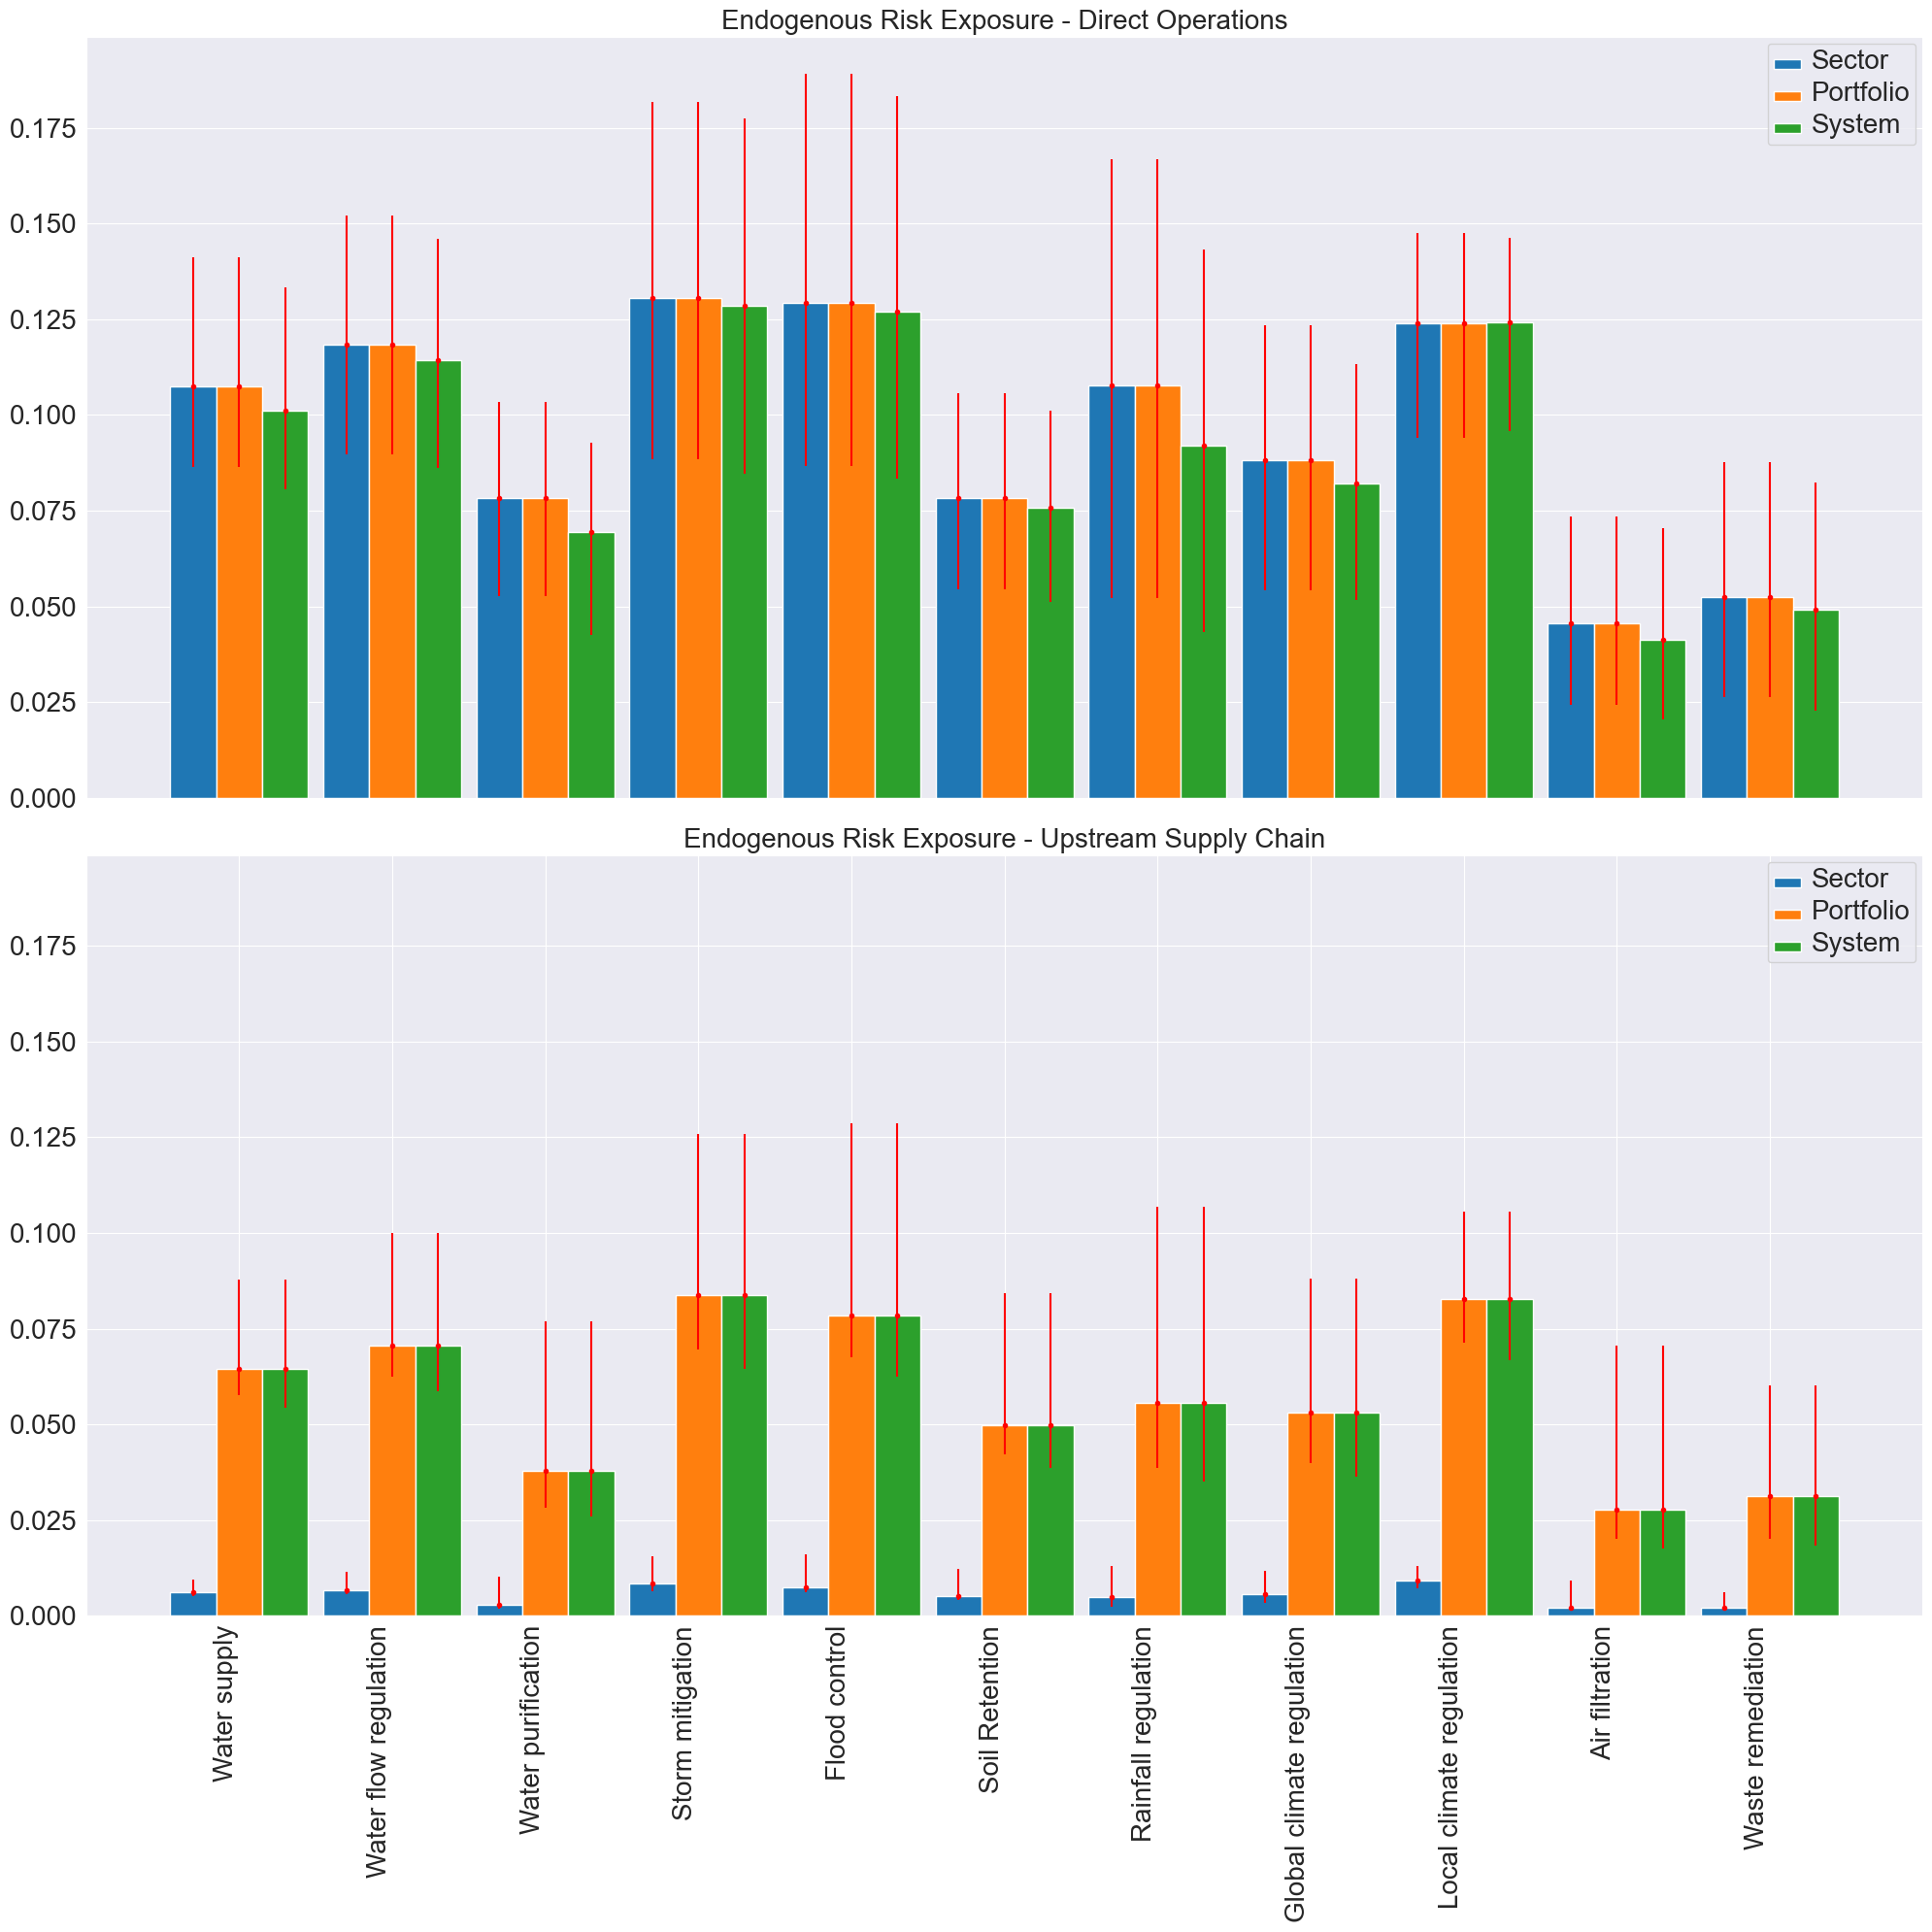

In [577]:
plot_bar_chart_system_sector(system_both_scores_mean, system_both_scores_min, system_both_scores_max, system_sector_both_scores_mean, system_sector_both_scores_min, system_sector_both_scores_max, both_nvars_mean, both_nvars_min, both_nvars_max)


In [7]:
both_nvars_mean

NameError: name 'both_nvars_mean' is not defined

In [ ]:
plt.figure(figsize=(20, 20))

    # create figure and subplot
    # plt.subplots(1, 2)

    # create list of three relevant levels
    scope_1_levels = [scope_1_var_finance_sector, scope_1_var_finance_portfolio, scope_1_var_finance]
    scope_3_levels = [scope_3_var_finance_sector, scope_3_var_finance_portfolio, scope_3_var_finance]
    
    
    levels = ['Sector', 'Portfolio', 'System']
    bar_adjustments = [-0.3, 0, 0.3]

    # loop through the system-level proportional scores - direct operations
    i = 0
    ax = plt.subplot(2, 1, 1)
    for level_list in scope_1_levels:
        for sheet in level_list:
            df = sheet.copy()
            one_bank_df = df.reset_index()
            mydict = {}
            # loop through ecosystem services
            for service in services:
                # get the total risk for the ecosystem service
                var = np.sum(one_bank_df[service])
                mydict[service] = var
            # assign to the appropriate methodological treatment
            if re.search('min', sheet.name):
                scope_1_min_values = mydict
            if re.search('mean', sheet.name):
                scope_1_mean_values = mydict
            if re.search('max', sheet.name):
                scope_1_max_values = mydict
        # generate the xticks with the ecosystem services
        X_axis = np.arange(len(services))

        # scope 1 - direct operations - format values for plotting
        scope_1_mean = np.array(list(scope_1_mean_values.values()))
        scope_1_min = np.array(list(scope_1_min_values.values()))
        scope_1_max = np.array(list(scope_1_max_values.values()))

        # create values for error bars
        lower_err_scope_1 = (scope_1_mean) - (scope_1_min)
        higher_err_scope_1 = (scope_1_max) - (scope_1_mean)
        # format error bar values for plotting
        asymetric_error_scope_1 = np.array(list(zip(lower_err_scope_1, higher_err_scope_1))).T

        # plot the bar chart direct operations bar
        if folder == 'Overlap':
            ax.bar(X_axis + bar_adjustments[i], scope_1_mean_values.values(), 0.3, label=f'{levels[i]}')
        else:
            ax.bar(X_axis + bar_adjustments[i], scope_1_mean_values.values(), 0.3, label=f'{levels[i]}')
        # plot the error bars
        ax.errorbar(X_axis + bar_adjustments[i], scope_1_mean_values.values(), yerr=asymetric_error_scope_1, fmt='r.')

        i = i + 1
    # generate the legend and xticks
    ax.legend()
    ax.set_xticks([])

    # set the figure title
    if folder == 'Overlap':
        ax.set_title(f'Endogenous Risk Exposure - Direct Operations')
    else:
        ax.set_title(f' System-level {folder} Value at Risk for Direction Operations and Upstream Supply Chain')
    # ax.set_xticks(X_axis, services, rotation=90, ha='right')

    items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    if ax.legend_:
        items += ax.legend_.get_texts()  # Get legend text elements
    for item in items:
        item.set_fontsize(20)

    # loop through the system-level proportional scores - direct operations
    i = 0
    ax = plt.subplot(2, 1, 2, sharey=ax)
    for level_list in scope_3_levels:
        for sheet in level_list:
            df = sheet.copy()
            one_bank_df = df.reset_index()
            mydict = {}
            # loop through ecosystem services
            for service in services:
                # get the total risk for the ecosystem service
                var = np.sum(one_bank_df[service])
                mydict[service] = var
            # assign to the appropriate methodological treatment
            if re.search('min', sheet.name):
                scope_1_min_values = mydict
            if re.search('mean', sheet.name):
                scope_1_mean_values = mydict
            if re.search('max', sheet.name):
                scope_1_max_values = mydict
        # generate the xticks with the ecosystem services
        X_axis = np.arange(len(services))

        # scope 1 - direct operations - format values for plotting
        scope_1_mean = np.array(list(scope_1_mean_values.values()))
        scope_1_min = np.array(list(scope_1_min_values.values()))
        scope_1_max = np.array(list(scope_1_max_values.values()))

        # create values for error bars
        lower_err_scope_1 = (scope_1_mean) - (scope_1_min)
        higher_err_scope_1 = (scope_1_max) - (scope_1_mean)
        # format error bar values for plotting
        asymetric_error_scope_1 = np.array(list(zip(lower_err_scope_1, higher_err_scope_1))).T

        # plot the bar chart direct operations bar
        if folder == 'Overlap':
            ax.bar(X_axis + bar_adjustments[i], scope_1_mean_values.values(), 0.3, label=f'{levels[i]}')
        else:
            ax.bar(X_axis + bar_adjustments[i], scope_1_mean_values.values(), 0.3, label=f'{levels[i]}')

        # plot the error bars
        ax.errorbar(X_axis + bar_adjustments[i], scope_1_mean_values.values(), yerr=asymetric_error_scope_1,
                    fmt='r.')

        i = i + 1

    # generate the legend and xticks
    ax.legend()
    x_labels = [s.split(" - ")[-1] for s in services]
    ax.set_xticks(X_axis, x_labels, rotation=90, ha='right')
    ax.set_title('Endogenous Risk Exposure - Upstream Supply Chain')

    items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    if ax.legend_:
        items += ax.legend_.get_texts()  # Get legend text elements
    for item in items:
        item.set_fontsize(20)

    # adjust the layout
    plt.tight_layout()
    # save figure
    # plt.savefig(
    #     f'{value_at_risk_figure_saving_path}/{folder}/{folder} Value at Risk for Banks with Error Bars Percentage Sector Portfolio System')
    plt.show()
    plt.close()

    return None

In [ ]:
import re
def plot_bar_chart_complex(portfolio_mean, portfolio_min, portfolio_max):
    """
    This function plots bar chart for the portfolio-level based on the scores for direct operations and upstream supply
    chain
    :param portfolio_mean: results with mean methoodological treatment - portfolio-level
    :param portfolio_min: results with min methoodological treatment - portfolio-level
    :param portfolio_max: results with max methoodological treatment - portfolio-level
    :return:
    """
    # determine score type
    if 'Both' in portfolio_mean[0].name:
        folder = 'Overlap'
    else:
        if 'Impact' in portfolio_mean[0].name:
            folder = 'Impact'
        if 'Dependency' in portfolio_mean[0].name:
            folder = 'Dependency'

    # portfolio-level
    # store the scores in the appropriate list based on whether proportional or absolute and for direct operations,
    # or upstream supply chain for each methodological treatment

    # generate proportional
    # get financial data
    financial_data_df = finance_GSIB_reformat()
    # get total value of portfolios across all banks
    system_total = financial_data_df['EUR m adjusted'].sum()

    scope_1_var_finance_portfolio = []
    scope_3_var_finance_portfolio = []
    scope_1_var_finance_abs_portfolio = []
    scope_3_var_finance_abs_portfolio = []
    for score in portfolio_mean:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} mean'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional mean'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} mean'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional mean'
                scope_3_var_finance_portfolio.append(prop_df)

    for score in portfolio_min:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} min'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional min'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} min'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional min'
                scope_3_var_finance_portfolio.append(prop_df)
    for score in portfolio_max:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} max'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional max'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} max'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional max'
                scope_3_var_finance_portfolio.append(prop_df)

      # ---------- 1) Ordered services (grouped) and mappings ----------
    services = [
        # Water group
        "Water supply ",
        "Water flow regulation",
        "Water purification",
        "Storm mitigation",
        "Flood control",

        # Soil group
        "Soil and sediment quality regulation",
        "Soil and sediment retention",

        # Air / Climate group
        "Rainfall pattern regulation",
        "Global climate regulation",
        "Local (micro and meso) climate regulation",
        "Dilution by atmosphere and ecosystems",
        "Air filtration",

        # Biological group
        "Biomass provisioning",
        "Genetic material",
        "Pollination",
        "Biological control",
        "Nursery population and habitat maintenance",

        # Provisioning / Energy
        "Animal-based energy",

        # Waste / Remediation
        "Solid waste remediation",

        # Sensory / Noise
        "Mediation of sensory impacts (other than noise)",
        "Noise attenuation "
        
        # Cultural
        
    ]

    # service -> subgroup mapping (exact keys as provided)
    service_to_group = {
        "Water supply ": "Water",
        "Water flow regulation": "Water",
        "Water purification": "Water",
        "Storm mitigation": "Water",
        "Flood control": "Water",
        "Soil and sediment quality regulation": "Soil",
        "Soil and sediment retention": "Soil",
        "Rainfall pattern regulation": "Air/Climate",
        "Global climate regulation": "Air/Climate",
        "Local (micro and meso) climate regulation": "Air/Climate",
        "Dilution by atmosphere and ecosystems": "Air/Climate",
        "Air filtration": "Air/Climate",
        "Biomass provisioning": "Biological",
        "Genetic material": "Biological",
        "Pollination": "Biological",
        "Biological control": "Biological",
        "Nursery population and habitat maintenance": "Biological",
        "Animal-based energy": "Provisioning",
        "Solid waste remediation": "Waste",
        "Mediation of sensory impacts (other than noise)": "Sensory",
        "Noise attenuation ": "Sensory",
    }
    # normalized keys for robust lookups
    service_to_group_norm = {k.strip().lower(): v for k, v in service_to_group.items()}

    # shorter labels for x ticks
    short_label_map = {
    "Water supply ": "Water supply",
    "Animal-based energy": "Animal-based energy",
    "Genetic material": "Genetic material",
    "Biomass provisioning": "Biomass provisioning",
    "Soil and sediment quality regulation": "Soil quality",
    "Rainfall pattern regulation": "Rainfall regulation",
    "Soil and sediment retention": "Soil Retention",
    "Pollination": "Pollination",
    "Solid waste remediation": "Waste remediation",
    "Water flow regulation": "Water flow regulation",
    "Storm mitigation": "Storm mitigation",
    "Water purification": "Water purification",
    "Air filtration": "Air filtration",
    "Mediation of sensory impacts (other than noise)": "Mediation of sensory impacts",
    "Global climate regulation": "Global climate regulation",
    "Flood control": "Flood control",
    "Local (micro and meso) climate regulation": "Local climate regulation",
    "Biological control": "Biological control",
    "Dilution by atmosphere and ecosystems": "Dilution by ecosystem",
    "Nursery population and habitat maintenance": "Nursery habitat maintenance",
    "Noise attenuation ": "Noise attenuation"
    }

        # ---------- helper: aggregate sheet list into ordered min/mean/max dicts ----------
    def aggregate_by_service_from_sheet_list(sheet_list):
        """Return (min_dict, mean_dict, max_dict) for the provided list of sheets.
        Each dict keys follow the `services` order and missing columns default to 0.0."""
        min_values = {s: 0.0 for s in services}
        mean_values = {s: 0.0 for s in services}
        max_values = {s: 0.0 for s in services}

        # precompute lower-case column map helper when needed
        for sheet in sheet_list:
            one_bank_df = sheet.copy().reset_index()
            # create mapping from normalized column name -> actual column name for robust lookups
            cols_lower = {c.strip().lower(): c for c in one_bank_df.columns}

            this_sum = {}
            for s in services:
                if s in one_bank_df.columns:
                    this_sum[s] = float(np.nansum(one_bank_df[s].fillna(0)))
                else:
                    key = s.strip().lower()
                    if key in cols_lower:
                        this_sum[s] = float(np.nansum(one_bank_df[cols_lower[key]].fillna(0)))
                    else:
                        this_sum[s] = 0.0

            # route to min/mean/max depending on sheet.name
            name = sheet.name if hasattr(sheet, 'name') else ''
            if re.search('min', name, re.IGNORECASE):
                min_values = this_sum
            elif re.search('mean', name, re.IGNORECASE):
                mean_values = this_sum
            elif re.search('max', name, re.IGNORECASE):
                max_values = this_sum
            else:
                # ignore / or could combine if necessary
                pass

        return min_values, mean_values, max_values
    
     # ---------- NEW: pick top 11 services by combined mean (scope1 + scope3) ----------
    # Build a combined list of all relevant scope sheets (sector, portfolio, system) for scope1+scope3
    all_scope_sheets = (
        scope_1_var_finance_sector + scope_1_var_finance_portfolio + scope_1_var_finance +
        scope_3_var_finance_sector + scope_3_var_finance_portfolio + scope_3_var_finance
    )

    # If there are no sheets (defensive), skip filtering
    if all_scope_sheets:
        _, combined_mean_all, _ = aggregate_by_service_from_sheet_list(all_scope_sheets)

        # select top 11 services by combined mean (descending)
        top11 = sorted(services, key=lambda s: combined_mean_all.get(s, 0.0), reverse=True)[:11]
        top11_set = set(top11)

        # preserve your grouped/service order but only keep the top-11
        services = [s for s in services if s in top11_set]

        # reduce short_label_map to the selected services (fallback to service name kept if missing)
        short_label_map = {s: short_label_map.get(s, s) for s in services}
    # else: nothing to do (keeps original 'services' if no sheets found)
    
    # ---------- Prepare figure & level lists ----------
    plt.figure(figsize=(20, 20))
    scope_1_levels = [scope_1_var_finance_sector, scope_1_var_finance_portfolio, scope_1_var_finance]
    scope_3_levels = [scope_3_var_finance_sector, scope_3_var_finance_portfolio, scope_3_var_finance]
    levels = ['Sector', 'Portfolio', 'System']
    bar_adjustments = [-0.3, 0, 0.3]

    # ---------- Top: Scope 1 (Direct operations) ----------
    ax = plt.subplot(2, 1, 1)
    i = 0
    for level_list in scope_1_levels:
        scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)

        X_axis = np.arange(len(services))
        mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
        min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
        max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100

        lower_err = mean_arr - min_arr
        upper_err = max_arr - mean_arr
        asym_err = np.array([lower_err, upper_err])

        ax.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
        ax.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')

        i += 1

    ax.legend()
    ax.set_xticks([])

    if folder == 'Overlap':
        ax.set_title('Endogenous Risk Exposure - Direct Operations')
    else:
        ax.set_title(f'System-level {folder} Value at Risk for Direct Operations and Upstream Supply Chain')

    items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    if ax.legend_:
        items += ax.legend_.get_texts()
    for item in items:
        item.set_fontsize(20)

    # ---------- Bottom: Scope 3 (Upstream supply chain) ----------
    ax2 = plt.subplot(2, 1, 2, sharey=ax)
    i = 0
    for level_list in scope_3_levels:
        scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)

        X_axis = np.arange(len(services))
        mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
        min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
        max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100

        lower_err = mean_arr - min_arr
        upper_err = max_arr - mean_arr
        asym_err = np.array([lower_err, upper_err])

        ax2.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
        ax2.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')

        i += 1

    ax2.legend()

    # tidy x labels using the short map
    x_labels = [short_label_map.get(s, s) for s in services]
    ax2.set_xticks(np.arange(len(services)))
    ax2.set_xticklabels(x_labels, rotation=90, ha='right')
    ax2.set_title('Endogenous Risk Exposure - Upstream Supply Chain')

    items = [ax2.title, ax2.yaxis.label, ax2.xaxis.label] + ax2.get_xticklabels() + ax2.get_yticklabels()
    if ax2.legend_:
        items += ax2.legend_.get_texts()
    for item in items:
        item.set_fontsize(20)

    plt.tight_layout()
    plt.savefig(
        f'{value_at_risk_figure_saving_path}/Value at Risk for Banks with Error Bars Percentage Sector Portfolio System')
    plt.show()
    plt.close()

    return None

In [17]:
import os
BASE_PATH = "C:/Users/emmao/Documents/DPhil/ENCORE Paper writing/2025Dec Results"


# Both
# scope 1
ECB_bank_var_scope_1_both_mean_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Both/Impact mean and Dependency mean Finance VaR Scope 1.csv'
ECB_bank_var_scope_1_both_max_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Both/Impact max and Dependency max Finance VaR Scope 1.csv'
ECB_bank_var_scope_1_both_min_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Both/Impact min and Dependency min Finance VaR Scope 1.csv'

# Scope 3
# both
# Source
ECB_bank_var_scope_3_source_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Both/Scope_3_Source'
# Value Chain
ECB_bank_var_scope_3_value_chain_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Both/Scope_3_Value_Chain'
# impact
GSIB_bank_var_scope_3_source_impact_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Impact/Scope_3_Source'
GSIB_bank_var_scope_3_value_chain_impact_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Impact/Scope_3_Value_Chain'
# dependency
GSIB_bank_var_scope_3_source_dependency_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Dependency/Scope_3_Source'
GSIB_bank_var_scope_3_value_chain_dependency_path = BASE_PATH + '/Data/Value at Risk/Finance/GSIB/Dependency/Scope_3_Value_Chain'

# folder for results
GSIB_var_results_folder = BASE_PATH + '/Data/Value at Risk/Finance'

GSIB_financial_data_path = 'C:/Users/emmao/banks_at_risk/src/banks_at_risk/Data/financial_data/Entities_alloc/'


def aggregate_banks_scope_3(type_name, score_type, drop_banks):
    """
    Aggregate all the scope 3 scores to visualize the results for specificed type name (mean, max or min)
    :return:the combined dataframe
    # """
    if score_type == 'Both':
        scope_3_source_folder_path = ECB_bank_var_scope_3_source_path
        scope_3_value_chain_folder_path = ECB_bank_var_scope_3_value_chain_path
    if score_type == 'Impact':
        scope_3_source_folder_path = GSIB_bank_var_scope_3_source_impact_path
        scope_3_value_chain_folder_path = GSIB_bank_var_scope_3_value_chain_impact_path
    if score_type == 'Dependency':
        scope_3_source_folder_path = GSIB_bank_var_scope_3_source_dependency_path
        scope_3_value_chain_folder_path = GSIB_bank_var_scope_3_value_chain_dependency_path

    # source
    scope_3_source_csvs = os.listdir(scope_3_source_folder_path)

    scope_3_source_csvs_one_df = pd.read_csv(f'{scope_3_source_folder_path}/{scope_3_source_csvs[0]}', header=[0], index_col=[0,1,2])
    ESSs = scope_3_source_csvs_one_df.columns.tolist()
    if drop_banks == True:
        scope_3_source_csvs_one_reindex_df = scope_3_source_csvs_one_df.reset_index().drop(columns=['Bank']).set_index(['region', 'sector'])
    else:
        scope_3_source_csvs_one_reindex_df = scope_3_source_csvs_one_df.reset_index().set_index(['Bank','region', 'sector'])


    scope_3_source_csvs_one_sheet_df = pd.DataFrame(index=scope_3_source_csvs_one_reindex_df.index, columns=ESSs)

    for file in scope_3_source_csvs:
        bank_code = file.split()[0]
        score_df = pd.read_csv(f'{scope_3_source_folder_path}/{file}', index_col=[0,1,2], header=[0])
        if drop_banks == True:
            score_reindexed_df = score_df.reset_index().drop(columns=['Bank']).set_index(['region', 'sector'])
        else:
            score_reindexed_df = score_df.reset_index().set_index(['Bank','region', 'sector'])
        # add the score to the appropriate csv_df
        if type_name == 'mean':
            if 'mean' in file:
                scope_3_source_csvs_one_sheet_df = scope_3_source_csvs_one_sheet_df.add(score_reindexed_df, fill_value=0)
        if type_name == 'min':
            if 'min' in file:
                scope_3_source_csvs_one_sheet_df = scope_3_source_csvs_one_sheet_df.add(score_reindexed_df, fill_value=0)
        if type_name == 'max':
            if 'max' in file:
                scope_3_source_csvs_one_sheet_df = scope_3_source_csvs_one_sheet_df.add(score_reindexed_df, fill_value=0)

    # value chain
    scope_3_value_chain_csvs = os.listdir(scope_3_value_chain_folder_path)
    scope_3_vc_csvs_one_df = pd.read_csv(f'{scope_3_value_chain_folder_path}/{scope_3_value_chain_csvs[0]}', header=[0], index_col=[0,1])
    if drop_banks == True:
        scope_3_vc_csvs_one_reindex_df = scope_3_vc_csvs_one_df.reset_index().drop(columns=['Bank']).rename(columns={'level_0':'region'}).set_index(['region'])
    else:
        scope_3_vc_csvs_one_reindex_df = scope_3_vc_csvs_one_df.reset_index().rename(columns={'level_0':'region'}).set_index(['Bank','region'])
    #
    scope_3_value_chain_csvs_one_sheet_df = pd.DataFrame(index=scope_3_vc_csvs_one_reindex_df.index, columns=ESSs)
    #
    for file in scope_3_value_chain_csvs:
        # bank_code = file.split()[0]
        score_df = pd.read_csv(f'{scope_3_value_chain_folder_path}/{file}', index_col=[0, 1], header=[0])
        if drop_banks == True:
            if 'level_0' in score_df.reset_index().columns:
                score_reindexed_df = score_df.reset_index().rename(columns={'level_0':'region'}).drop(columns=['Bank']).set_index(['region'])
            else:
                score_reindexed_df = score_df.reset_index().drop(columns=['Bank']).set_index(['region'])
        else:
            if 'level_0' in score_df.reset_index().columns:
                score_reindexed_df = score_df.reset_index().rename(columns={'level_0':'region'}).set_index(['Bank','region'])
            else:
                score_reindexed_df = score_df.reset_index().set_index(['Bank','region'])
        if 'sector' in score_reindexed_df.columns:
            score_reindexed_df = score_df.reset_index().set_index(['Bank','region', 'sector'])

        # add the score to the appropriate csv_df
        if type_name == 'mean':
            if 'mean' in file:
                scope_3_value_chain_csvs_one_sheet_df = scope_3_value_chain_csvs_one_sheet_df.add(score_reindexed_df,
                                                                                        fill_value=0)
        if type_name == 'min':
            if 'min' in file:
                scope_3_value_chain_csvs_one_sheet_df = scope_3_value_chain_csvs_one_sheet_df.add(score_reindexed_df,
                                                                                        fill_value=0)
        if type_name == 'max':
            if 'max' in file:
                scope_3_value_chain_csvs_one_sheet_df = scope_3_value_chain_csvs_one_sheet_df.add(score_reindexed_df, fill_value=0)

    # scope_3_source_csvs_one_sheet_df.columns = [col.split(" - ")[-1] for col in scope_3_source_csvs_one_sheet_df.columns]
    # # Sort columns alphabetically (A-Z)
    # scope_3_source_csvs_one_sheet_df = scope_3_source_csvs_one_sheet_df.sort_index(axis=1)
    #
    # scope_3_value_chain_csvs_one_sheet_df.columns = [col.split(" - ")[-1] for col in
    #                                             scope_3_value_chain_csvs_one_sheet_df.columns]
    # # Sort columns alphabetically (A-Z)
    # scope_3_value_chain_csvs_one_sheet_df = scope_3_value_chain_csvs_one_sheet_df.sort_index(axis=1)

    return scope_3_source_csvs_one_sheet_df, scope_3_value_chain_csvs_one_sheet_df

def aggregate_scope_1(score_type, drop_banks):
    """
    Aggregate the scope 1 scores so all the banks have been summed
    :return: the mean, min and max aggregated scope 1 scores
    """
    if score_type == 'Both':
        mean_df = pd.read_csv(GSIB_finance_var_both_scope1_mean, header=[0])
        min_df = pd.read_csv(GSIB_finance_var_both_scope1_min, header=[0])
        max_df = pd.read_csv(GSIB_finance_var_both_scope1_max, header=[0])
    if score_type == 'Impact':
        mean_df = pd.read_csv(GSIB_finance_var_imp_scope1_mean, header=[0])
        min_df = pd.read_csv(GSIB_finance_var_imp_scope1_min, header=[0])
        max_df = pd.read_csv(GSIB_finance_var_imp_scope1_max, header=[0])
    if score_type == 'Dependency':
        mean_df = pd.read_csv(GSIB_finance_var_dep_scope1_mean, header=[0])
        min_df = pd.read_csv(GSIB_finance_var_dep_scope1_min, header=[0])
        max_df = pd.read_csv(GSIB_finance_var_dep_scope1_max, header=[0])

    if drop_banks == True:
        mean_grouped_df = mean_df.drop(columns=['Bank']).groupby(['region', 'sector']).sum()
        min_grouped_df = min_df.drop(columns=['Bank']).groupby(['region', 'sector']).sum()
        max_grouped_df = max_df.drop(columns=['Bank']).groupby(['region', 'sector']).sum()
    else:
        mean_grouped_df = mean_df.groupby(['Bank','region', 'sector']).sum()
        min_grouped_df = min_df.groupby(['Bank','region', 'sector']).sum()
        max_grouped_df = max_df.groupby(['Bank','region', 'sector']).sum()

    # clean the column names and sort them alphabetically
    # mean_grouped_df.columns = [col.split(" - ")[-1] for col in mean_grouped_df.columns]
    # mean_grouped_df = mean_grouped_df.sort_index(axis=1)
    #
    # min_grouped_df.columns = [col.split(" - ")[-1] for col in min_grouped_df.columns]
    # min_grouped_df = min_grouped_df.sort_index(axis=1)
    #
    # max_grouped_df.columns = [col.split(" - ")[-1] for col in max_grouped_df.columns]
    # max_grouped_df = max_grouped_df.sort_index(axis=1)



    return mean_grouped_df, min_grouped_df, max_grouped_df

def aggregate_finance():
    """
    aggregate finance across all the banks for proportional score calculation
    :return: aggregated finance dataframe
    """
    bank_files_list = os.listdir(GSIB_financial_data_path)

    bank_one_df = pd.read_csv(f'{GSIB_financial_data_path}/{bank_files_list[0]}', header=[0,1], index_col=[0])
    aggregated_df = pd.DataFrame(index=bank_one_df.index, columns=bank_one_df.columns)

    for file in bank_files_list:
        bank_one_file_df = pd.read_csv(f'{GSIB_financial_data_path}/{file}', header=[0, 1], index_col=[0])
        aggregated_df = aggregated_df.add(bank_one_file_df, fill_value=0)

    return aggregated_df

def proportional_score_converter(score_df, type):
    """
    convert score to percentage endogenous risk based on total amount of money in system vs amount at risk
    :return: proportional score
    """
    if type == 'total':
        finance_total_df = aggregate_finance()
        total = finance_total_df.iloc[0].sum(axis=0)

        prop_score_df = score_df.div(total)

        # prop_score_df = prop_score_df.multiply(100)
    elif type == 'by_bank':
        finance_df = finance_GSIB_reformat()
        finance_bank_total_df = finance_df.reset_index().drop(columns=['sector', 'region']).groupby(['Bank']).sum()
        score_finance_merged_df = pd.merge(score_df.reset_index(), finance_bank_total_df.reset_index(), left_on=['Bank'], right_on=['Bank'], how='left')
        for ESS in score_df.columns:
            score_finance_merged_df[ESS] = score_finance_merged_df[ESS].div(
                score_finance_merged_df['EUR m adjusted'].replace(0, np.nan)).fillna(0)
        # score_finance_merged_df = score_finance_merged_df.multiply(100)
        prop_score_df = score_finance_merged_df.drop(columns=['EUR m adjusted', 'Total Loan', 'Proportion of Loans'])

    return prop_score_df

def clean_up_dataframe_w_culture(score_df):
    df = score_df.copy()
    ecosystem_service_mapping = {
    "Water supply ": "Water supply",
    "Other provisioning services - Animal-based energy": "Animal-based energy",
    "Genetic material": "Genetic material",
    "Biomass provisioning": "Biomass provisioning",
    "Soil and sediment quality regulation": "Soil quality",
    "Rainfall pattern regulation": "Rainfall regulation",
    "Soil and sediment retention": "Soil Retention",
    "Pollination": "Pollination",
    "Solid waste remediation": "Waste remediation",
    "Water flow regulation": "Water flow regulation",
    "Storm mitigation": "Storm mitigation",
    "Water purification": "Water purification",
    "Air filtration": "Air filtration",
    "Other regulating and maintenance service - Mediation of sensory impacts (other than noise)": "Mediation of sensory impacts",
    "Global climate regulation": "Global climate regulation",
    "Flood control": "Flood control",
    "Local (micro and meso) climate regulation": "Local climate regulation",
    "Biological control": "Biological control",
    "Other regulating and maintenance service - Dilution by atmosphere and ecosystems": "Dilution by ecosystem",
    "Nursery population and habitat maintenance": "Nursery habitat maintenance",
    "Noise attenuation ": "Noise attenuation",
    "Visual amenity services": "Visual amenity",
    "Spiritual, artistic and symbolic services":"Spiritual services",
    "Recreation related services":"Recreation",
    "Education, scientific and research services":"Education and scientific",
    }

    # normalized lookup
    mapping_norm = {k.strip().lower(): v for k, v in ecosystem_service_mapping.items()}
    
    # explicit canonical service order you want preserved (customise this if desired)
    original_services = ['Water supply ',
                         'Biomass provisioning',
                         'Animal-based energy',
                         'Genetic material',
                         'Soil and sediment quality regulation',
                         'Rainfall pattern regulation',
                         'Soil and sediment retention',
                         'Pollination',
                         'Solid waste remediation',
                         'Water flow regulation',
                         'Water purification',
                         'Storm mitigation',
                         'Air filtration',
                         'Mediation of sensory impacts (other than noise)',
                         'Flood control',
                         'Global climate regulation',
                         'Local (micro and meso) climate regulation',
                         'Biological control',
                         'Nursery population and habitat maintenance',
                         'Dilution by atmosphere and ecosystems',
                         'Noise attenuation ',
                         'Visual amenity',
                         'Spiritual services',
                         'Recreation',
                         'Education and scientific']
    
    service_order_map = {s.strip().lower(): i for i, s in enumerate(original_services)}
    
    # suggested service -> subgroup mapping (edit if you prefer different groupings)
    # explicit canonical service order you want preserved (customise this if desired)
    service_to_group = {
        # Provisioning
        "Water supply ": "Water",
        "Biomass provisioning": "Species",
        "Animal-based energy": "Species",
        "Genetic material": "Species",
    
        # Soil
        "Soil and sediment quality regulation": "Soil",
        "Soil and sediment retention": "Soil",
    
        # Water regulation
        "Water flow regulation": "Water",
        "Water purification": "Water",
        "Storm mitigation": "Storm",
        "Flood control": "Storm",
    
        # Climate / Air
        "Rainfall pattern regulation": "Water",
        "Global climate regulation": "Air/Climate",
        "Local (micro and meso) climate regulation": "Air/Climate",
        "Air filtration": "Air/Climate",
        "Dilution by atmosphere and ecosystems": "Air/Climate",
    
        # Biological
        "Pollination": "Species",
        "Biological control": "Biological",
        "Nursery population and habitat maintenance": "Biological",
    
        # Waste / remediation
        "Solid waste remediation": "Waste",
    
        # Sensory / noise
        "Mediation of sensory impacts (other than noise)": "Sensory",
        "Noise attenuation ": "Sensory",
        
        # Cultural 
        "Visual amenity":"Cultural",
        "Spiritual services":"Cultural",
        "Recreation":"Cultural",
        "Education and scientific":"Cultural"
    }
    service_to_group = {k.strip().lower(): v for k, v in service_to_group.items()}
    
    # global subgroup ordering (controls intra-type order of subgroups)
    group_order = ["Water", "Storm", "Soil", "Air/Climate", "Biological", "Species", "Waste", "Sensory", "Other", "Cultural"]
    group_order_map = {g: i for i, g in enumerate(group_order)}
    
    # ---------- Sorting pipeline ----------
    # 1) capture original columns & index names
    orig_cols = df.columns.tolist()
    index_level_names = df.index.names
    
    # 2) determine the column name that holds ecosystem type after reset
    #    assume the MultiIndex is (service, ecosystem_type) in that order; robust if names exist or not.
    # if any level name is None, assign synthetic names temporarily
    safe_index_names = []
    for i, nm in enumerate(index_level_names):
        if nm is None:
            safe_index_names.append(f"level_{i}")
        else:
            safe_index_names.append(nm)
    # ensure we have at least two levels
    if len(safe_index_names) < 2:
        raise ValueError("Expected a MultiIndex with at least two levels: (service, ecosystem_type).")
    
    service_col = safe_index_names[0]
    type_col = safe_index_names[1]
    
    # 3) reset index to columns for sorting
    reset = df.reset_index()
    
    # if the index had unnamed levels, pandas will have created column names like 'level_0', so rename them to safe names
    for i, nm in enumerate(index_level_names):
        if nm is None:
            # rename DataFrame column created by reset_index (pandas uses 'level_i' for unnamed idx)
            reset.rename(columns={f"level_{i}": f"level_{i}"}, inplace=True)  # noop but keeps consistent naming
    # ensure we reference the actual reset column names: find the first two columns that contain the service & type values
    # prefer using existing names if present
    if index_level_names[0] is not None and index_level_names[0] in reset.columns:
        service_col = index_level_names[0]
    else:
        # fallback: find the first column that matches a known service mapping key (best-effort)
        # otherwise assume the first column is the service
        service_col = reset.columns[0]
    
    if index_level_names[1] is not None and index_level_names[1] in reset.columns:
        type_col = index_level_names[1]
    else:
        # assume second column
        type_col = reset.columns[1]
    
    # 4) normalize service strings, map to short name and subgroup
    reset["_service_norm"] = reset[service_col].astype(str).str.strip().str.lower()
    reset["_service_short"] = reset["_service_norm"].map(mapping_norm).fillna(reset[service_col].astype(str).str.strip())
    # map subgroup using short name (lowered)
    reset["_group"] = reset["_service_short"].astype(str).str.strip().str.lower().map(service_to_group)
    # fallback: try mapping via the normalized original label
    reset["_group"] = reset["_group"].fillna(reset["_service_norm"].map(service_to_group))
    reset["_group"] = reset["_group"].fillna("Other")
    
    # 5) prepare type column as categorical preserving existing categories/order if present
    if pd.api.types.is_categorical_dtype(reset[type_col]):
        # already categorical: keep the existing categories & order
        reset[type_col] = reset[type_col].astype(pd.CategoricalDtype(categories=reset[type_col].cat.categories, ordered=True))
    else:
        # if it's a string/object, but you already have a desired order, you can set it here.
        # Otherwise we'll sort by its unique appearance order (to avoid alphabetical reordering).
        existing = list(pd.Categorical(reset[type_col]).categories)
        reset[type_col] = pd.Categorical(reset[type_col], categories=existing, ordered=True)
    
    # 6) numeric ordering keys
    reset["_type_order"] = reset[type_col].cat.codes  # respects categorical order
    reset["_group_order"] = reset["_group"].map(lambda g: group_order_map.get(g, len(group_order)))
    # service order: prefer your explicit service_order_map (based on canonical short names)
    reset["_service_order"] = reset["_service_short"].astype(str).str.strip().str.lower().map(lambda s: service_order_map.get(s, 999))
    
    # 7) final sort: by type (categorical order), then by group_order, then by service_order,
    #    then by any other index levels after level 1 (if present) to preserve those sorts
    other_index_cols = []
    if len(safe_index_names) > 2:
        # use the remaining index level column names as they appear after reset
        for i in range(2, len(safe_index_names)):
            colname = index_level_names[i] if index_level_names[i] is not None else f"level_{i}"
            if colname in reset.columns:
                other_index_cols.append(colname)
    
    sort_cols = ["_type_order", "_group_order", "_service_order"] + other_index_cols
    
    reset_sorted = reset.sort_values(by=sort_cols, kind="stable", ignore_index=True)
    
    # 8) set index back to original MultiIndex (use the original index level names)
    #    If original index levels had None names, pandas will create 'level_i' columns after reset_index;
    #    we use the first N columns that match the original index structure.
    index_cols_to_set = []
    for i, nm in enumerate(index_level_names):
        if nm is None:
            # find the reset column that corresponds to the original level position (pandas used name 'level_i')
            col = f"level_{i}"
            if col in reset_sorted.columns:
                index_cols_to_set.append(col)
            else:
                # fallback to nth column
                index_cols_to_set.append(reset_sorted.columns[i])
        else:
            index_cols_to_set.append(nm)
    
    df_sorted = reset_sorted.set_index(index_cols_to_set)[orig_cols]
    
    # 9) clean up ESS names
    # df = df_sorted
    mapping_norm = {k.strip().lower(): v for k, v in ecosystem_service_mapping.items()}
    df = df_sorted.rename(index=lambda s: mapping_norm.get(s.strip().lower(), s), level='Ecosystem Services')
    
    # 10) clean up sector names
    # sector_mapping = {
    # "Agriculture": "Agriculture",
    # "Mining and Industrial Activities": "Mining",
    # "Manufacuring": "Manufacturing",
    # "Construction": "Construction",
    # "Trade, Transportation and Hospitality": "Trade & Transport",
    # "Information and communication": "Information",
    # "Finance and insurance": "Financial Services",
    # "Real Estate": "Real Estate",
    # "Professional and Support Services": "Professional Services",
    # "Public Services (Admin, Education & Health)": "Public Services",
    # "Other Services": "Other Services",
    # }
    # 
    # df = df.rename(columns=sector_mapping).T
    
    return df


def plot_bar_chart():
    """
    Plot scope 1 and scope 3 values as a bar chart
    :return: None
    """
    # get aggregated scope 1 and scope 3 source + value chain
    scope_3_source_mean_df, scope_3_value_chain_mean_df = aggregate_banks_scope_3('mean', 'Both', True)
    scope_1_mean_df, scope_1_min_df, scope_1_max_df = aggregate_scope_1('Both', True)

    # convert scores to proportional
    scope_3_source_prop_df = proportional_score_converter(scope_3_source_mean_df, 'total')
    scope_1_mean_prop_df = proportional_score_converter(scope_1_mean_df, 'total')
    
    
    scope_1_mean_prop_df = clean_up_dataframe_w_culture(scope_1_mean_prop_df)
    scope_3_source_prop_df = clean_up_dataframe_w_culture(scope_3_source_prop_df)
    
    # get the ESS
    services = np.unique(scope_1_mean_prop_df.columns).tolist()

    # create figure and subplot
    plt.figure(figsize=(20, 20))
    ax = plt.subplot(1, 1, 1)
    # generate the xticks with the ecosystem services
    X_axis = np.arange(len(services))
    # scope 1
    mydict = {}
    for service in services:
        # get the total risk for the ecosystem service
        var = np.sum(scope_1_mean_prop_df[service])
        mydict[service] = var
    ax.bar(X_axis - 0.225, mydict.values(), 0.45, label=r'Direct Operations')

    figure_data_df = pd.DataFrame(mydict, index=['Scope 1']).T

    # scope 3
    mydict = {}
    for service in services:
        # get the total risk for the ecosystem service
        var = np.sum(scope_3_source_prop_df[service])
        mydict[service] = var
    ax.bar(X_axis + 0.225, mydict.values(), 0.45, label=r'Upstream Supply Chain')

    figure_data_df['Scope 3'] = pd.Series(mydict)
    figure_data_df.to_csv(f'{value_at_risk_figure_saving_path}/bar_chart_data.csv')

    # generate the legend and xticks
    ax.legend()
    ax.set_xticks(X_axis, services, rotation=90, ha='right')


    ax.set_title(f'Endogenous Risk Exposure for Direction Operations and Upstream Supply Chain')

    # set label size
    items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    if ax.legend_:
        items += ax.legend_.get_texts()  # Get legend text elements
    for item in items:
        item.set_fontsize(20)

    # adjust the layout
    plt.tight_layout()
    # save figure
    plt.savefig(
        f'{value_at_risk_figure_saving_path}/Endogenous Risk Exposure for Banks')
    plt.show()
    plt.close()

    return None

In [18]:
plot_bar_chart()

C:\Users\emmao\AppData\Local\Temp\ipykernel_69208\4164853574.py:369: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reset["_group"] = reset["_group"].fillna(reset["_service_norm"].map(service_to_group))
C:\Users\emmao\AppData\Local\Temp\ipykernel_69208\4164853574.py:373: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reset[type_col]):


KeyError: 'Level Ecosystem Services not found'

In [37]:
def plot_bar_chart_updated(portfolio_mean, portfolio_min, portfolio_max):
    """
    This function plots bar chart for the portfolio-level based on the scores for direct operations and upstream supply
    chain
    :param portfolio_mean: results with mean methoodological treatment - portfolio-level
    :param portfolio_min: results with min methoodological treatment - portfolio-level
    :param portfolio_max: results with max methoodological treatment - portfolio-level
    :return:
    """
    # determine score type
    if 'Both' in portfolio_mean[0].name:
        folder = 'Overlap'
    else:
        if 'Impact' in portfolio_mean[0].name:
            folder = 'Impact'
        if 'Dependency' in portfolio_mean[0].name:
            folder = 'Dependency'

    # portfolio-level
    # store the scores in the appropriate list based on whether proportional or absolute and for direct operations,
    # or upstream supply chain for each methodological treatment

    # generate proportional
    # get financial data
    financial_data_df = finance_GSIB_reformat()
    # get total value of portfolios across all banks
    system_total = financial_data_df['EUR m adjusted'].sum()

    scope_1_var_finance_portfolio = []
    scope_3_var_finance_portfolio = []
    scope_1_var_finance_abs_portfolio = []
    scope_3_var_finance_abs_portfolio = []
    for score in portfolio_mean:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} mean'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional mean'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} mean'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional mean'
                scope_3_var_finance_portfolio.append(prop_df)

    for score in portfolio_min:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} min'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional min'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} min'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional min'
                scope_3_var_finance_portfolio.append(prop_df)
    for score in portfolio_max:
        if 'Proportional' not in score.name:
            if 'Scope 1' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} max'
                scope_1_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional max'
                scope_1_var_finance_portfolio.append(prop_df)
            if 'Source' in score.name:
                # aggregate to system
                df = score.copy()
                df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
                prop_df = (df / system_total) * 100
                df.name = f'{score.name} max'
                scope_3_var_finance_abs_portfolio.append(df)
                prop_df.name = f'{score.name} Proportional max'
                scope_3_var_finance_portfolio.append(prop_df)

      # ---------- 1) Ordered services (grouped) and mappings ----------
    short_label_map = {
    "Water supply ": "Water supply",
    "Other provisioning services - Animal-based energy": "Animal-based energy",
    "Genetic material": "Genetic material",
    "Biomass provisioning": "Biomass provisioning",
    "Soil and sediment quality regulation": "Soil quality",
    "Rainfall pattern regulation": "Rainfall regulation",
    "Soil and sediment retention": "Soil Retention",
    "Pollination": "Pollination",
    "Solid waste remediation": "Waste remediation",
    "Water flow regulation": "Water flow regulation",
    "Storm mitigation": "Storm mitigation",
    "Water purification": "Water purification",
    "Air filtration": "Air filtration",
    "Other regulating and maintenance service - Mediation of sensory impacts (other than noise)": "Mediation of sensory impacts",
    "Global climate regulation": "Global climate regulation",
    "Flood control": "Flood control",
    "Local (micro and meso) climate regulation": "Local climate regulation",
    "Biological control": "Biological control",
    "Other regulating and maintenance service - Dilution by atmosphere and ecosystems": "Dilution by ecosystem",
    "Nursery population and habitat maintenance": "Nursery habitat maintenance",
    "Noise attenuation ": "Noise attenuation",
    "Visual amenity services": "Visual amenity",
    "Spiritual, artistic and symbolic services":"Spiritual services",
    "Recreation related services":"Recreation",
    "Education, scientific and research services":"Education and scientific",
    }

    # normalized lookup
    mapping_norm = {k.strip().lower(): v for k, v in short_label_map.items()}
    
    # explicit canonical service order you want preserved (customise this if desired)
    services = ['Water supply ',
                         'Biomass provisioning',
                         'Animal-based energy',
                         'Genetic material',
                         'Soil and sediment quality regulation',
                         'Rainfall pattern regulation',
                         'Soil and sediment retention',
                         'Pollination',
                         'Solid waste remediation',
                         'Water flow regulation',
                         'Water purification',
                         'Storm mitigation',
                         'Air filtration',
                         'Mediation of sensory impacts (other than noise)',
                         'Flood control',
                         'Global climate regulation',
                         'Local (micro and meso) climate regulation',
                         'Biological control',
                         'Nursery population and habitat maintenance',
                         'Dilution by atmosphere and ecosystems',
                         'Noise attenuation ',
                         'Visual amenity',
                         'Spiritual services',
                         'Recreation',
                         'Education and scientific']
    
    service_order_map = {s.strip().lower(): i for i, s in enumerate(services)}
    
    # suggested service -> subgroup mapping (edit if you prefer different groupings)
    # explicit canonical service order you want preserved (customise this if desired)
    service_to_group = {
        # Provisioning
        "Water supply ": "Water",
        "Biomass provisioning": "Species",
        "Animal-based energy": "Species",
        "Genetic material": "Species",
    
        # Soil
        "Soil and sediment quality regulation": "Soil",
        "Soil and sediment retention": "Soil",
    
        # Water regulation
        "Water flow regulation": "Water",
        "Water purification": "Water",
        "Storm mitigation": "Storm",
        "Flood control": "Storm",
    
        # Climate / Air
        "Rainfall pattern regulation": "Water",
        "Global climate regulation": "Air/Climate",
        "Local (micro and meso) climate regulation": "Air/Climate",
        "Air filtration": "Air/Climate",
        "Dilution by atmosphere and ecosystems": "Air/Climate",
    
        # Biological
        "Pollination": "Species",
        "Biological control": "Biological",
        "Nursery population and habitat maintenance": "Biological",
    
        # Waste / remediation
        "Solid waste remediation": "Waste",
    
        # Sensory / noise
        "Mediation of sensory impacts (other than noise)": "Sensory",
        "Noise attenuation ": "Sensory",
        
        # Cultural 
        "Visual amenity":"Cultural",
        "Spiritual services":"Cultural",
        "Recreation":"Cultural",
        "Education and scientific":"Cultural"
    }

        # ---------- helper: aggregate sheet list into ordered min/mean/max dicts ----------
    def aggregate_by_service_from_sheet_list(sheet_list):
        """Return (min_dict, mean_dict, max_dict) for the provided list of sheets.
        Each dict keys follow the `services` order and missing columns default to 0.0."""
        min_values = {s: 0.0 for s in services}
        mean_values = {s: 0.0 for s in services}
        max_values = {s: 0.0 for s in services}

        # precompute lower-case column map helper when needed
        for sheet in sheet_list:
            one_bank_df = sheet.copy().reset_index()
            # create mapping from normalized column name -> actual column name for robust lookups
            cols_lower = {c.strip().lower(): c for c in one_bank_df.columns}

            this_sum = {}
            for s in services:
                if s in one_bank_df.columns:
                    this_sum[s] = float(np.nansum(one_bank_df[s].fillna(0)))
                else:
                    key = s.strip().lower()
                    if key in cols_lower:
                        this_sum[s] = float(np.nansum(one_bank_df[cols_lower[key]].fillna(0)))
                    else:
                        this_sum[s] = 0.0

            # route to min/mean/max depending on sheet.name
            name = sheet.name if hasattr(sheet, 'name') else ''
            if re.search('min', name, re.IGNORECASE):
                min_values = this_sum
            elif re.search('mean', name, re.IGNORECASE):
                mean_values = this_sum
            elif re.search('max', name, re.IGNORECASE):
                max_values = this_sum
            else:
                # ignore / or could combine if necessary
                pass

        return min_values, mean_values, max_values
    
     # ---------- NEW: pick top 11 services by combined mean (scope1 + scope3) ----------
    # Build a combined list of all relevant scope sheets (sector, portfolio, system) for scope1+scope3
    # all_scope_sheets = (
    #     scope_1_var_finance_sector + scope_1_var_finance_portfolio + scope_1_var_finance +
    #     scope_3_var_finance_sector + scope_3_var_finance_portfolio + scope_3_var_finance
    # )

    # If there are no sheets (defensive), skip filtering
    # if all_scope_sheets:
    #     _, combined_mean_all, _ = aggregate_by_service_from_sheet_list(all_scope_sheets)
    # 
    #     # select top 11 services by combined mean (descending)
    #     top11 = sorted(services, key=lambda s: combined_mean_all.get(s, 0.0), reverse=True)[:11]
    #     top11_set = set(top11)
    # 
    #     # preserve your grouped/service order but only keep the top-11
    #     services = [s for s in services if s in top11_set]
    # 
    #     # reduce short_label_map to the selected services (fallback to service name kept if missing)
    #     short_label_map = {s: short_label_map.get(s, s) for s in services}
    # else: nothing to do (keeps original 'services' if no sheets found)
    
    # ---------- Prepare figure & level lists ----------
    plt.figure(figsize=(20, 20))
    scope_1_levels = [scope_1_var_finance_portfolio, scope_3_var_finance_portfolio]
    # scope_3_levels = [scope_3_var_finance_portfolio]
    levels = ['Direct Operations', 'Upstream Supply Chain']
    bar_adjustments = [-0.225, 0.225]

    # ---------- Top: Scope 1 (Direct operations) ----------
    ax = plt.subplot(1, 1, 1)
    i = 0
    for level_list in scope_1_levels:
        scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)

        X_axis = np.arange(len(services))
        mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)
        min_arr = np.array([scope_min_values[s] for s in services], dtype=float)
        max_arr = np.array([scope_max_values[s] for s in services], dtype=float)

        lower_err = mean_arr - min_arr
        upper_err = max_arr - mean_arr
        asym_err = np.array([lower_err, upper_err])

        ax.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
        ax.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')

        i += 1

    ax.legend()
    # tidy x labels using the short map
    x_labels = [short_label_map.get(s, s) for s in services]
    ax.set_xticks(np.arange(len(services)))
    ax.set_xticklabels(x_labels, rotation=90, ha='right')
    ax.set_title('Endogenous Risk Exposure - Upstream Supply Chain')


    if folder == 'Overlap':
        ax.set_title('Endogenous Risk Exposure')
    else:
        ax.set_title(f'{folder} Value at Risk for Direct Operations and Upstream Supply Chain')

    items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
    if ax.legend_:
        items += ax.legend_.get_texts()
    for item in items:
        item.set_fontsize(20)

    # ---------- Bottom: Scope 3 (Upstream supply chain) ----------
    # ax2 = plt.subplot(2, 1, 2, sharey=ax)
    # i = 0
    # for level_list in scope_3_levels:
    #     scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)
    # 
    #     X_axis = np.arange(len(services))
    #     mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
    #     min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
    #     max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100
    # 
    #     lower_err = mean_arr - min_arr
    #     upper_err = max_arr - mean_arr
    #     asym_err = np.array([lower_err, upper_err])
    # 
    #     ax2.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
    #     ax2.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')
    # 
    #     i += 1
    # 
    # ax2.legend()
    # 

    # items = [ax2.title, ax2.yaxis.label, ax2.xaxis.label] + ax2.get_xticklabels() + ax2.get_yticklabels()
    # if ax2.legend_:
    #     items += ax2.legend_.get_texts()
    # for item in items:
    #     item.set_fontsize(20)

    plt.tight_layout()
    plt.savefig(
        f'{value_at_risk_figure_saving_path}/Value at Risk for Banks with Error Bars Percentage Portfolio')
    plt.show()
    plt.close()

    return None

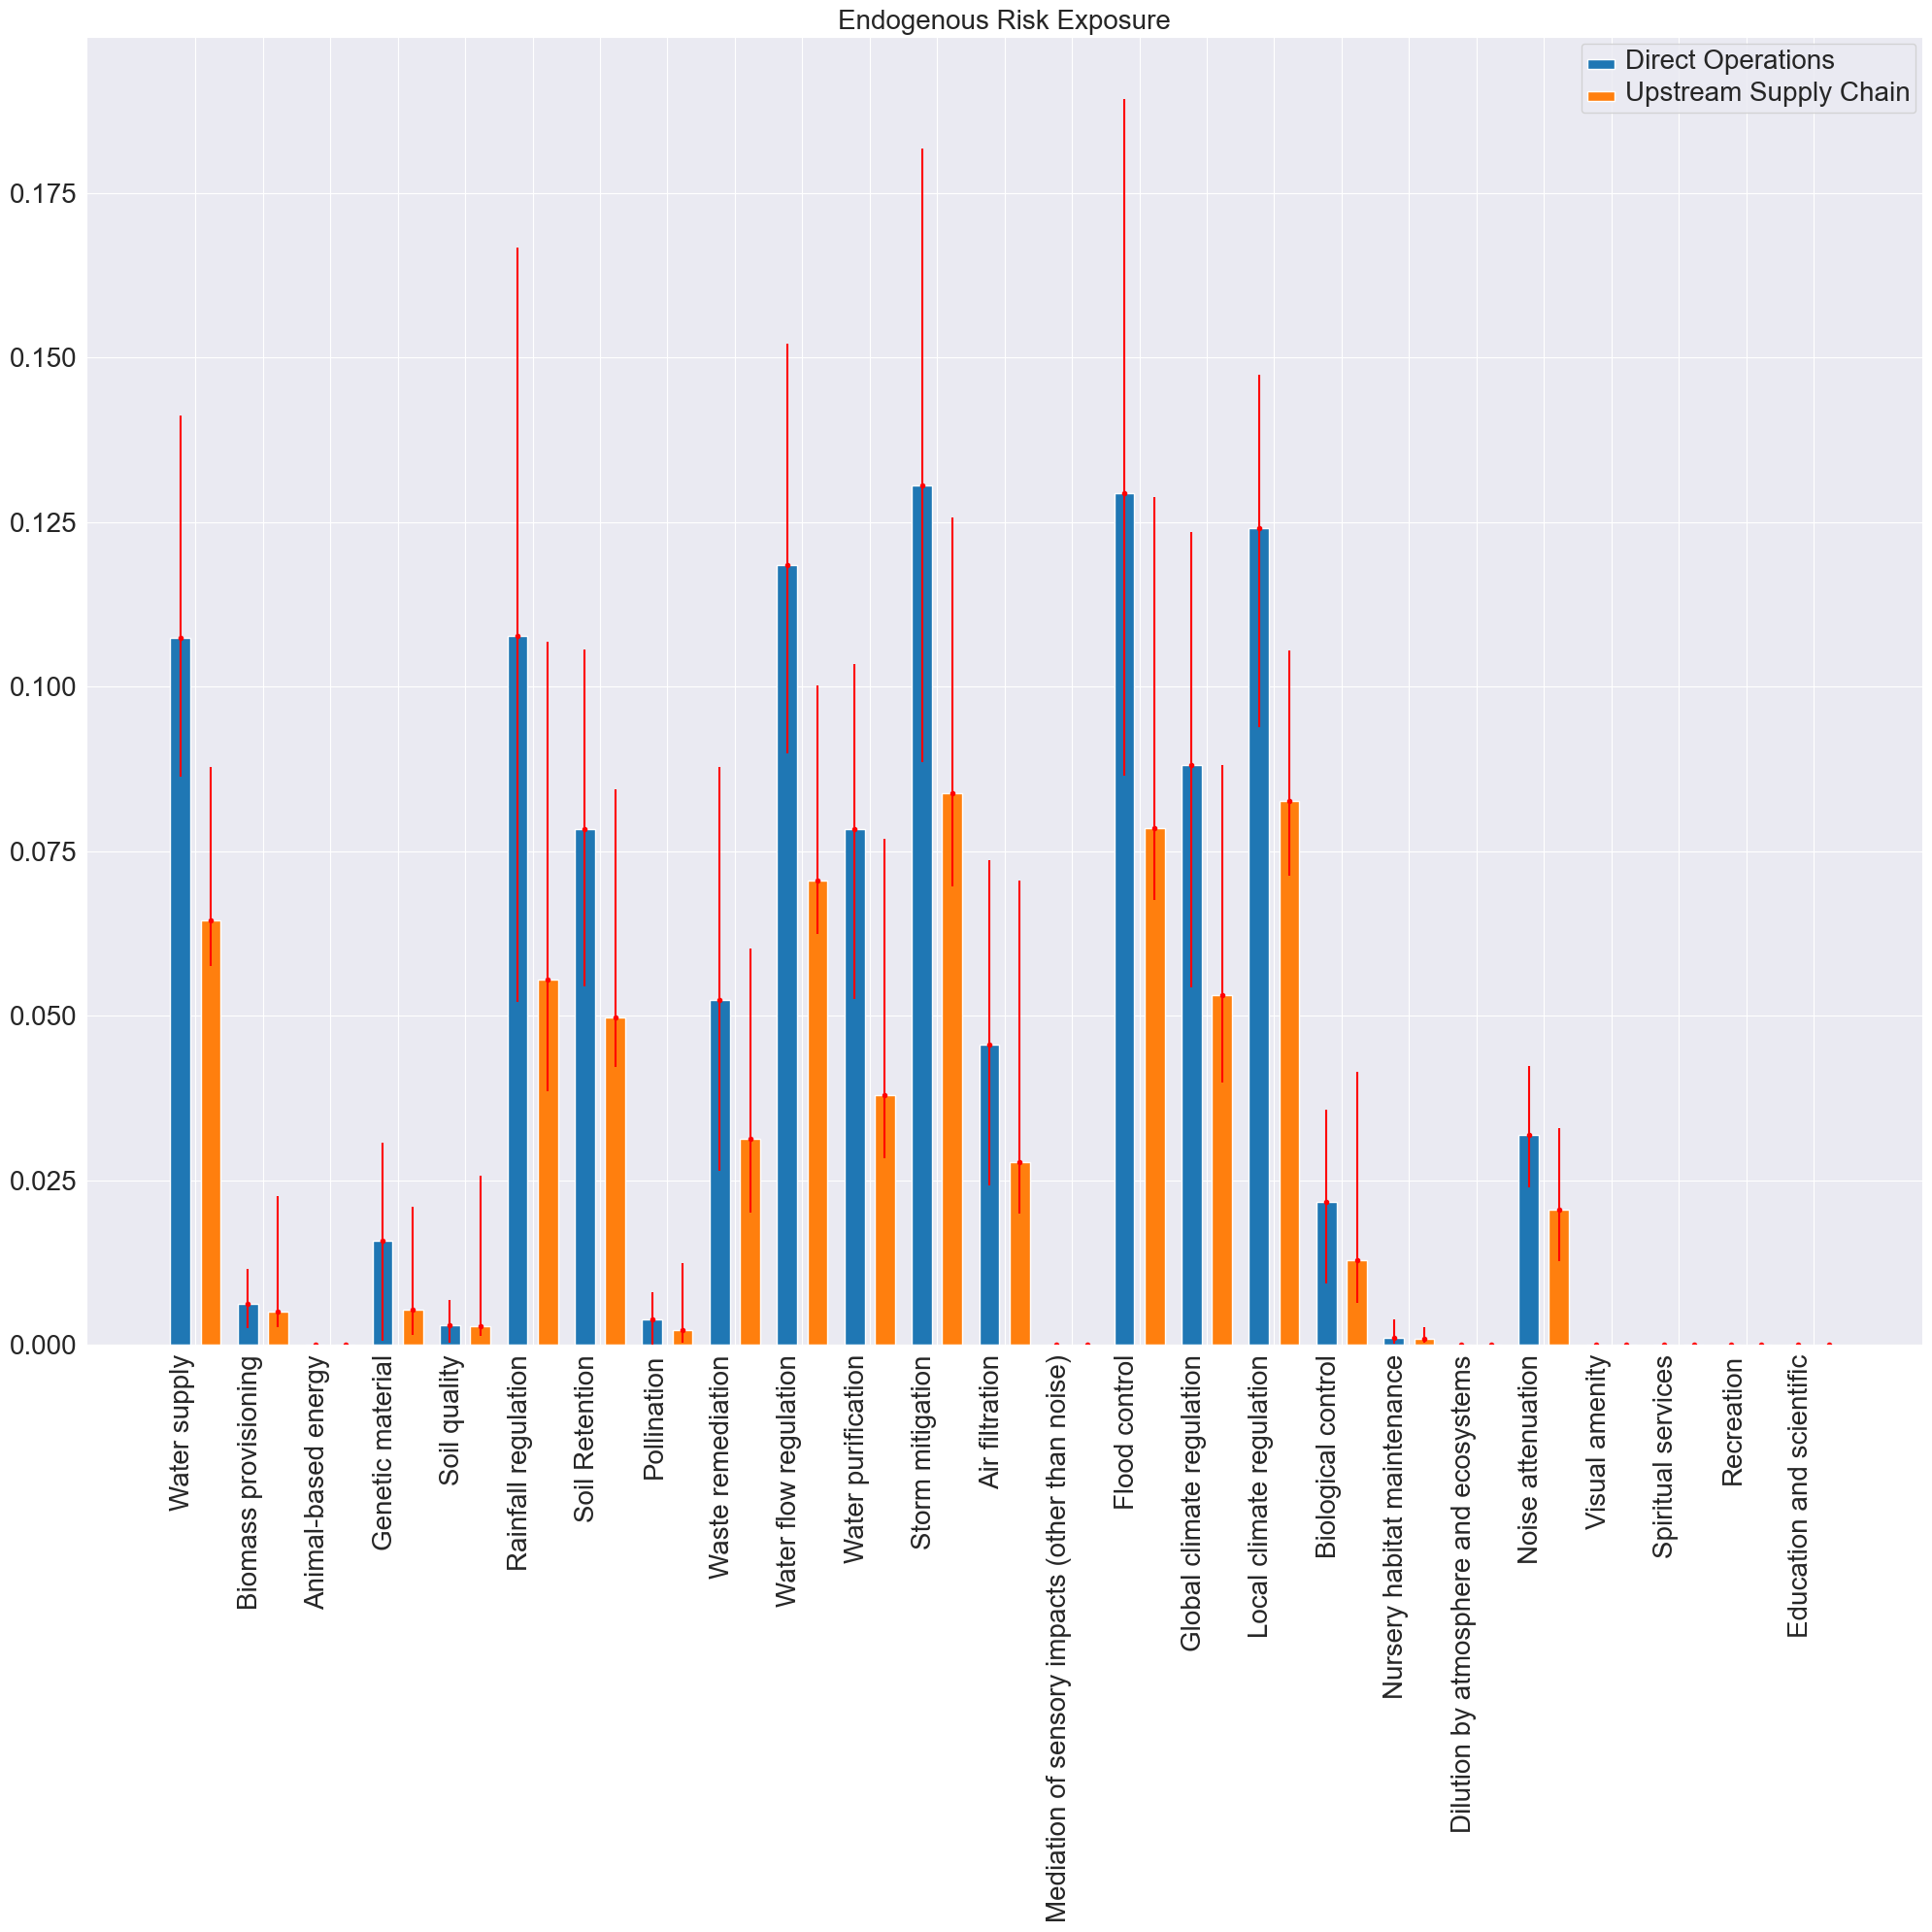

In [25]:
plot_bar_chart_updated(both_nvars_mean, both_nvars_min, both_nvars_max)

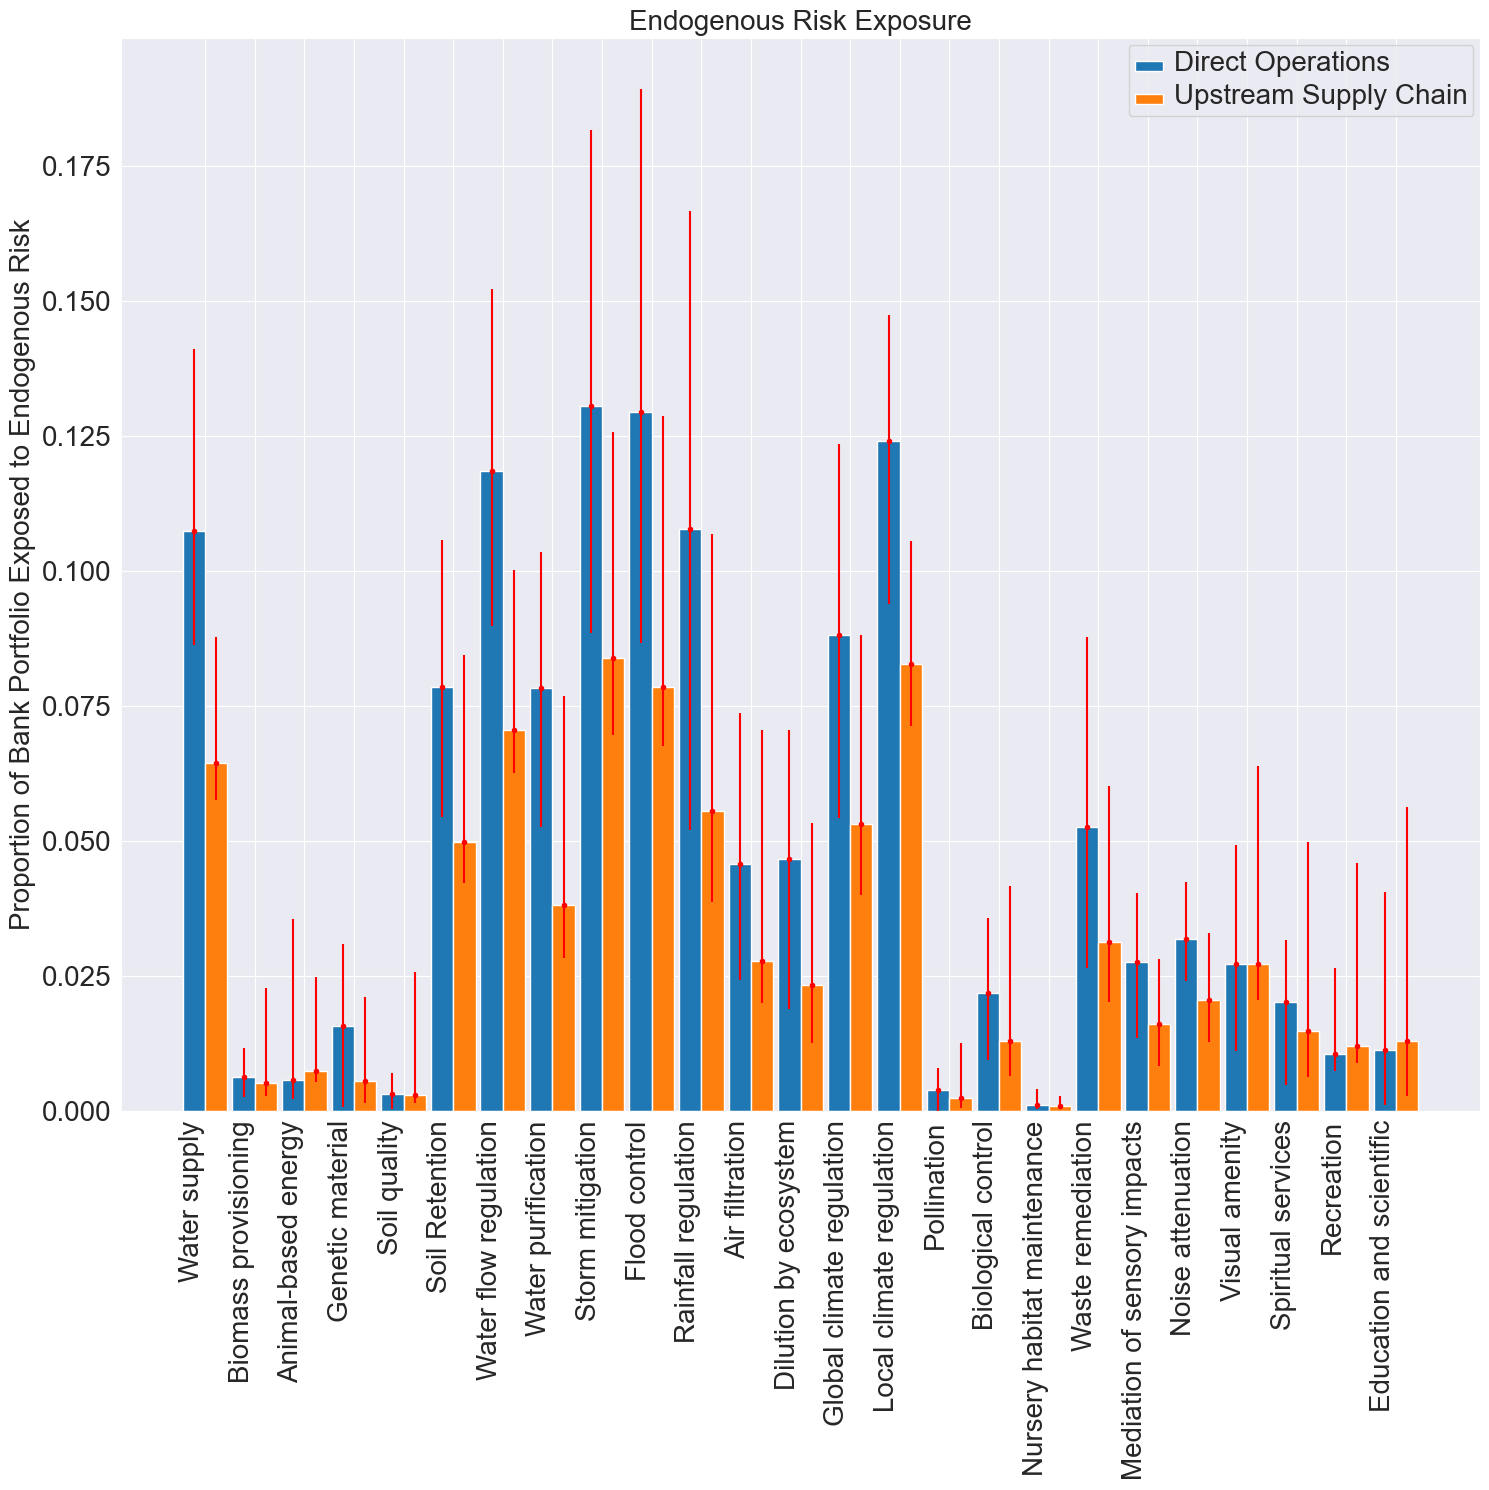

In [40]:
portfolio_mean = both_nvars_mean
portfolio_min = both_nvars_min
portfolio_max = both_nvars_max

"""
This function plots bar chart for the portfolio-level based on the scores for direct operations and upstream supply
chain
:param portfolio_mean: results with mean methoodological treatment - portfolio-level
:param portfolio_min: results with min methoodological treatment - portfolio-level
:param portfolio_max: results with max methoodological treatment - portfolio-level
:return:
"""
# determine score type
if 'Both' in portfolio_mean[0].name:
    folder = 'Overlap'
else:
    if 'Impact' in portfolio_mean[0].name:
        folder = 'Impact'
    if 'Dependency' in portfolio_mean[0].name:
        folder = 'Dependency'

# portfolio-level
# store the scores in the appropriate list based on whether proportional or absolute and for direct operations,
# or upstream supply chain for each methodological treatment

# generate proportional
# get financial data
financial_data_df = finance_GSIB_reformat()
# get total value of portfolios across all banks
system_total = financial_data_df['EUR m adjusted'].sum()

scope_1_var_finance_portfolio = []
scope_3_var_finance_portfolio = []
scope_1_var_finance_abs_portfolio = []
scope_3_var_finance_abs_portfolio = []
for score in portfolio_mean:
    if 'Proportional' not in score.name:
        if 'Scope 1' in score.name:
            # aggregate to system
            df = score.copy()
            df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
            prop_df = (df / system_total) * 100
            df.name = f'{score.name} mean'
            scope_1_var_finance_abs_portfolio.append(df)
            prop_df.name = f'{score.name} Proportional mean'
            scope_1_var_finance_portfolio.append(prop_df)
        if 'Source' in score.name:
            # aggregate to system
            df = score.copy()
            df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
            prop_df = (df / system_total) * 100
            df.name = f'{score.name} mean'
            scope_3_var_finance_abs_portfolio.append(df)
            prop_df.name = f'{score.name} Proportional mean'
            scope_3_var_finance_portfolio.append(prop_df)

for score in portfolio_min:
    if 'Proportional' not in score.name:
        if 'Scope 1' in score.name:
            # aggregate to system
            df = score.copy()
            df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
            prop_df = (df / system_total) * 100
            df.name = f'{score.name} min'
            scope_1_var_finance_abs_portfolio.append(df)
            prop_df.name = f'{score.name} Proportional min'
            scope_1_var_finance_portfolio.append(prop_df)
        if 'Source' in score.name:
            # aggregate to system
            df = score.copy()
            df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
            prop_df = (df / system_total) * 100
            df.name = f'{score.name} min'
            scope_3_var_finance_abs_portfolio.append(df)
            prop_df.name = f'{score.name} Proportional min'
            scope_3_var_finance_portfolio.append(prop_df)
for score in portfolio_max:
    if 'Proportional' not in score.name:
        if 'Scope 1' in score.name:
            # aggregate to system
            df = score.copy()
            df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
            prop_df = (df / system_total) * 100
            df.name = f'{score.name} max'
            scope_1_var_finance_abs_portfolio.append(df)
            prop_df.name = f'{score.name} Proportional max'
            scope_1_var_finance_portfolio.append(prop_df)
        if 'Source' in score.name:
            # aggregate to system
            df = score.copy()
            df = df.reset_index().drop(columns=['Bank']).groupby(['sector', 'region']).sum()
            prop_df = (df / system_total) * 100
            df.name = f'{score.name} max'
            scope_3_var_finance_abs_portfolio.append(df)
            prop_df.name = f'{score.name} Proportional max'
            scope_3_var_finance_portfolio.append(prop_df)

  # ---------- 1) Ordered services (grouped) and mappings ----------
short_label_map = {
"Water supply ": "Water supply",
"Other provisioning services - Animal-based energy": "Animal-based energy",
"Genetic material": "Genetic material",
"Biomass provisioning": "Biomass provisioning",
"Soil and sediment quality regulation": "Soil quality",
"Rainfall pattern regulation": "Rainfall regulation",
"Soil and sediment retention": "Soil Retention",
"Pollination": "Pollination",
"Solid waste remediation": "Waste remediation",
"Water flow regulation": "Water flow regulation",
"Storm mitigation": "Storm mitigation",
"Water purification": "Water purification",
"Air filtration": "Air filtration",
"Other regulating and maintenance service - Mediation of sensory impacts (other than noise)": "Mediation of sensory impacts",
"Global climate regulation": "Global climate regulation",
"Flood control": "Flood control",
"Local (micro and meso) climate regulation": "Local climate regulation",
"Biological control": "Biological control",
"Other regulating and maintenance service - Dilution by atmosphere and ecosystems": "Dilution by ecosystem",
"Nursery population and habitat maintenance": "Nursery habitat maintenance",
"Noise attenuation ": "Noise attenuation",
"Visual amenity services": "Visual amenity",
"Spiritual, artistic and symbolic services":"Spiritual services",
"Recreation related services":"Recreation",
"Education, scientific and research services":"Education and scientific",
}

# normalized lookup
mapping_norm = {k.strip().lower(): v for k, v in short_label_map.items()}

# explicit canonical service order you want preserved (customise this if desired)
services = [          'Water supply ',
                     'Biomass provisioning',
                     'Other provisioning services - Animal-based energy',
                     'Genetic material',
                     'Soil and sediment quality regulation',
                     'Soil and sediment retention',
                     'Water flow regulation',
                     'Water purification',
                     'Storm mitigation',
                     'Flood control',
                     'Rainfall pattern regulation',
                     'Air filtration',
                     'Other regulating and maintenance service - Dilution by atmosphere and ecosystems',
                     'Global climate regulation',
                     'Local (micro and meso) climate regulation',
                     'Pollination',
                     'Biological control',
                     'Nursery population and habitat maintenance',
                     'Solid waste remediation',
                     'Other regulating and maintenance service - Mediation of sensory impacts (other than noise)',
                     'Noise attenuation ',
                     'Visual amenity services',
                     'Spiritual, artistic and symbolic services',
                     'Recreation related services',
                     'Education, scientific and research services']

service_order_map = {s.strip().lower(): i for i, s in enumerate(services)}

# suggested service -> subgroup mapping (edit if you prefer different groupings)
# explicit canonical service order you want preserved (customise this if desired)
service_to_group = {
    # Provisioning
    "Water supply ": "Water",
    "Biomass provisioning": "Species",
    "Other provisioning services - Animal-based energy": "Species",
    "Genetic material": "Species",

    # Soil
    "Soil and sediment quality regulation": "Soil",
    "Soil and sediment retention": "Soil",

    # Water regulation
    "Water flow regulation": "Water",
    "Water purification": "Water",
    "Storm mitigation": "Storm",
    "Flood control": "Storm",

    # Climate / Air
    "Rainfall pattern regulation": "Water",
    "Global climate regulation": "Air/Climate",
    "Local (micro and meso) climate regulation": "Air/Climate",
    "Air filtration": "Air/Climate",
    "Other regulating and maintenance service - Dilution by atmosphere and ecosystems": "Air/Climate",

    # Biological
    "Pollination": "Species",
    "Biological control": "Biological",
    "Nursery population and habitat maintenance": "Biological",

    # Waste / remediation
    "Solid waste remediation": "Waste",

    # Sensory / noise
    "Other regulating and maintenance service - Mediation of sensory impacts (other than noise)": "Sensory",
    "Noise attenuation ": "Sensory",
    
    # Cultural 
    "Visual amenity services":"Cultural",
    "Spiritual, artistic and symbolic services":"Cultural",
    "Recreation related services":"Cultural",
    "Education, scientific and research services":"Cultural"
}

    # ---------- helper: aggregate sheet list into ordered min/mean/max dicts ----------
def aggregate_by_service_from_sheet_list(sheet_list):
    """Return (min_dict, mean_dict, max_dict) for the provided list of sheets.
    Each dict keys follow the `services` order and missing columns default to 0.0."""
    min_values = {s: 0.0 for s in services}
    mean_values = {s: 0.0 for s in services}
    max_values = {s: 0.0 for s in services}

    # precompute lower-case column map helper when needed
    for sheet in sheet_list:
        one_bank_df = sheet.copy().reset_index()
        # create mapping from normalized column name -> actual column name for robust lookups
        cols_lower = {c.strip().lower(): c for c in one_bank_df.columns}

        this_sum = {}
        for s in services:
            if s in one_bank_df.columns:
                this_sum[s] = float(np.nansum(one_bank_df[s].fillna(0)))
            else:
                key = s.strip().lower()
                if key in cols_lower:
                    this_sum[s] = float(np.nansum(one_bank_df[cols_lower[key]].fillna(0)))
                else:
                    this_sum[s] = 0.0

        # route to min/mean/max depending on sheet.name
        name = sheet.name if hasattr(sheet, 'name') else ''
        if re.search('min', name, re.IGNORECASE):
            min_values = this_sum
        elif re.search('mean', name, re.IGNORECASE):
            mean_values = this_sum
        elif re.search('max', name, re.IGNORECASE):
            max_values = this_sum
        else:
            # ignore / or could combine if necessary
            pass

    return min_values, mean_values, max_values

 # ---------- NEW: pick top 11 services by combined mean (scope1 + scope3) ----------
# Build a combined list of all relevant scope sheets (sector, portfolio, system) for scope1+scope3
# all_scope_sheets = (
#     scope_1_var_finance_sector + scope_1_var_finance_portfolio + scope_1_var_finance +
#     scope_3_var_finance_sector + scope_3_var_finance_portfolio + scope_3_var_finance
# )

# If there are no sheets (defensive), skip filtering
# if all_scope_sheets:
#     _, combined_mean_all, _ = aggregate_by_service_from_sheet_list(all_scope_sheets)
# 
#     # select top 11 services by combined mean (descending)
#     top11 = sorted(services, key=lambda s: combined_mean_all.get(s, 0.0), reverse=True)[:11]
#     top11_set = set(top11)
# 
#     # preserve your grouped/service order but only keep the top-11
#     services = [s for s in services if s in top11_set]
# 
#     # reduce short_label_map to the selected services (fallback to service name kept if missing)
#     short_label_map = {s: short_label_map.get(s, s) for s in services}
# else: nothing to do (keeps original 'services' if no sheets found)

# ---------- Prepare figure & level lists ----------
plt.figure(figsize=(15, 15))
scope_1_levels = [scope_1_var_finance_portfolio, scope_3_var_finance_portfolio]
# scope_3_levels = [scope_3_var_finance_portfolio]
levels = ['Direct Operations', 'Upstream Supply Chain']
bar_adjustments = [-0.225, 0.225]

# ---------- Top: Scope 1 (Direct operations) ----------
ax = plt.subplot(1, 1, 1)
i = 0
for level_list in scope_1_levels:
    scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)

    X_axis = np.arange(len(services))
    mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
    min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
    max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100

    lower_err = mean_arr - min_arr
    upper_err = max_arr - mean_arr
    asym_err = np.array([lower_err, upper_err])

    ax.bar(X_axis + bar_adjustments[i], mean_arr, 0.45, label=levels[i])
    ax.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')

    i += 1

ax.legend()
# tidy x labels using the short map
x_labels = [short_label_map.get(s, s) for s in services]
ax.set_xticks(np.arange(len(services)))
ax.set_xticklabels(x_labels, rotation=90, ha='right')
ax.set_title('Endogenous Risk Exposure - Upstream Supply Chain')
ax.set_ylabel('Proportion of Bank Portfolio Exposed to Endogenous Risk')

if folder == 'Overlap':
    ax.set_title('Endogenous Risk Exposure')
else:
    ax.set_title(f'{folder} Value at Risk for Direct Operations and Upstream Supply Chain')

items = [ax.title, ax.yaxis.label, ax.xaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()
if ax.legend_:
    items += ax.legend_.get_texts()
for item in items:
    item.set_fontsize(20)

# ---------- Bottom: Scope 3 (Upstream supply chain) ----------
# ax2 = plt.subplot(2, 1, 2, sharey=ax)
# i = 0
# for level_list in scope_3_levels:
#     scope_min_values, scope_mean_values, scope_max_values = aggregate_by_service_from_sheet_list(level_list)
# 
#     X_axis = np.arange(len(services))
#     mean_arr = np.array([scope_mean_values[s] for s in services], dtype=float)/100
#     min_arr = np.array([scope_min_values[s] for s in services], dtype=float)/100
#     max_arr = np.array([scope_max_values[s] for s in services], dtype=float)/100
# 
#     lower_err = mean_arr - min_arr
#     upper_err = max_arr - mean_arr
#     asym_err = np.array([lower_err, upper_err])
# 
#     ax2.bar(X_axis + bar_adjustments[i], mean_arr, 0.3, label=levels[i])
#     ax2.errorbar(X_axis + bar_adjustments[i], mean_arr, yerr=asym_err, fmt='r.')
# 
#     i += 1
# 
# ax2.legend()
# 

# items = [ax2.title, ax2.yaxis.label, ax2.xaxis.label] + ax2.get_xticklabels() + ax2.get_yticklabels()
# if ax2.legend_:
#     items += ax2.legend_.get_texts()
# for item in items:
#     item.set_fontsize(20)

plt.tight_layout()
plt.savefig(
    f'{value_at_risk_figure_saving_path}/Value at Risk for Banks with Error Bars Percentage Portfolio')
plt.show()
plt.close()



In [44]:
scope_1_var_finance_portfolio[0].sum()

Air filtration                                                                                 4.560660
Biological control                                                                             2.178427
Biomass provisioning                                                                           0.623331
Education, scientific and research services                                                    1.119349
Flood control                                                                                 12.936065
Genetic material                                                                               1.575259
Global climate regulation                                                                      8.812406
Local (micro and meso) climate regulation                                                     12.401983
Noise attenuation                                                                              3.186580
Nursery population and habitat maintenance                      